# Comparación controlada de tres definiciones de masa estelar

## Objetivo

El objetivo de este notebook es comparar qué tan bien puede predecirse la masa estelar de una galaxia a partir de la misma imagen RGB cuando se utilizan tres definiciones distintas de masa estelar como etiqueta objetivo:

- **Pipe3D** → `log_mstar`
- **Taylor** → `LogMassTaylor`
- **NSA** → `LogMassNSA`

La comparación se realizará utilizando exactamente las mismas galaxias, las mismas imágenes, los mismos conjuntos de Train, Validation y Test, la misma arquitectura y el mismo protocolo de entrenamiento.

## Pregunta de investigación

¿Cambia el desempeño predictivo de una red neuronal convolucional cuando se modifica únicamente la definición de masa estelar utilizada como etiqueta?

## Diseño experimental

La comparación seguirá el principio:

`misma imagen + mismo modelo + mismo protocolo + distinto target`

De esta manera, cualquier diferencia en el desempeño podrá atribuirse principalmente a la definición de masa estelar utilizada como objetivo y no a cambios en la arquitectura o en el proceso de entrenamiento.

## Cohorte común

Se utilizará la cohorte común previamente validada de:

- **8,494 galaxias**
- Train: **6,510**
- Validation: **1,149**
- Test: **835**

Cada galaxia debe contar simultáneamente con:

- imagen RGB;
- masa Pipe3D;
- masa Taylor;
- masa NSA.

El conjunto Test permanecerá cerrado durante el desarrollo del modelo.

## Métricas de comparación

Para cada target se calcularán al menos:

- RMSE
- MAE
- R²
- bias medio
- desviación estándar de los residuales

La comparación entre Pipe3D, Taylor y NSA se realizará únicamente después de entrenar los tres modelos bajo el mismo protocolo.

## Importante

Un menor error de predicción no implica necesariamente que una definición de masa estelar sea físicamente más correcta.

El experimento evalúa principalmente qué tan reproducible es cada etiqueta a partir de la información contenida en las imágenes bajo condiciones controladas.

In [ ]:
# ============================================================
# CELDA 1 — CONFIGURACIÓN REPRODUCIBLE DEL EXPERIMENTO
# ============================================================

import random
import numpy as np
import pandas as pd
import torch

SEED = 42

# ------------------------------------------------------------
# Semillas reproducibles
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Dispositivo
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# Información del entorno
# ------------------------------------------------------------

print("=== CONFIGURACIÓN DEL EXPERIMENTO ===")
print("Seed:", SEED)
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\n✓ Configuración reproducible establecida.")

=== CONFIGURACIÓN DEL EXPERIMENTO ===
Seed: 42
PyTorch: 2.11.0+cu128
CUDA disponible: True
Dispositivo: cuda
GPU: NVIDIA A100-SXM4-40GB

✓ Configuración reproducible establecida.


## Etapa 2 — Localización de los archivos fuente

### ¿Qué se hará?

Antes de reconstruir la cohorte común se localizarán los archivos de datos necesarios dentro de Google Drive.

Se buscarán tres archivos:

- `color_morp_2.csv`
- `scalars.cat`
- `images.cat`

### ¿Por qué se hace?

Este notebook es nuevo y no conserva las variables que existían en sesiones anteriores.

Para que el experimento sea completamente reproducible, primero debemos identificar las rutas exactas de los archivos fuente antes de cargarlos.

Los archivos cumplen funciones diferentes:

- `color_morp_2.csv` contiene las masas Taylor y NSA.
- `scalars.cat` contiene la masa Pipe3D y el split original de Katachi.
- `images.cat` contiene las imágenes RGB de las galaxias.

En esta etapa todavía no se construirá la cohorte ni se cargarán las imágenes de 1.8 GB en memoria.

### ¿Cómo se hará?

1. Se montará Google Drive.
2. Se buscarán los tres archivos por nombre.
3. Se mostrarán las rutas encontradas.
4. No se continuará con ninguna ruta de forma automática hasta verificar que corresponde al archivo correcto.

### Criterio de avance

Para continuar necesitamos localizar al menos:

- `color_morp_2.csv`
- `scalars.cat`

`images.cat` será necesario poco después para construir el Dataset de imágenes.

In [ ]:
# ============================================================
# CELDA 2 — LOCALIZACIÓN DE ARCHIVOS FUENTE
# ============================================================

from google.colab import drive
import os

# ------------------------------------------------------------
# 1. Montar Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Archivos que necesitamos localizar
# ------------------------------------------------------------

archivos_buscados = {
    "color_morp_2.csv": [],
    "scalars.cat": [],
    "images.cat": []
}

RUTA_DRIVE = "/content/drive/MyDrive"


# ------------------------------------------------------------
# 3. Buscar únicamente esos nombres
# ------------------------------------------------------------

print("\n=== BUSCANDO ARCHIVOS FUENTE ===")

for raiz, carpetas, archivos in os.walk(RUTA_DRIVE):

    for nombre in archivos_buscados.keys():

        if nombre in archivos:
            ruta = os.path.join(raiz, nombre)
            archivos_buscados[nombre].append(ruta)


# ------------------------------------------------------------
# 4. Mostrar resultados
# ------------------------------------------------------------

for nombre, rutas in archivos_buscados.items():

    print(f"\n{nombre}")

    if len(rutas) == 0:
        print("  ✗ No encontrado")

    else:
        for i, ruta in enumerate(rutas, start=1):

            tamaño_mb = os.path.getsize(ruta) / (1024 ** 2)

            print(
                f"  {i}. {ruta}"
                f" | {tamaño_mb:.2f} MB"
            )


print("\n✓ Búsqueda terminada.")
print("Todavía no se ha cargado ningún archivo en memoria.")

Mounted at /content/drive

=== BUSCANDO ARCHIVOS FUENTE ===

color_morp_2.csv
  ✗ No encontrado

scalars.cat
  ✗ No encontrado

images.cat
  ✗ No encontrado

✓ Búsqueda terminada.
Todavía no se ha cargado ningún archivo en memoria.


## Etapa 3 — Recuperación de los archivos propios del experimento

### ¿Qué se hará?

La búsqueda en Google Drive mostró que los archivos utilizados en la sesión anterior no se encuentran almacenados allí.

Esto es consistente con el procedimiento original, ya que algunos archivos fueron cargados o descargados directamente al almacenamiento temporal de Google Colab (`/content`).

En esta etapa se recuperarán desde el equipo local dos archivos importantes:

- `color_morp_2.csv`
- `katachi_splits_comparacion_masas.csv`

### ¿Por qué se hace?

`color_morp_2.csv` contiene las dos etiquetas adicionales que necesitamos:

- `LogMassTaylor`
- `LogMassNSA`

El archivo `katachi_splits_comparacion_masas.csv` contiene la asignación experimental que ya fue congelada previamente:

- Train: 6,510 galaxias
- Validation: 1,149 galaxias
- Test: 835 galaxias

Es importante reutilizar este archivo y no volver a generar aleatoriamente los splits.

De esta manera Pipe3D, Taylor y NSA utilizarán exactamente las mismas galaxias en cada partición.

### ¿Cómo se hará?

Se abrirá el selector de archivos de Google Colab y se cargarán los archivos desde el equipo local.

Después se comprobará:

- qué archivos fueron cargados;
- sus nombres;
- su tamaño;
- que los dos archivos necesarios estén disponibles.

Todavía no se realizará ningún entrenamiento ni se utilizará el conjunto Test.

In [ ]:
# ============================================================
# CELDA 3 — SUBIR ARCHIVOS PROPIOS DEL EXPERIMENTO
# ============================================================

from google.colab import files
import os


# ------------------------------------------------------------
# 1. Seleccionar archivos desde la computadora
# ------------------------------------------------------------

print("Selecciona estos archivos si los tienes:")
print("  - color_morp_2.csv")
print("  - katachi_splits_comparacion_masas.csv")
print()

uploaded = files.upload()


# ------------------------------------------------------------
# 2. Mostrar archivos recibidos
# ------------------------------------------------------------

print("\n=== ARCHIVOS CARGADOS ===")

for nombre in uploaded.keys():

    ruta = f"/content/{nombre}"
    tamaño_mb = os.path.getsize(ruta) / (1024 ** 2)

    print(
        f"{nombre} | "
        f"{tamaño_mb:.2f} MB"
    )


# ------------------------------------------------------------
# 3. Verificar archivos necesarios
# ------------------------------------------------------------

archivo_masas = "/content/color_morp_2.csv"
archivo_splits = "/content/katachi_splits_comparacion_masas.csv"

print("\n=== VERIFICACIÓN ===")

print(
    "color_morp_2.csv:",
    os.path.exists(archivo_masas)
)

print(
    "katachi_splits_comparacion_masas.csv:",
    os.path.exists(archivo_splits)
)


if os.path.exists(archivo_masas):
    print("✓ Tabla Taylor/NSA disponible.")

if os.path.exists(archivo_splits):
    print("✓ Split experimental congelado disponible.")

Selecciona estos archivos si los tienes:
  - color_morp_2.csv
  - katachi_splits_comparacion_masas.csv



Saving katachi_splits_comparacion_masas.csv to katachi_splits_comparacion_masas.csv
Saving color_morp_2.csv to color_morp_2.csv

=== ARCHIVOS CARGADOS ===
katachi_splits_comparacion_masas.csv | 0.17 MB
color_morp_2.csv | 0.76 MB

=== VERIFICACIÓN ===
color_morp_2.csv: True
katachi_splits_comparacion_masas.csv: True
✓ Tabla Taylor/NSA disponible.
✓ Split experimental congelado disponible.


## Etapa 4 — Carga y auditoría de las tablas de masas y splits

### ¿Qué se hará?

En esta etapa se cargarán los dos archivos propios del experimento recuperados anteriormente:

- `color_morp_2.csv`
- `katachi_splits_comparacion_masas.csv`

Todavía no se combinarán las tablas.

### ¿Por qué se hace?

Antes de reconstruir la cohorte común es necesario comprobar que los archivos contienen la información esperada y que no se han modificado respecto al experimento anterior.

En particular interesa verificar:

- número de filas y columnas;
- nombres exactos de las columnas;
- presencia de los identificadores de galaxia;
- presencia de `LogMassTaylor`;
- presencia de `LogMassNSA`;
- distribución de Train, Validation y Test;
- existencia de identificadores duplicados.

El archivo de splits es especialmente importante porque permitirá conservar exactamente las mismas galaxias utilizadas previamente en cada partición y evitar generar una nueva división aleatoria.

### ¿Cómo se hará?

Se cargarán ambos archivos con pandas y se mostrará:

1. dimensión de cada tabla;
2. nombres de columnas;
3. primeras filas;
4. número de identificadores duplicados;
5. distribución del split experimental.

En esta etapa no se utilizarán imágenes y tampoco se abrirá el conjunto Test para evaluación.

In [ ]:
# ============================================================
# CELDA 4 — CARGA Y AUDITORÍA DE TABLAS BASE
# ============================================================

import pandas as pd
import os


# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

archivo_masas = "/content/color_morp_2.csv"
archivo_splits = "/content/katachi_splits_comparacion_masas.csv"


# ------------------------------------------------------------
# 2. Verificar existencia
# ------------------------------------------------------------

assert os.path.exists(archivo_masas), (
    "No se encontró color_morp_2.csv"
)

assert os.path.exists(archivo_splits), (
    "No se encontró katachi_splits_comparacion_masas.csv"
)


# ------------------------------------------------------------
# 3. Cargar archivos
# ------------------------------------------------------------

color_morp = pd.read_csv(
    archivo_masas
)

splits_fijos = pd.read_csv(
    archivo_splits
)


# ------------------------------------------------------------
# 4. Auditar color_morp_2.csv
# ------------------------------------------------------------

print("=== color_morp_2.csv ===")

print("Shape:", color_morp.shape)

print("\nColumnas:")
print(color_morp.columns.tolist())

print("\nPrimeras 3 filas:")
display(color_morp.head(3))


# ------------------------------------------------------------
# 5. Auditar archivo de splits
# ------------------------------------------------------------

print("\n" + "=" * 60)

print("=== katachi_splits_comparacion_masas.csv ===")

print("Shape:", splits_fijos.shape)

print("\nColumnas:")
print(splits_fijos.columns.tolist())

print("\nPrimeras 5 filas:")
display(splits_fijos.head())


# ------------------------------------------------------------
# 6. Buscar posibles columnas identificadoras
# ------------------------------------------------------------

print("\n=== COLUMNAS IDENTIFICADORAS ===")

for nombre, df in [
    ("color_morp", color_morp),
    ("splits", splits_fijos)
]:

    posibles_ids = [
        col for col in df.columns
        if col.lower() == "mangaid"
    ]

    print(
        nombre,
        "->",
        posibles_ids
    )


# ------------------------------------------------------------
# 7. Verificar masas necesarias
# ------------------------------------------------------------

print("\n=== ETIQUETAS DISPONIBLES ===")

print(
    "LogMassTaylor presente:",
    "LogMassTaylor" in color_morp.columns
)

print(
    "LogMassNSA presente:",
    "LogMassNSA" in color_morp.columns
)


# ------------------------------------------------------------
# 8. Distribución del split
# ------------------------------------------------------------

if "split" in splits_fijos.columns:

    print("\n=== DISTRIBUCIÓN DE SPLITS ===")

    print(
        splits_fijos["split"]
        .value_counts(dropna=False)
    )

else:

    print(
        "\n⚠ No existe una columna llamada 'split'."
    )


print("\n✓ Auditoría inicial terminada.")
print("Todavía no se ha realizado ningún merge.")

=== color_morp_2.csv ===
Shape: (10126, 6)

Columnas:
['name', 'MANGAID', 'T_11', 'g_i', 'LogMassTaylor', 'LogMassNSA']

Primeras 3 filas:


,name,MANGAID,T_11,g_i,LogMassTaylor,LogMassNSA
0,manga-10001-12701,1-48157,4,0.404967,9.269490,9.486857
1,manga-10001-12702,1-48188,4,0.644865,9.514213,9.727675
2,manga-10001-12703,1-55648,4,0.710236,9.944890,10.136514



=== katachi_splits_comparacion_masas.csv ===
Shape: (8494, 3)

Columnas:
['mangaid', 'particion', 'pipe3d_extremo_sensibilidad']

Primeras 5 filas:


,mangaid,particion,pipe3d_extremo_sensibilidad
0,1-1009,Train,False
1,1-10166,Train,False
2,1-10177,Train,False
3,1-10263,Train,False
4,1-1033,Train,False



=== COLUMNAS IDENTIFICADORAS ===
color_morp -> ['MANGAID']
splits -> ['mangaid']

=== ETIQUETAS DISPONIBLES ===
LogMassTaylor presente: True
LogMassNSA presente: True

⚠ No existe una columna llamada 'split'.

✓ Auditoría inicial terminada.
Todavía no se ha realizado ningún merge.


## Etapa 5 — Validación de la cohorte congelada y correspondencia con Taylor/NSA

### ¿Qué se hará?

En esta etapa se verificará que el archivo de particiones congeladas y la tabla `color_morp_2.csv` sean consistentes entre sí.

Se comprobarán:

- la distribución de Train, Validation y Test;
- la existencia de identificadores duplicados;
- la correspondencia entre `mangaid` y `MANGAID`;
- cuántas de las 8,494 galaxias congeladas están presentes en la tabla que contiene Taylor y NSA.

### ¿Por qué se hace?

Los tres experimentos deben utilizar exactamente las mismas galaxias.

El archivo:

`katachi_splits_comparacion_masas.csv`

define la cohorte experimental final y contiene 8,494 galaxias.

Por otro lado, `color_morp_2.csv` contiene las etiquetas:

- `LogMassTaylor`
- `LogMassNSA`

Antes de añadir Pipe3D, debemos verificar que las 8,494 galaxias de la cohorte congelada tienen correspondencia en esta tabla.

También es necesario comprobar que no existen MANGAID duplicados, ya que cada galaxia debe aparecer una sola vez.

### ¿Cómo se hará?

1. Se comprobará la distribución de la columna `particion`.
2. Se buscarán identificadores duplicados.
3. Se normalizará temporalmente el nombre `MANGAID` a `mangaid`.
4. Se comprobará la intersección entre ambas tablas.
5. Se verificará que las 8,494 galaxias congeladas estén disponibles para Taylor y NSA.

Todavía no se realizará ningún merge definitivo y todavía no se cargarán imágenes.

In [ ]:
# ============================================================
# CELDA 5 — VALIDAR COHORTE Y CORRESPONDENCIA TAYLOR / NSA
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Distribución del split congelado
# ------------------------------------------------------------

print("=== DISTRIBUCIÓN DE PARTICIONES ===")

conteo_particiones = (
    splits_fijos["particion"]
    .value_counts()
)

print(conteo_particiones)

print(
    "\nTotal:",
    len(splits_fijos)
)


# ------------------------------------------------------------
# 2. Verificar duplicados
# ------------------------------------------------------------

duplicados_splits = (
    splits_fijos["mangaid"]
    .duplicated()
    .sum()
)

duplicados_color = (
    color_morp["MANGAID"]
    .duplicated()
    .sum()
)

print("\n=== DUPLICADOS ===")

print(
    "Duplicados en splits:",
    duplicados_splits
)

print(
    "Duplicados en color_morp:",
    duplicados_color
)


# ------------------------------------------------------------
# 3. Preparar copia con identificador uniforme
# ------------------------------------------------------------

color_morp_clean = color_morp.rename(
    columns={"MANGAID": "mangaid"}
).copy()


# ------------------------------------------------------------
# 4. Comparar identificadores
# ------------------------------------------------------------

ids_splits = set(
    splits_fijos["mangaid"].astype(str)
)

ids_color = set(
    color_morp_clean["mangaid"].astype(str)
)

ids_comunes = (
    ids_splits & ids_color
)

faltantes_en_color = (
    ids_splits - ids_color
)


# ------------------------------------------------------------
# 5. Mostrar correspondencia
# ------------------------------------------------------------

print("\n=== CORRESPONDENCIA DE MANGAID ===")

print(
    "Galaxias en cohorte congelada:",
    len(ids_splits)
)

print(
    "Galaxias disponibles en color_morp:",
    len(ids_color)
)

print(
    "Coincidencias:",
    len(ids_comunes)
)

print(
    "Faltantes de la cohorte en color_morp:",
    len(faltantes_en_color)
)


if len(faltantes_en_color) > 0:

    print("\nPrimeros faltantes:")

    print(
        list(
            sorted(faltantes_en_color)
        )[:10]
    )


# ------------------------------------------------------------
# 6. Verificar etiquetas Taylor y NSA
# ------------------------------------------------------------

sub_color = color_morp_clean[
    color_morp_clean["mangaid"].isin(
        ids_splits
    )
].copy()

nan_taylor = (
    sub_color["LogMassTaylor"]
    .isna()
    .sum()
)

nan_nsa = (
    sub_color["LogMassNSA"]
    .isna()
    .sum()
)

print("\n=== ETIQUETAS EN LA COHORTE ===")

print(
    "Filas recuperadas:",
    len(sub_color)
)

print(
    "NaN LogMassTaylor:",
    nan_taylor
)

print(
    "NaN LogMassNSA:",
    nan_nsa
)


# ------------------------------------------------------------
# 7. Assertions esperadas
# ------------------------------------------------------------

assert len(splits_fijos) == 8494

assert conteo_particiones.get(
    "Train", 0
) == 6510

assert conteo_particiones.get(
    "Validation", 0
) == 1149

assert conteo_particiones.get(
    "Test", 0
) == 835

assert duplicados_splits == 0
assert duplicados_color == 0

assert len(ids_comunes) == 8494
assert len(faltantes_en_color) == 0

assert nan_taylor == 0
assert nan_nsa == 0


print("\n✓ Cohorte congelada validada.")
print("✓ Train = 6510.")
print("✓ Validation = 1149.")
print("✓ Test = 835.")
print("✓ Las 8,494 galaxias tienen Taylor y NSA.")
print("✓ No existen MANGAID duplicados.")

=== DISTRIBUCIÓN DE PARTICIONES ===
particion
Train         6510
Validation    1149
Test           835
Name: count, dtype: int64

Total: 8494

=== DUPLICADOS ===
Duplicados en splits: 0
Duplicados en color_morp: 0

=== CORRESPONDENCIA DE MANGAID ===
Galaxias en cohorte congelada: 8494
Galaxias disponibles en color_morp: 10126
Coincidencias: 8494
Faltantes de la cohorte en color_morp: 0

=== ETIQUETAS EN LA COHORTE ===
Filas recuperadas: 8494
NaN LogMassTaylor: 0
NaN LogMassNSA: 0

✓ Cohorte congelada validada.
✓ Train = 6510.
✓ Validation = 1149.
✓ Test = 835.
✓ Las 8,494 galaxias tienen Taylor y NSA.
✓ No existen MANGAID duplicados.


## Etapa 6 — Recuperación de la fuente original de Pipe3D utilizada por Katachi

### ¿Qué se hará?

En esta etapa se recuperará la fuente original utilizada por Katachi para obtener la etiqueta de masa estelar Pipe3D.

La variable que necesitamos es:

`log_mstar`

y deberá estar asociada con:

`mangaid`

El catálogo original utilizado anteriormente fue:

`scalars.cat`

### ¿Por qué se hace?

Pipe3D constituye la tercera etiqueta del experimento y además es la definición de masa utilizada originalmente por Katachi.

Para mantener trazabilidad y reproducibilidad, no se construirá esta etiqueta manualmente ni se utilizará una fuente diferente.

Primero se inspeccionará el repositorio oficial de Katachi para determinar exactamente dónde se encuentra `scalars.cat` o cómo se descarga desde el código original.

### ¿Cómo se hará?

1. Se clonará el repositorio público oficial de Katachi.
2. Se buscarán archivos llamados `scalars.cat`.
3. Se buscarán dentro de notebooks y scripts referencias al texto `scalars.cat`.
4. Se mostrará cualquier ruta o instrucción encontrada.

En esta etapa todavía no se realizará el merge con Taylor y NSA.

### Resultado esperado

En el experimento anterior, `scalars.cat` correspondía a un catálogo de aproximadamente 153 MB que, una vez cargado, contenía:

- 10,081 galaxias;
- 30 columnas;
- `mangaid`;
- `log_mstar`;
- `split`.

Primero identificaremos la fuente exacta y después lo cargaremos.

In [ ]:
# ============================================================
# CELDA 6 — LOCALIZAR scalars.cat EN KATACHI
# ============================================================

import os
import glob
import subprocess


# ------------------------------------------------------------
# 1. Clonar repositorio oficial de Katachi
# ------------------------------------------------------------

REPO_DIR = "/content/Katachi"

if not os.path.exists(REPO_DIR):

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/juanpabloalfonzo/Katachi.git",
            REPO_DIR
        ],
        check=True
    )

else:
    print("El repositorio Katachi ya existe en /content.")


# ------------------------------------------------------------
# 2. Buscar directamente scalars.cat
# ------------------------------------------------------------

print("\n=== BÚSQUEDA DIRECTA DE scalars.cat ===")

candidatos = glob.glob(
    f"{REPO_DIR}/**/scalars.cat",
    recursive=True
)

if len(candidatos) == 0:

    print("No se encontró scalars.cat directamente en el repositorio.")

else:

    for ruta in candidatos:

        tamaño_mb = (
            os.path.getsize(ruta) /
            (1024 ** 2)
        )

        print(
            ruta,
            "|",
            f"{tamaño_mb:.2f} MB"
        )


# ------------------------------------------------------------
# 3. Buscar referencias a scalars.cat en el código original
# ------------------------------------------------------------

print("\n=== REFERENCIAS A 'scalars.cat' EN KATACHI ===")

referencias = []

for raiz, carpetas, archivos in os.walk(REPO_DIR):

    for archivo in archivos:

        if archivo.endswith(
            (".py", ".ipynb", ".md", ".txt")
        ):

            ruta = os.path.join(
                raiz,
                archivo
            )

            try:

                with open(
                    ruta,
                    "r",
                    encoding="utf-8",
                    errors="ignore"
                ) as f:

                    contenido = f.read()

                if "scalars.cat" in contenido:

                    referencias.append(ruta)

            except Exception:
                pass


if len(referencias) == 0:

    print(
        "No se encontraron referencias "
        "a scalars.cat en scripts/notebooks."
    )

else:

    for ruta in referencias:
        print(ruta)


# ------------------------------------------------------------
# 4. Mostrar líneas cercanas a scalars.cat
# ------------------------------------------------------------

print("\n=== CONTEXTO DE LAS REFERENCIAS ===")

for ruta in referencias:

    print("\nARCHIVO:", ruta)

    with open(
        ruta,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        lineas = f.readlines()

    for i, linea in enumerate(lineas):

        if "scalars.cat" in linea:

            inicio = max(
                0,
                i - 3
            )

            fin = min(
                len(lineas),
                i + 4
            )

            for j in range(inicio, fin):

                print(
                    f"{j + 1}:",
                    lineas[j].rstrip()
                )


print("\n✓ Inspección del repositorio terminada.")
print("Todavía no se ha cargado Pipe3D ni realizado ningún merge.")


=== BÚSQUEDA DIRECTA DE scalars.cat ===
No se encontró scalars.cat directamente en el repositorio.

=== REFERENCIAS A 'scalars.cat' EN KATACHI ===
/content/Katachi/get_large_files.ipynb
/content/Katachi/manga_SHAP_2d_property_plots.ipynb
/content/Katachi/manga_SHAP_radial_plots.ipynb
/content/Katachi/Plotting_Notebook.ipynb

=== CONTEXTO DE LAS REFERENCIAS ===

ARCHIVO: /content/Katachi/get_large_files.ipynb
36:     "\n",
37:     "\n",
38:     "#Downloading full data catalogues generated for this work \n",
39:     "manga_scalars = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/scalars.cat',work_dir1, 'scalars')\n",
40:     "manga_images = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/images.cat',work_dir1, 'images')\n",
41:     "manga_shap_maps_mass = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/shap_mass.cat',work_dir1, 'shap_mass')\n",
42:     

## Etapa 7 — Descarga y auditoría del catálogo Pipe3D de Katachi

### ¿Qué se hará?

En esta etapa se descargará el archivo original `scalars.cat` utilizado por Katachi.

La fuente fue identificada directamente dentro del notebook oficial `get_large_files.ipynb` del repositorio de Katachi.

El catálogo contiene, entre otras variables:

- `mangaid`
- `log_mstar`

donde `log_mstar` corresponde a la masa estelar Pipe3D que se utilizará como tercera etiqueta del experimento.

### ¿Por qué se hace?

El objetivo del experimento es comparar tres definiciones de masa estelar:

- Pipe3D → `log_mstar`
- Taylor → `LogMassTaylor`
- NSA → `LogMassNSA`

Taylor y NSA ya se encuentran disponibles en `color_morp_2.csv`.

Ahora necesitamos recuperar Pipe3D utilizando exactamente la misma fuente empleada por Katachi, manteniendo así la trazabilidad del experimento.

### ¿Cómo se hará?

1. Se descargará `scalars.cat` desde la dirección utilizada por el código oficial de Katachi.
2. Se cargará utilizando `hickle`.
3. Se comprobará:
   - tipo de objeto;
   - dimensiones;
   - nombres de columnas;
   - presencia de `mangaid`;
   - presencia de `log_mstar`;
   - número de duplicados;
   - número de valores no finitos.

Todavía no se realizará el merge con Taylor y NSA.

### Resultado esperado

De acuerdo con la auditoría previa del proyecto, el catálogo debería contener aproximadamente:

- 10,081 galaxias;
- 30 columnas.

La variable `log_mstar` será posteriormente asociada a la cohorte congelada mediante `mangaid`.

In [ ]:
# ============================================================
# CELDA 7 — DESCARGAR Y AUDITAR scalars.cat
# ============================================================

import os
import sys
import subprocess
import numpy as np


# ------------------------------------------------------------
# 1. Instalar hickle si no está disponible
# ------------------------------------------------------------

try:
    import hickle as hkl

except ImportError:
    print("Instalando hickle...")

    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "hickle"]
    )

    import hickle as hkl


# ------------------------------------------------------------
# 2. URL original identificada en Katachi
# ------------------------------------------------------------

URL_SCALARS = (
    "https://www.astr.tohoku.ac.jp/"
    "~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/"
    "scalars.cat"
)

RUTA_SCALARS = "/content/scalars.cat"


# ------------------------------------------------------------
# 3. Descargar archivo
# ------------------------------------------------------------

if not os.path.exists(RUTA_SCALARS):

    print("Descargando scalars.cat...")

    subprocess.run(
        [
            "wget",
            "-q",
            "--show-progress",
            "-O",
            RUTA_SCALARS,
            URL_SCALARS
        ],
        check=True
    )

else:
    print("scalars.cat ya existe en /content.")


# ------------------------------------------------------------
# 4. Mostrar tamaño
# ------------------------------------------------------------

tamano_mb = (
    os.path.getsize(RUTA_SCALARS)
    / (1024 ** 2)
)

print(
    "\nTamaño de scalars.cat:",
    f"{tamano_mb:.2f} MB"
)


# ------------------------------------------------------------
# 5. Cargar catálogo
# ------------------------------------------------------------

scalars = hkl.load(
    RUTA_SCALARS
)


# ------------------------------------------------------------
# 6. Auditoría básica
# ------------------------------------------------------------

print("\n=== CATÁLOGO SCALARS ===")

print(
    "Tipo:",
    type(scalars)
)

print(
    "Shape:",
    scalars.shape
)

print("\nColumnas:")
print(
    scalars.columns.tolist()
)


# ------------------------------------------------------------
# 7. Verificar columnas necesarias
# ------------------------------------------------------------

print("\n=== VARIABLES NECESARIAS ===")

print(
    "mangaid presente:",
    "mangaid" in scalars.columns
)

print(
    "log_mstar presente:",
    "log_mstar" in scalars.columns
)


# ------------------------------------------------------------
# 8. Duplicados y valores no finitos
# ------------------------------------------------------------

duplicados_pipe3d = (
    scalars["mangaid"]
    .duplicated()
    .sum()
)

no_finitos_pipe3d = (
    ~np.isfinite(
        scalars["log_mstar"]
        .to_numpy()
    )
).sum()


print("\n=== CONTROL DE CALIDAD PIPE3D ===")

print(
    "MANGAID duplicados:",
    duplicados_pipe3d
)

print(
    "log_mstar no finitos:",
    no_finitos_pipe3d
)


# ------------------------------------------------------------
# 9. Primeras filas
# ------------------------------------------------------------

print("\n=== PRIMERAS FILAS ===")

display(
    scalars[
        ["mangaid", "log_mstar"]
    ].head()
)


# ------------------------------------------------------------
# 10. Verificaciones
# ------------------------------------------------------------

assert "mangaid" in scalars.columns
assert "log_mstar" in scalars.columns
assert duplicados_pipe3d == 0

print("\n✓ scalars.cat cargado correctamente.")
print("✓ mangaid disponible.")
print("✓ log_mstar Pipe3D disponible.")
print("✓ Todavía no se realizó ningún merge.")

Instalando hickle...
Descargando scalars.cat...

Tamaño de scalars.cat: 153.52 MB

=== CATÁLOGO SCALARS ===
Tipo: <class 'pandas.core.frame.DataFrame'>
Shape: (10081, 30)

Columnas:
['mangaid', 'log_mstar', 'log_sfr', 'redshift', 'redshift_gz', 'sersic_n', 't50_Pipe3D', 't50_model', 'd4000', 'Av', 'Z', 'spirals', 'bars', 'irregular_features', 'edge_on', 'bulge', 'RA_Pipe3D', 'DEC_Pipe3D', 'RA_gz', 'DEC_gz', 'smooth', 'merger_gz', 'p_merger', 'over_density', 'z_completeness', 'split', 'pred_mstar', 'pred_sfr', 'pred_d4000', 'sfh']

=== VARIABLES NECESARIAS ===
mangaid presente: True
log_mstar presente: True

=== CONTROL DE CALIDAD PIPE3D ===
MANGAID duplicados: 0
log_mstar no finitos: 0

=== PRIMERAS FILAS ===


,mangaid,log_mstar
0,1-1009,11.178438
1,1-10166,11.513323
2,1-10177,10.615028
3,1-10263,9.305632
4,1-1033,9.172108



✓ scalars.cat cargado correctamente.
✓ mangaid disponible.
✓ log_mstar Pipe3D disponible.
✓ Todavía no se realizó ningún merge.


## Etapa 8 — Reconstrucción de la cohorte común con las tres masas estelares

### ¿Qué se hará?

En esta etapa se reconstruirá la tabla maestra del experimento utilizando exclusivamente las 8,494 galaxias de la cohorte congelada.

Para cada galaxia se reunirán las tres etiquetas de masa estelar:

- Pipe3D → `log_mstar`
- Taylor → `LogMassTaylor`
- NSA → `LogMassNSA`

También se conservará la partición experimental previamente fijada:

- Train
- Validation
- Test

### ¿Por qué se hace?

El objetivo central del experimento es comparar las tres definiciones de masa estelar bajo condiciones idénticas.

Para que la comparación sea válida, cada modelo debe utilizar:

- exactamente las mismas galaxias;
- exactamente las mismas imágenes;
- exactamente las mismas particiones;
- y diferir únicamente en la etiqueta objetivo.

Por esta razón, las tablas no se unirán mediante su posición de fila.

La asociación se realizará exclusivamente mediante `mangaid`, que funciona como identificador único de cada galaxia.

### ¿Cómo se hará?

Se partirá del archivo de particiones congeladas, que contiene exactamente 8,494 galaxias.

Posteriormente se incorporarán:

1. `LogMassTaylor` y `LogMassNSA` desde `color_morp_2.csv`.
2. `log_mstar` desde `scalars.cat`.

Los `merge` se realizarán con validación `one_to_one` para asegurar que cada galaxia tenga una única correspondencia.

Después se comprobará:

- número total de galaxias;
- distribución Train / Validation / Test;
- ausencia de duplicados;
- ausencia de valores faltantes;
- ausencia de valores no finitos;
- disponibilidad simultánea de las tres masas.

### Resultado esperado

La tabla final debe contener exactamente:

- Total: 8,494 galaxias
- Train: 6,510
- Validation: 1,149
- Test: 835

Cada una deberá tener simultáneamente:

`log_mstar`, `LogMassTaylor` y `LogMassNSA`.

El conjunto Test se conserva únicamente como partición y todavía no se utilizará para evaluar modelos.

In [ ]:
# ============================================================
# CELDA 8 — RECONSTRUIR COHORTE COMÚN CON LAS TRES MASAS
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Normalizar identificadores como texto
# ------------------------------------------------------------

splits_base = splits_fijos.copy()
color_base = color_morp_clean.copy()
pipe3d_base = scalars.copy()

splits_base["mangaid"] = (
    splits_base["mangaid"]
    .astype(str)
    .str.strip()
)

color_base["mangaid"] = (
    color_base["mangaid"]
    .astype(str)
    .str.strip()
)

pipe3d_base["mangaid"] = (
    pipe3d_base["mangaid"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 2. Seleccionar únicamente variables necesarias
# ------------------------------------------------------------

tabla_taylor_nsa = color_base[
    [
        "mangaid",
        "LogMassTaylor",
        "LogMassNSA"
    ]
].copy()

tabla_pipe3d = pipe3d_base[
    [
        "mangaid",
        "log_mstar"
    ]
].copy()


# ------------------------------------------------------------
# 3. Partir SIEMPRE de la cohorte congelada
# ------------------------------------------------------------

muestra_comun_masas = splits_base.merge(
    tabla_taylor_nsa,
    on="mangaid",
    how="left",
    validate="one_to_one"
)


muestra_comun_masas = muestra_comun_masas.merge(
    tabla_pipe3d,
    on="mangaid",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 4. Ordenar columnas
# ------------------------------------------------------------

columnas_finales = [
    "mangaid",
    "particion",
    "log_mstar",
    "LogMassTaylor",
    "LogMassNSA",
    "pipe3d_extremo_sensibilidad"
]

muestra_comun_masas = muestra_comun_masas[
    columnas_finales
].copy()


# ------------------------------------------------------------
# 5. Auditoría general
# ------------------------------------------------------------

print("=== COHORTE COMÚN FINAL ===")

print(
    "Shape:",
    muestra_comun_masas.shape
)

print("\nColumnas:")
print(
    muestra_comun_masas.columns.tolist()
)


# ------------------------------------------------------------
# 6. Distribución de particiones
# ------------------------------------------------------------

print("\n=== PARTICIONES ===")

print(
    muestra_comun_masas["particion"]
    .value_counts()
)


# ------------------------------------------------------------
# 7. Duplicados
# ------------------------------------------------------------

duplicados_finales = (
    muestra_comun_masas["mangaid"]
    .duplicated()
    .sum()
)

print("\nMANGAID duplicados:", duplicados_finales)


# ------------------------------------------------------------
# 8. Valores faltantes
# ------------------------------------------------------------

columnas_masa = [
    "log_mstar",
    "LogMassTaylor",
    "LogMassNSA"
]

print("\n=== VALORES FALTANTES ===")

for col in columnas_masa:

    print(
        col,
        "->",
        muestra_comun_masas[col]
        .isna()
        .sum()
    )


# ------------------------------------------------------------
# 9. Valores no finitos
# ------------------------------------------------------------

print("\n=== VALORES NO FINITOS ===")

for col in columnas_masa:

    no_finitos = (
        ~np.isfinite(
            muestra_comun_masas[col]
            .to_numpy(dtype=float)
        )
    ).sum()

    print(
        col,
        "->",
        no_finitos
    )


# ------------------------------------------------------------
# 10. Primeras galaxias
# ------------------------------------------------------------

print("\n=== PRIMERAS 5 GALAXIAS ===")

display(
    muestra_comun_masas.head()
)


# ------------------------------------------------------------
# 11. Ejemplo conocido para verificar alineación
# ------------------------------------------------------------

print("\n=== VERIFICACIÓN DE UNA GALAXIA ===")

ejemplo = muestra_comun_masas[
    muestra_comun_masas["mangaid"] == "1-1009"
]

display(
    ejemplo[
        [
            "mangaid",
            "particion",
            "log_mstar",
            "LogMassTaylor",
            "LogMassNSA"
        ]
    ]
)


# ------------------------------------------------------------
# 12. Assertions
# ------------------------------------------------------------

assert len(muestra_comun_masas) == 8494

assert (
    muestra_comun_masas["mangaid"]
    .nunique()
    == 8494
)

assert (
    muestra_comun_masas["particion"]
    .value_counts()
    .get("Train", 0)
    == 6510
)

assert (
    muestra_comun_masas["particion"]
    .value_counts()
    .get("Validation", 0)
    == 1149
)

assert (
    muestra_comun_masas["particion"]
    .value_counts()
    .get("Test", 0)
    == 835
)

assert muestra_comun_masas[
    columnas_masa
].isna().sum().sum() == 0

assert np.isfinite(
    muestra_comun_masas[
        columnas_masa
    ].to_numpy(dtype=float)
).all()

assert duplicados_finales == 0


print("\n✓ Cohorte común reconstruida correctamente.")
print("✓ 8,494 galaxias únicas.")
print("✓ Las tres masas están disponibles para todas.")
print("✓ Train = 6,510.")
print("✓ Validation = 1,149.")
print("✓ Test = 835.")
print("✓ Asociación realizada mediante mangaid.")
print("✓ Test permanece cerrado.")

=== COHORTE COMÚN FINAL ===
Shape: (8494, 6)

Columnas:
['mangaid', 'particion', 'log_mstar', 'LogMassTaylor', 'LogMassNSA', 'pipe3d_extremo_sensibilidad']

=== PARTICIONES ===
particion
Train         6510
Validation    1149
Test           835
Name: count, dtype: int64

MANGAID duplicados: 0

=== VALORES FALTANTES ===
log_mstar -> 0
LogMassTaylor -> 0
LogMassNSA -> 0

=== VALORES NO FINITOS ===
log_mstar -> 0
LogMassTaylor -> 0
LogMassNSA -> 0

=== PRIMERAS 5 GALAXIAS ===


,mangaid,particion,log_mstar,LogMassTaylor,LogMassNSA,pipe3d_extremo_sensibilidad
0,1-1009,Train,11.178438,10.537899,10.517011,False
1,1-10166,Train,11.513323,10.970054,11.062813,False
2,1-10177,Train,10.615028,10.025106,10.136980,False
3,1-10263,Train,9.305632,8.656683,8.915025,False
4,1-1033,Train,9.172108,8.622037,8.849841,False



=== VERIFICACIÓN DE UNA GALAXIA ===


,mangaid,particion,log_mstar,LogMassTaylor,LogMassNSA
0,1-1009,Train,11.178438,10.537899,10.517011



✓ Cohorte común reconstruida correctamente.
✓ 8,494 galaxias únicas.
✓ Las tres masas están disponibles para todas.
✓ Train = 6,510.
✓ Validation = 1,149.
✓ Test = 835.
✓ Asociación realizada mediante mangaid.
✓ Test permanece cerrado.


## Etapa 9 — Descarga y auditoría de las imágenes originales de Katachi

### ¿Qué se hará?

En esta etapa se descargará y cargará el catálogo `images.cat` utilizado por Katachi.

Este archivo contiene las imágenes RGB que serán utilizadas como entrada de la red neuronal para los tres experimentos:

- Pipe3D
- Taylor
- NSA

Las imágenes deberán ser exactamente las mismas para los tres targets.

### ¿Por qué se hace?

El objetivo experimental requiere que la única diferencia entre los tres entrenamientos sea la definición de masa estelar utilizada como etiqueta.

Por lo tanto, debemos asegurar que:

- cada galaxia tenga exactamente una imagen;
- la asociación se realice mediante `mangaid`;
- todas las galaxias de la cohorte común tengan imagen disponible;
- las imágenes tengan el formato esperado por la red neuronal.

En la auditoría previa del proyecto, `images.cat` contenía imágenes RGB de 256 × 256 píxeles almacenadas junto con su `mangaid`.

### ¿Cómo se hará?

1. Se descargará `images.cat` desde la fuente original utilizada por Katachi.
2. Se cargará con `hickle`.
3. Se comprobará:
   - tipo de objeto;
   - dimensiones;
   - nombres de columnas;
   - duplicados de `mangaid`;
   - tipo de imagen;
   - modo RGB;
   - tamaño 256 × 256.
4. Se verificará que las 8,494 galaxias de la cohorte común estén presentes en el catálogo de imágenes.

La correspondencia entre imagen y galaxia se realizará siempre mediante `mangaid`, nunca mediante posición de fila.

### Resultado esperado

El catálogo original debe contener aproximadamente:

- 10,081 galaxias;
- dos columnas: `mangaid` e `images`;
- imágenes RGB de 256 × 256 píxeles.

Las 8,494 galaxias de la cohorte común deben tener una imagen disponible.

In [ ]:
# ============================================================
# CELDA 9 — DESCARGAR Y AUDITAR images.cat
# ============================================================

import os
import subprocess
import hickle as hkl


# ------------------------------------------------------------
# 1. URL original identificada en Katachi
# ------------------------------------------------------------

URL_IMAGES = (
    "https://www.astr.tohoku.ac.jp/"
    "~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/"
    "images.cat"
)

RUTA_IMAGES = "/content/images.cat"


# ------------------------------------------------------------
# 2. Descargar images.cat
# ------------------------------------------------------------

if not os.path.exists(RUTA_IMAGES):

    print("Descargando images.cat...")
    print("Este archivo es grande (~1.8 GB), puede tardar un poco.\n")

    subprocess.run(
        [
            "wget",
            "-q",
            "--show-progress",
            "-O",
            RUTA_IMAGES,
            URL_IMAGES
        ],
        check=True
    )

else:
    print("images.cat ya existe en /content.")


# ------------------------------------------------------------
# 3. Tamaño del archivo
# ------------------------------------------------------------

tamano_gb = (
    os.path.getsize(RUTA_IMAGES)
    / (1024 ** 3)
)

print(
    "\nTamaño de images.cat:",
    f"{tamano_gb:.2f} GB"
)


# ------------------------------------------------------------
# 4. Cargar catálogo
# ------------------------------------------------------------

print("\nCargando images.cat en memoria...")

images_cat = hkl.load(
    RUTA_IMAGES
)


# ------------------------------------------------------------
# 5. Auditoría general
# ------------------------------------------------------------

print("\n=== CATÁLOGO DE IMÁGENES ===")

print(
    "Tipo:",
    type(images_cat)
)

print(
    "Shape:",
    images_cat.shape
)

print(
    "Columnas:",
    images_cat.columns.tolist()
)


# ------------------------------------------------------------
# 6. Duplicados
# ------------------------------------------------------------

duplicados_imagenes = (
    images_cat["mangaid"]
    .duplicated()
    .sum()
)

print(
    "\nMANGAID duplicados:",
    duplicados_imagenes
)


# ------------------------------------------------------------
# 7. Inspeccionar primer elemento
# ------------------------------------------------------------

primer_mangaid = images_cat.iloc[0]["mangaid"]
primera_imagen = images_cat.iloc[0]["images"]

print("\n=== PRIMER ELEMENTO ===")

print(
    "MANGAID:",
    primer_mangaid
)

print(
    "Tipo imagen:",
    type(primera_imagen)
)

print(
    "Modo:",
    primera_imagen.mode
)

print(
    "Tamaño:",
    primera_imagen.size
)


# ------------------------------------------------------------
# 8. Verificar cobertura de la cohorte común
# ------------------------------------------------------------

ids_imagenes = set(
    images_cat["mangaid"]
    .astype(str)
    .str.strip()
)

ids_cohorte = set(
    muestra_comun_masas["mangaid"]
    .astype(str)
    .str.strip()
)

ids_con_imagen = (
    ids_cohorte & ids_imagenes
)

faltantes_imagen = (
    ids_cohorte - ids_imagenes
)


print("\n=== COBERTURA DE IMÁGENES ===")

print(
    "Galaxias en cohorte:",
    len(ids_cohorte)
)

print(
    "Galaxias con imagen:",
    len(ids_con_imagen)
)

print(
    "Galaxias sin imagen:",
    len(faltantes_imagen)
)


if len(faltantes_imagen) > 0:

    print("\nPrimeros faltantes:")

    print(
        sorted(
            faltantes_imagen
        )[:10]
    )


# ------------------------------------------------------------
# 9. Assertions
# ------------------------------------------------------------

assert images_cat.shape[0] == 10081
assert "mangaid" in images_cat.columns
assert "images" in images_cat.columns

assert duplicados_imagenes == 0

assert primera_imagen.mode == "RGB"
assert primera_imagen.size == (256, 256)

assert len(ids_con_imagen) == 8494
assert len(faltantes_imagen) == 0


print("\n✓ images.cat cargado correctamente.")
print("✓ No existen MANGAID duplicados.")
print("✓ Imágenes RGB de 256 × 256.")
print("✓ Las 8,494 galaxias tienen imagen.")
print("✓ Asociación validada mediante mangaid.")

Descargando images.cat...
Este archivo es grande (~1.8 GB), puede tardar un poco.


Tamaño de images.cat: 1.85 GB

Cargando images.cat en memoria...

=== CATÁLOGO DE IMÁGENES ===
Tipo: <class 'pandas.core.frame.DataFrame'>
Shape: (10081, 2)
Columnas: ['mangaid', 'images']

MANGAID duplicados: 0

=== PRIMER ELEMENTO ===
MANGAID: 1-1009
Tipo imagen: <class 'PIL.Image.Image'>
Modo: RGB
Tamaño: (256, 256)

=== COBERTURA DE IMÁGENES ===
Galaxias en cohorte: 8494
Galaxias con imagen: 8494
Galaxias sin imagen: 0

✓ images.cat cargado correctamente.
✓ No existen MANGAID duplicados.
✓ Imágenes RGB de 256 × 256.
✓ Las 8,494 galaxias tienen imagen.
✓ Asociación validada mediante mangaid.


## Etapa 10 — Construcción de un Dataset único parametrizado por target

### ¿Qué se hará?

En esta etapa se construirá una única clase de PyTorch `Dataset` capaz de trabajar con cualquiera de las tres definiciones de masa estelar:

- Pipe3D → `log_mstar`
- Taylor → `LogMassTaylor`
- NSA → `LogMassNSA`

La misma clase utilizará las mismas imágenes y las mismas particiones experimentales.

### ¿Por qué se hace?

El objetivo del experimento es que la única diferencia entre los tres entrenamientos sea la etiqueta de masa estelar.

Por lo tanto, necesitamos garantizar que para una misma galaxia:

- la imagen sea exactamente la misma;
- el `mangaid` sea exactamente el mismo;
- la partición Train o Validation sea exactamente la misma;
- únicamente cambie el valor de la masa objetivo.

Utilizar una sola clase Dataset parametrizada por `target_col` reduce el riesgo de introducir diferencias accidentales entre Pipe3D, Taylor y NSA.

### ¿Cómo se hará?

1. Se construirá un diccionario `mangaid → imagen` a partir de `images.cat`.
2. Se definirá la clase `KatachiMassDataset`.
3. La clase recibirá:
   - la tabla común;
   - la partición (`Train` o `Validation`);
   - la columna objetivo;
   - la transformación de imagen.
4. Las imágenes RGB se convertirán a tensores `float32` mediante `ToTensor()`.
5. El target se devolverá como tensor de dimensión `[1]`.
6. Cada elemento tendrá la forma:

   `{"image": ..., "target": ..., "mangaid": ...}`

### Validación crítica

Se crearán datasets separados para Pipe3D, Taylor y NSA y se comprobará que, para una misma galaxia:

`imagen_Pipe3D == imagen_Taylor == imagen_NSA`

mientras que los targets sean diferentes.

Para la galaxia `1-1009` se esperan aproximadamente:

- Pipe3D: `11.1784`
- Taylor: `10.5379`
- NSA: `10.5170`

### Importante

En esta etapa solo se construirán datasets de Train y Validation.

El conjunto Test continuará cerrado y todavía no se construirá su Dataset.

In [ ]:
# ============================================================
# CELDA 10 — DATASET ÚNICO PARAMETRIZADO POR TARGET
# ============================================================

import torch
from torch.utils.data import Dataset
from torchvision import transforms


# ------------------------------------------------------------
# 1. Transformación común para las imágenes
# ------------------------------------------------------------

transform_base = transforms.ToTensor()


# ------------------------------------------------------------
# 2. Diccionario mangaid -> imagen
# ------------------------------------------------------------

image_map = dict(
    zip(
        images_cat["mangaid"].astype(str),
        images_cat["images"]
    )
)

print("Imágenes disponibles en image_map:", len(image_map))


# ------------------------------------------------------------
# 3. Definir Dataset común
# ------------------------------------------------------------

class KatachiMassDataset(Dataset):

    TARGETS_VALIDOS = {
        "log_mstar",
        "LogMassTaylor",
        "LogMassNSA"
    }

    def __init__(
        self,
        dataframe,
        partition,
        target_col,
        image_map,
        transform=None
    ):

        if target_col not in self.TARGETS_VALIDOS:
            raise ValueError(
                f"Target no válido: {target_col}"
            )

        self.df = (
            dataframe[
                dataframe["particion"] == partition
            ]
            .reset_index(drop=True)
            .copy()
        )

        self.target_col = target_col
        self.image_map = image_map
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        mangaid = str(row["mangaid"])

        image = self.image_map[mangaid]

        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(
            [float(row[self.target_col])],
            dtype=torch.float32
        )

        return {
            "image": image,
            "target": target,
            "mangaid": mangaid
        }


# ------------------------------------------------------------
# 4. Construir datasets de TRAIN
# ------------------------------------------------------------

train_pipe3d = KatachiMassDataset(
    muestra_comun_masas,
    partition="Train",
    target_col="log_mstar",
    image_map=image_map,
    transform=transform_base
)

train_taylor = KatachiMassDataset(
    muestra_comun_masas,
    partition="Train",
    target_col="LogMassTaylor",
    image_map=image_map,
    transform=transform_base
)

train_nsa = KatachiMassDataset(
    muestra_comun_masas,
    partition="Train",
    target_col="LogMassNSA",
    image_map=image_map,
    transform=transform_base
)


# ------------------------------------------------------------
# 5. Construir datasets de VALIDATION
# ------------------------------------------------------------

val_pipe3d = KatachiMassDataset(
    muestra_comun_masas,
    partition="Validation",
    target_col="log_mstar",
    image_map=image_map,
    transform=transform_base
)

val_taylor = KatachiMassDataset(
    muestra_comun_masas,
    partition="Validation",
    target_col="LogMassTaylor",
    image_map=image_map,
    transform=transform_base
)

val_nsa = KatachiMassDataset(
    muestra_comun_masas,
    partition="Validation",
    target_col="LogMassNSA",
    image_map=image_map,
    transform=transform_base
)


# ------------------------------------------------------------
# 6. Verificar tamaños
# ------------------------------------------------------------

print("\n=== TAMAÑOS DE LOS DATASETS ===")

print(
    "Train:",
    len(train_pipe3d),
    len(train_taylor),
    len(train_nsa)
)

print(
    "Validation:",
    len(val_pipe3d),
    len(val_taylor),
    len(val_nsa)
)


# ------------------------------------------------------------
# 7. Encontrar galaxia 1-1009 dentro de Train
# ------------------------------------------------------------

idx_1009 = (
    train_pipe3d.df
    .index[
        train_pipe3d.df["mangaid"] == "1-1009"
    ]
    .tolist()[0]
)


ej_pipe3d = train_pipe3d[idx_1009]
ej_taylor = train_taylor[idx_1009]
ej_nsa = train_nsa[idx_1009]


# ------------------------------------------------------------
# 8. Comparar imágenes
# ------------------------------------------------------------

print("\n=== VERIFICACIÓN DE LA MISMA GALAXIA ===")

print(
    "MANGAID Pipe3D:",
    ej_pipe3d["mangaid"]
)

print(
    "MANGAID Taylor:",
    ej_taylor["mangaid"]
)

print(
    "MANGAID NSA:",
    ej_nsa["mangaid"]
)

print(
    "\nShape imagen:",
    ej_pipe3d["image"].shape
)

print(
    "dtype imagen:",
    ej_pipe3d["image"].dtype
)

print(
    "Rango imagen:",
    ej_pipe3d["image"].min().item(),
    "a",
    ej_pipe3d["image"].max().item()
)


print("\nImágenes exactamente iguales:")

print(
    "Pipe3D == Taylor:",
    torch.equal(
        ej_pipe3d["image"],
        ej_taylor["image"]
    )
)

print(
    "Pipe3D == NSA:",
    torch.equal(
        ej_pipe3d["image"],
        ej_nsa["image"]
    )
)


# ------------------------------------------------------------
# 9. Comparar targets
# ------------------------------------------------------------

print("\n=== TARGETS PARA 1-1009 ===")

print(
    "Pipe3D:",
    ej_pipe3d["target"].item()
)

print(
    "Taylor:",
    ej_taylor["target"].item()
)

print(
    "NSA:",
    ej_nsa["target"].item()
)


# ------------------------------------------------------------
# 10. Assertions
# ------------------------------------------------------------

assert len(train_pipe3d) == 6510
assert len(train_taylor) == 6510
assert len(train_nsa) == 6510

assert len(val_pipe3d) == 1149
assert len(val_taylor) == 1149
assert len(val_nsa) == 1149

assert torch.equal(
    ej_pipe3d["image"],
    ej_taylor["image"]
)

assert torch.equal(
    ej_pipe3d["image"],
    ej_nsa["image"]
)

assert ej_pipe3d["image"].shape == (3, 256, 256)

assert ej_pipe3d["image"].dtype == torch.float32

assert ej_pipe3d["target"].shape == (1,)
assert ej_taylor["target"].shape == (1,)
assert ej_nsa["target"].shape == (1,)


print("\n✓ Dataset único construido correctamente.")
print("✓ Train = 6,510 para los tres targets.")
print("✓ Validation = 1,149 para los tres targets.")
print("✓ La misma galaxia recibe exactamente la misma imagen.")
print("✓ Únicamente cambia la etiqueta de masa estelar.")
print("✓ Test continúa cerrado.")

Imágenes disponibles en image_map: 10081

=== TAMAÑOS DE LOS DATASETS ===
Train: 6510 6510 6510
Validation: 1149 1149 1149

=== VERIFICACIÓN DE LA MISMA GALAXIA ===
MANGAID Pipe3D: 1-1009
MANGAID Taylor: 1-1009
MANGAID NSA: 1-1009

Shape imagen: torch.Size([3, 256, 256])
dtype imagen: torch.float32
Rango imagen: 0.0 a 0.9882352948188782

Imágenes exactamente iguales:
Pipe3D == Taylor: True
Pipe3D == NSA: True

=== TARGETS PARA 1-1009 ===
Pipe3D: 11.178438186645508
Taylor: 10.537899017333984
NSA: 10.517011642456055

✓ Dataset único construido correctamente.
✓ Train = 6,510 para los tres targets.
✓ Validation = 1,149 para los tres targets.
✓ La misma galaxia recibe exactamente la misma imagen.
✓ Únicamente cambia la etiqueta de masa estelar.
✓ Test continúa cerrado.


## Etapa 11 — DataLoaders reproducibles y mismo orden de galaxias para los tres targets

### ¿Qué se hará?

En esta etapa se definirá una función común para construir los `DataLoader` de Train y Validation.

La función podrá utilizarse indistintamente con:

- Pipe3D
- Taylor
- NSA

y utilizará siempre la misma configuración.

### ¿Por qué se hace?

El objetivo experimental requiere que los tres modelos sean entrenados bajo condiciones equivalentes.

Además de utilizar las mismas galaxias, es conveniente que el conjunto Train sea presentado inicialmente en el mismo orden aleatorio para los tres targets.

Para ello se utilizará una semilla fija:

`SEED = 42`

No se reutilizará un único generador global, porque recorrer un DataLoader modifica el estado interno de ese generador.

En su lugar, cada experimento creará un generador nuevo inicializado con la misma semilla.

De esta manera:

`Pipe3D → seed 42`

`Taylor → seed 42`

`NSA → seed 42`

producirán el mismo orden de galaxias cuando comiencen desde un DataLoader nuevo.

### ¿Cómo se hará?

Se definirá una función:

`crear_dataloaders(train_dataset, val_dataset, seed)`

con la siguiente configuración:

- batch size = 32;
- `shuffle=True` en Train;
- `shuffle=False` en Validation;
- `drop_last=False`;
- `num_workers=0`.

Después se crearán DataLoaders temporales de auditoría para los tres targets.

Se comprobará que el primer batch contiene exactamente los mismos `mangaid` en Pipe3D, Taylor y NSA.

Estos DataLoaders serán únicamente para auditoría.

Cuando comience cada entrenamiento se crearán DataLoaders nuevos desde la misma semilla para que la inspección previa no altere el orden del entrenamiento.

### Resultado esperado

Para Train:

- 6,510 galaxias;
- 204 batches.

Para Validation:

- 1,149 galaxias;
- 36 batches.

El primer batch de Train deberá contener exactamente los mismos `mangaid` para Pipe3D, Taylor y NSA.

El conjunto Test continúa cerrado.

In [ ]:
# ============================================================
# CELDA 11 — DATALOADERS REPRODUCIBLES PARA LOS TRES TARGETS
# ============================================================

import torch
from torch.utils.data import DataLoader


# ------------------------------------------------------------
# 1. Configuración común
# ------------------------------------------------------------

BATCH_SIZE = 32
SEED = 42


# ------------------------------------------------------------
# 2. Función común para crear DataLoaders NUEVOS
# ------------------------------------------------------------

def crear_dataloaders(
    train_dataset,
    val_dataset,
    seed=SEED,
    batch_size=BATCH_SIZE
):

    # Generador nuevo para cada experimento
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        drop_last=False
    )

    return train_loader, val_loader


# ------------------------------------------------------------
# 3. Crear loaders TEMPORALES para auditoría
# ------------------------------------------------------------

audit_train_pipe3d, audit_val_pipe3d = crear_dataloaders(
    train_pipe3d,
    val_pipe3d
)

audit_train_taylor, audit_val_taylor = crear_dataloaders(
    train_taylor,
    val_taylor
)

audit_train_nsa, audit_val_nsa = crear_dataloaders(
    train_nsa,
    val_nsa
)


# ------------------------------------------------------------
# 4. Verificar número de batches
# ------------------------------------------------------------

print("=== NÚMERO DE BATCHES ===")

print(
    "Pipe3D:",
    len(audit_train_pipe3d),
    "Train |",
    len(audit_val_pipe3d),
    "Validation"
)

print(
    "Taylor:",
    len(audit_train_taylor),
    "Train |",
    len(audit_val_taylor),
    "Validation"
)

print(
    "NSA:",
    len(audit_train_nsa),
    "Train |",
    len(audit_val_nsa),
    "Validation"
)


# ------------------------------------------------------------
# 5. Obtener primer batch de auditoría
# ------------------------------------------------------------

batch_pipe3d = next(iter(audit_train_pipe3d))
batch_taylor = next(iter(audit_train_taylor))
batch_nsa = next(iter(audit_train_nsa))


# ------------------------------------------------------------
# 6. Comparar MANGAID
# ------------------------------------------------------------

ids_pipe3d = list(batch_pipe3d["mangaid"])
ids_taylor = list(batch_taylor["mangaid"])
ids_nsa = list(batch_nsa["mangaid"])

print("\n=== PRIMER BATCH ===")

print("Primeros 5 MANGAID Pipe3D:")
print(ids_pipe3d[:5])

print("\nPrimeros 5 MANGAID Taylor:")
print(ids_taylor[:5])

print("\nPrimeros 5 MANGAID NSA:")
print(ids_nsa[:5])


print("\n=== MISMO ORDEN ===")

print(
    "Pipe3D == Taylor:",
    ids_pipe3d == ids_taylor
)

print(
    "Pipe3D == NSA:",
    ids_pipe3d == ids_nsa
)


# ------------------------------------------------------------
# 7. Comparar también las imágenes
# ------------------------------------------------------------

print("\n=== MISMAS IMÁGENES DEL BATCH ===")

print(
    "Pipe3D == Taylor:",
    torch.equal(
        batch_pipe3d["image"],
        batch_taylor["image"]
    )
)

print(
    "Pipe3D == NSA:",
    torch.equal(
        batch_pipe3d["image"],
        batch_nsa["image"]
    )
)


# ------------------------------------------------------------
# 8. Shapes
# ------------------------------------------------------------

print("\n=== SHAPES ===")

print(
    "Imágenes:",
    batch_pipe3d["image"].shape
)

print(
    "Targets:",
    batch_pipe3d["target"].shape
)


# ------------------------------------------------------------
# 9. Assertions
# ------------------------------------------------------------

assert len(audit_train_pipe3d) == 204
assert len(audit_val_pipe3d) == 36

assert ids_pipe3d == ids_taylor
assert ids_pipe3d == ids_nsa

assert torch.equal(
    batch_pipe3d["image"],
    batch_taylor["image"]
)

assert torch.equal(
    batch_pipe3d["image"],
    batch_nsa["image"]
)

assert batch_pipe3d["image"].shape == (
    32, 3, 256, 256
)

assert batch_pipe3d["target"].shape == (
    32, 1
)


print("\n✓ DataLoaders reproducibles.")
print("✓ Los tres targets reciben el mismo orden de galaxias.")
print("✓ Los tres targets reciben exactamente las mismas imágenes.")
print("✓ Batch size = 32.")
print("✓ Train = 204 batches.")
print("✓ Validation = 36 batches.")
print("✓ Test continúa cerrado.")

=== NÚMERO DE BATCHES ===
Pipe3D: 204 Train | 36 Validation
Taylor: 204 Train | 36 Validation
NSA: 204 Train | 36 Validation

=== PRIMER BATCH ===
Primeros 5 MANGAID Pipe3D:
['1-109270', '1-321655', '1-456859', '1-383997', '1-229914']

Primeros 5 MANGAID Taylor:
['1-109270', '1-321655', '1-456859', '1-383997', '1-229914']

Primeros 5 MANGAID NSA:
['1-109270', '1-321655', '1-456859', '1-383997', '1-229914']

=== MISMO ORDEN ===
Pipe3D == Taylor: True
Pipe3D == NSA: True

=== MISMAS IMÁGENES DEL BATCH ===
Pipe3D == Taylor: True
Pipe3D == NSA: True

=== SHAPES ===
Imágenes: torch.Size([32, 3, 256, 256])
Targets: torch.Size([32, 1])

✓ DataLoaders reproducibles.
✓ Los tres targets reciben el mismo orden de galaxias.
✓ Los tres targets reciben exactamente las mismas imágenes.
✓ Batch size = 32.
✓ Train = 204 batches.
✓ Validation = 36 batches.
✓ Test continúa cerrado.


## Etapa 12 — Arquitectura e inicialización común de ResNet50

### ¿Qué se hará?

En esta etapa se definirá una única función para construir la red neuronal utilizada en los tres experimentos:

- Pipe3D;
- Taylor;
- NSA.

La arquitectura será:

`Imagen RGB → ResNet50 → Linear(2048, 1) → masa estelar`

ResNet50 se inicializará con pesos preentrenados en ImageNet.

La capa de clasificación original de 1000 clases será sustituida por una capa de regresión con una única salida.

### ¿Por qué se hace?

Para que la comparación entre las tres definiciones de masa sea válida, los modelos deben comenzar desde exactamente la misma inicialización.

No es suficiente utilizar solamente la misma arquitectura.

Si las capas finales comenzaran con pesos aleatorios distintos, se introduciría una fuente adicional de variación entre los experimentos.

Por ello se utilizará:

`SEED = 42`

antes de construir cada modelo.

Además, se almacenará explícitamente una copia del estado inicial común. Posteriormente cada experimento comenzará cargando exactamente este mismo estado:

`estado_inicial_comun`

De esta forma:

`Modelo Pipe3D inicial = Modelo Taylor inicial = Modelo NSA inicial`

### Estrategia de entrenamiento

La auditoría del notebook original de Katachi mostró ambigüedades en las instrucciones de congelamiento y en la asociación entre modelo y optimizador.

Por ello, este experimento utilizará un protocolo limpio y controlado.

Como estrategia principal se utilizará **full fine-tuning**, es decir, todos los parámetros de ResNet50 permanecerán entrenables.

Esta decisión no debe interpretarse como una reconstrucción exacta del checkpoint publicado por Katachi, sino como el protocolo común del nuevo experimento comparativo.

La misma estrategia deberá aplicarse sin cambios a Pipe3D, Taylor y NSA.

### ¿Cómo se hará?

1. Se fijará nuevamente la semilla.
2. Se cargará ResNet50 con pesos `IMAGENET1K_V1`.
3. Se sustituirá `fc` por `Linear(2048, 1)`.
4. Se dejarán todos los parámetros entrenables.
5. Se construirán dos modelos independientes con la misma semilla.
6. Se comprobará que todos sus tensores iniciales sean exactamente iguales.
7. Se guardará en memoria una copia del estado inicial común.
8. Se realizará un forward pass sin entrenamiento para verificar la compatibilidad con imágenes `[32, 3, 256, 256]`.

### Importante

Las predicciones del forward pass no tendrán todavía interpretación científica porque la capa final de regresión acaba de ser inicializada.

Todavía no se realizará ningún entrenamiento y Test continúa cerrado.

In [ ]:
# ============================================================
# CELDA 12 — RESNET50 E INICIALIZACIÓN COMÚN
# ============================================================

import random
import copy
import numpy as np
import torch
import torch.nn as nn

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)


# ------------------------------------------------------------
# 1. Función para fijar semillas
# ------------------------------------------------------------

def fijar_semilla(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# 2. Función ÚNICA para construir el modelo
# ------------------------------------------------------------

def crear_modelo_resnet50(seed=42):

    fijar_semilla(seed)

    model = resnet50(
        weights=ResNet50_Weights.IMAGENET1K_V1
    )

    n_features = model.fc.in_features

    model.fc = nn.Linear(
        n_features,
        1
    )

    # Full fine-tuning:
    # todos los parámetros permanecen entrenables
    for param in model.parameters():
        param.requires_grad = True

    return model


# ------------------------------------------------------------
# 3. Construir dos modelos independientes
#    para comprobar reproducibilidad
# ------------------------------------------------------------

modelo_a = crear_modelo_resnet50(SEED)
modelo_b = crear_modelo_resnet50(SEED)


# ------------------------------------------------------------
# 4. Verificar igualdad EXACTA de la inicialización
# ------------------------------------------------------------

mismos_pesos = True
parametro_distinto = None

for (
    nombre_a,
    tensor_a
), (
    nombre_b,
    tensor_b
) in zip(
    modelo_a.state_dict().items(),
    modelo_b.state_dict().items()
):

    if nombre_a != nombre_b:
        mismos_pesos = False
        parametro_distinto = nombre_a
        break

    if not torch.equal(
        tensor_a,
        tensor_b
    ):
        mismos_pesos = False
        parametro_distinto = nombre_a
        break


print("=== INICIALIZACIÓN COMÚN ===")

print(
    "Modelos exactamente iguales:",
    mismos_pesos
)

if parametro_distinto is not None:
    print(
        "Primer parámetro diferente:",
        parametro_distinto
    )


# ------------------------------------------------------------
# 5. Guardar estado inicial común en CPU
# ------------------------------------------------------------

estado_inicial_comun = {
    nombre: tensor.detach().cpu().clone()
    for nombre, tensor
    in modelo_a.state_dict().items()
}


# ------------------------------------------------------------
# 6. Auditar arquitectura
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in modelo_a.parameters()
)

trainable_params = sum(
    p.numel()
    for p in modelo_a.parameters()
    if p.requires_grad
)


print("\n=== ARQUITECTURA COMÚN ===")

print(
    "Capa final:",
    modelo_a.fc
)

print(
    "Parámetros totales:",
    f"{total_params:,}"
)

print(
    "Parámetros entrenables:",
    f"{trainable_params:,}"
)

print(
    "Full fine-tuning:",
    total_params == trainable_params
)


# ------------------------------------------------------------
# 7. Forward pass de prueba
# ------------------------------------------------------------

modelo_a = modelo_a.to(device)
modelo_a.eval()

imagenes_prueba = (
    batch_pipe3d["image"]
    .to(device)
)

with torch.no_grad():

    salida_prueba = modelo_a(
        imagenes_prueba
    )


print("\n=== FORWARD PASS ===")

print(
    "Entrada:",
    imagenes_prueba.shape
)

print(
    "Salida:",
    salida_prueba.shape
)

print(
    "Predicciones finitas:",
    torch.isfinite(
        salida_prueba
    ).all().item()
)


# ------------------------------------------------------------
# 8. Verificaciones automáticas
# ------------------------------------------------------------

assert mismos_pesos is True

assert modelo_a.fc.in_features == 2048
assert modelo_a.fc.out_features == 1

assert total_params == trainable_params

assert salida_prueba.shape == (
    32,
    1
)

assert torch.isfinite(
    salida_prueba
).all()


print("\n✓ ResNet50 construida correctamente.")
print("✓ Inicialización ImageNet común.")
print("✓ Capa final Linear(2048, 1).")
print("✓ Todos los parámetros son entrenables.")
print("✓ Dos modelos creados con seed 42 son idénticos.")
print("✓ Estado inicial común guardado.")
print("✓ Forward pass correcto.")
print("✓ Todavía no se realizó entrenamiento.")
print("✓ Test continúa cerrado.")


# ------------------------------------------------------------
# 9. Liberar modelos temporales
# ------------------------------------------------------------

del modelo_a
del modelo_b

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


=== INICIALIZACIÓN COMÚN ===
Modelos exactamente iguales: True

=== ARQUITECTURA COMÚN ===
Capa final: Linear(in_features=2048, out_features=1, bias=True)
Parámetros totales: 23,510,081
Parámetros entrenables: 23,510,081
Full fine-tuning: True

=== FORWARD PASS ===
Entrada: torch.Size([32, 3, 256, 256])
Salida: torch.Size([32, 1])
Predicciones finitas: True

✓ ResNet50 construida correctamente.
✓ Inicialización ImageNet común.
✓ Capa final Linear(2048, 1).
✓ Todos los parámetros son entrenables.
✓ Dos modelos creados con seed 42 son idénticos.
✓ Estado inicial común guardado.
✓ Forward pass correcto.
✓ Todavía no se realizó entrenamiento.
✓ Test continúa cerrado.


## Etapa 13 — Definición del protocolo común de entrenamiento

### ¿Qué se hará?

En esta etapa se definirá una única función de entrenamiento que posteriormente será utilizada para:

- Pipe3D;
- Taylor;
- NSA.

Todavía no se entrenará ningún modelo.

### ¿Por qué se hace?

La comparación científica requiere evitar que cada target reciba decisiones de entrenamiento diferentes.

Por ello se fijará previamente un protocolo común que controle:

- inicialización;
- optimizador;
- función de pérdida;
- learning rate;
- scheduler;
- criterio de selección del mejor modelo;
- early stopping;
- número máximo de épocas;
- orden de las galaxias.

Cada experimento comenzará desde exactamente:

`estado_inicial_comun`

guardado en la etapa anterior.

### Protocolo candidato

Se utilizará:

- arquitectura: ResNet50;
- inicialización: ImageNet + mismo estado inicial común;
- estrategia: full fine-tuning;
- función de pérdida: MSE;
- optimizador: Adam;
- learning rate inicial: `1e-4`;
- batch size: 32;
- máximo: 50 épocas;
- scheduler: `ReduceLROnPlateau`;
- reducción del learning rate: factor 0.5;
- paciencia del scheduler: 3 épocas;
- early stopping: 8 épocas sin mejora;
- criterio de mejora: RMSE de Validation;
- semilla: 42.

El learning rate `1e-4` se utiliza porque se están ajustando todos los parámetros de una red previamente entrenada. Es más conservador que el `1e-3` utilizado anteriormente cuando solamente se entrenaba la capa final.

### Selección del modelo

Después de cada época se calculará el RMSE sobre Validation.

Cuando el RMSE de Validation mejore, se conservará una copia del modelo.

Por lo tanto, el modelo final de cada experimento será:

`modelo con menor Validation RMSE`

y no necesariamente el correspondiente a la última época.

### Early stopping

Si Validation no mejora al menos `1e-4 dex` durante 8 épocas consecutivas, el entrenamiento se detendrá.

Esto evita continuar entrenando cuando ya no existe una mejora útil.

### Control metodológico

El primer entrenamiento será Pipe3D.

Pipe3D funcionará como control porque es la etiqueta utilizada originalmente en Katachi.

Solo después de inspeccionar su comportamiento se decidirá si este protocolo puede considerarse congelado.

Una vez congelado, no se modificarán hiperparámetros entre Taylor y NSA.

### Importante

Test permanece completamente cerrado.

Toda decisión de desarrollo se realizará únicamente con Train y Validation.

In [ ]:
# ============================================================
# CELDA 13 — PROTOCOLO COMÚN DE ENTRENAMIENTO
# ============================================================

import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torchvision.models import resnet50


# ------------------------------------------------------------
# 1. Hiperparámetros comunes
# ------------------------------------------------------------

LEARNING_RATE = 1e-4

MAX_EPOCHS = 50

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 3

EARLY_STOPPING_PATIENCE = 8
MIN_DELTA = 1e-4


# ------------------------------------------------------------
# 2. Crear modelo SIEMPRE desde el estado inicial común
# ------------------------------------------------------------

def crear_modelo_desde_estado_inicial():

    fijar_semilla(SEED)

    # No es necesario volver a descargar ImageNet:
    # cargaremos directamente el estado común guardado.
    model = resnet50(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        estado_inicial_comun
    )

    model = model.to(device)

    return model


# ------------------------------------------------------------
# 3. Crear componentes de optimización
# ------------------------------------------------------------

def crear_optimizacion(model):

    criterio = nn.MSELoss()

    optimizador = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizador,
        mode="min",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
        min_lr=1e-6
    )

    return criterio, optimizador, scheduler


# ------------------------------------------------------------
# 4. Función ÚNICA de entrenamiento
# ------------------------------------------------------------

def entrenar_modelo_masa(
    train_dataset,
    val_dataset,
    nombre_target
):

    # --------------------------------------------------------
    # Reproducibilidad
    # --------------------------------------------------------

    fijar_semilla(SEED)

    train_loader, val_loader = crear_dataloaders(
        train_dataset,
        val_dataset,
        seed=SEED,
        batch_size=BATCH_SIZE
    )


    # --------------------------------------------------------
    # Modelo inicial idéntico
    # --------------------------------------------------------

    model = crear_modelo_desde_estado_inicial()

    criterio, optimizador, scheduler = (
        crear_optimizacion(model)
    )


    # --------------------------------------------------------
    # Variables para seleccionar el mejor modelo
    # --------------------------------------------------------

    mejor_val_rmse = np.inf
    mejor_epoca = None
    mejor_estado = None

    epocas_sin_mejora = 0

    historial = []


    print(
        f"=== ENTRENAMIENTO: {nombre_target} ==="
    )

    print(
        f"Train: {len(train_dataset)} | "
        f"Validation: {len(val_dataset)}"
    )

    print(
        f"LR inicial: {LEARNING_RATE}"
    )

    print(
        f"Máximo de épocas: {MAX_EPOCHS}"
    )

    print("-" * 72)


    # --------------------------------------------------------
    # Loop de épocas
    # --------------------------------------------------------

    for epoca in range(
        1,
        MAX_EPOCHS + 1
    ):


        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        suma_error2_train = 0.0
        n_train = 0


        for batch in train_loader:

            imagenes = (
                batch["image"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            targets = (
                batch["target"]
                .to(
                    device,
                    non_blocking=True
                )
            )


            optimizador.zero_grad(
                set_to_none=True
            )


            predicciones = model(
                imagenes
            )


            loss = criterio(
                predicciones,
                targets
            )


            loss.backward()

            optimizador.step()


            suma_error2_train += (
                (
                    predicciones.detach()
                    - targets
                ) ** 2
            ).sum().item()

            n_train += targets.numel()


        train_rmse = math.sqrt(
            suma_error2_train
            / n_train
        )


        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        suma_error2_val = 0.0
        n_val = 0


        with torch.no_grad():

            for batch in val_loader:

                imagenes = (
                    batch["image"]
                    .to(
                        device,
                        non_blocking=True
                    )
                )

                targets = (
                    batch["target"]
                    .to(
                        device,
                        non_blocking=True
                    )
                )


                predicciones = model(
                    imagenes
                )


                suma_error2_val += (
                    (
                        predicciones
                        - targets
                    ) ** 2
                ).sum().item()

                n_val += targets.numel()


        val_rmse = math.sqrt(
            suma_error2_val
            / n_val
        )


        # ====================================================
        # SCHEDULER
        # ====================================================

        scheduler.step(
            val_rmse
        )

        lr_actual = (
            optimizador
            .param_groups[0]["lr"]
        )


        # ====================================================
        # ¿Mejoró Validation?
        # ====================================================

        mejora = (
            val_rmse
            < mejor_val_rmse - MIN_DELTA
        )


        if mejora:

            mejor_val_rmse = val_rmse
            mejor_epoca = epoca

            epocas_sin_mejora = 0


            # Guardar mejor modelo en CPU
            mejor_estado = {
                nombre:
                tensor.detach()
                .cpu()
                .clone()

                for nombre, tensor
                in model.state_dict().items()
            }


        else:

            epocas_sin_mejora += 1


        # ====================================================
        # Historial
        # ====================================================

        historial.append(
            {
                "target": nombre_target,
                "epoca": epoca,
                "train_rmse": train_rmse,
                "val_rmse": val_rmse,
                "learning_rate": lr_actual,
                "mejor_hasta_ahora": mejora
            }
        )


        print(
            f"Época {epoca:02d} | "
            f"Train RMSE: {train_rmse:.4f} | "
            f"Val RMSE: {val_rmse:.4f} | "
            f"LR: {lr_actual:.2e}"
            + (
                "  ← mejor"
                if mejora
                else ""
            )
        )


        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if (
            epocas_sin_mejora
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                "\nEarly stopping activado."
            )

            break


    # --------------------------------------------------------
    # Convertir historial a DataFrame
    # --------------------------------------------------------

    historial = pd.DataFrame(
        historial
    )


    # --------------------------------------------------------
    # Restaurar mejor estado
    # --------------------------------------------------------

    model.load_state_dict(
        mejor_estado
    )


    print("\n" + "=" * 72)

    print(
        f"Mejor época: {mejor_epoca}"
    )

    print(
        f"Mejor Validation RMSE: "
        f"{mejor_val_rmse:.4f} dex"
    )

    print(
        "✓ Mejor estado restaurado."
    )


    return {
        "model": model,
        "history": historial,
        "best_state": mejor_estado,
        "best_epoch": mejor_epoca,
        "best_val_rmse": mejor_val_rmse
    }


# ------------------------------------------------------------
# 5. Verificar que un modelo nuevo recupera EXACTAMENTE
#    la inicialización maestra
# ------------------------------------------------------------

modelo_control = (
    crear_modelo_desde_estado_inicial()
)

estado_control_correcto = all(

    torch.equal(
        tensor.detach().cpu(),
        estado_inicial_comun[nombre]
    )

    for nombre, tensor
    in modelo_control.state_dict().items()
)


print("=== PROTOCOLO COMÚN ===")

print(
    "Estado inicial recuperado exactamente:",
    estado_control_correcto
)

print(
    "Loss:",
    "MSELoss"
)

print(
    "Optimizador:",
    "Adam"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Máximo de épocas:",
    MAX_EPOCHS
)

print(
    "Scheduler:",
    "ReduceLROnPlateau"
)

print(
    "Early stopping patience:",
    EARLY_STOPPING_PATIENCE
)

print(
    "Criterio mejor modelo:",
    "Validation RMSE"
)


assert estado_control_correcto is True


print("\n✓ Protocolo de entrenamiento definido.")
print("✓ Todos los experimentos comenzarán desde el mismo estado.")
print("✓ El mejor modelo se seleccionará únicamente con Validation.")
print("✓ Todavía no se realizó ningún entrenamiento.")
print("✓ Test continúa cerrado.")


# ------------------------------------------------------------
# 6. Liberar modelo de control
# ------------------------------------------------------------

del modelo_control

if torch.cuda.is_available():
    torch.cuda.empty_cache()

=== PROTOCOLO COMÚN ===
Estado inicial recuperado exactamente: True
Loss: MSELoss
Optimizador: Adam
Learning rate: 0.0001
Máximo de épocas: 50
Scheduler: ReduceLROnPlateau
Early stopping patience: 8
Criterio mejor modelo: Validation RMSE

✓ Protocolo de entrenamiento definido.
✓ Todos los experimentos comenzarán desde el mismo estado.
✓ El mejor modelo se seleccionará únicamente con Validation.
✓ Todavía no se realizó ningún entrenamiento.
✓ Test continúa cerrado.


## Etapa 14 — Entrenamiento de control con Pipe3D

### ¿Qué se hará?

En esta etapa se entrenará por primera vez la ResNet50 utilizando como objetivo:

`log_mstar`

correspondiente a la masa estelar Pipe3D.

Se utilizarán exclusivamente:

- Train: 6,510 galaxias;
- Validation: 1,149 galaxias.

El conjunto Test continuará cerrado.

### ¿Por qué se comienza con Pipe3D?

Pipe3D es la definición de masa estelar utilizada originalmente en Katachi.

Por esta razón funciona como control metodológico del nuevo pipeline antes de realizar los experimentos con Taylor y NSA.

El objetivo de esta etapa no es reproducir exactamente el resultado publicado por Katachi, porque nuestro protocolo de entrenamiento no es una reconstrucción exacta de su checkpoint original.

Lo que queremos comprobar es que:

- la pérdida disminuya;
- Validation mejore de forma estable;
- no aparezcan NaN o inestabilidad;
- el modelo aprenda una relación útil entre imagen y masa;
- el scheduler y el early stopping funcionen correctamente.

### Protocolo utilizado

El entrenamiento utilizará exactamente el protocolo definido anteriormente:

- ResNet50 preentrenada en ImageNet;
- misma inicialización maestra;
- full fine-tuning;
- MSELoss;
- Adam;
- learning rate inicial = `1e-4`;
- batch size = 32;
- máximo = 50 épocas;
- ReduceLROnPlateau;
- early stopping = 8 épocas sin mejora;
- selección mediante Validation RMSE.

### Selección del modelo

El modelo conservado será el correspondiente al menor RMSE obtenido en Validation.

La última época no necesariamente será el modelo final.

### Persistencia

Al terminar se guardarán:

- el mejor estado del modelo Pipe3D;
- el historial completo de entrenamiento;
- la mejor época;
- el mejor Validation RMSE;
- los hiperparámetros principales.

Esto permite conservar el resultado aunque posteriormente se libere memoria de GPU.

### Criterio para avanzar

Después del entrenamiento se revisará la curva Train/Validation de Pipe3D.

Solo si el comportamiento es metodológicamente razonable se congelará definitivamente este protocolo para Taylor y NSA.

Test permanece cerrado.

In [ ]:
# ============================================================
# CELDA 14 — ENTRENAMIENTO DE CONTROL PIPE3D
# ============================================================

import os
import torch


# ------------------------------------------------------------
# 1. Confirmación antes de entrenar
# ------------------------------------------------------------

print("=== CONTROL PIPE3D ===")
print("Target: log_mstar")
print("Train:", len(train_pipe3d))
print("Validation:", len(val_pipe3d))
print("Test: CERRADO")
print()


# ------------------------------------------------------------
# 2. Entrenar Pipe3D
# ------------------------------------------------------------

resultado_pipe3d = entrenar_modelo_masa(
    train_dataset=train_pipe3d,
    val_dataset=val_pipe3d,
    nombre_target="Pipe3D"
)


# ------------------------------------------------------------
# 3. Resumen del mejor resultado
# ------------------------------------------------------------

print("\n=== RESULTADO PIPE3D ===")

print(
    "Mejor época:",
    resultado_pipe3d["best_epoch"]
)

print(
    "Mejor Validation RMSE:",
    f'{resultado_pipe3d["best_val_rmse"]:.4f} dex'
)


# ------------------------------------------------------------
# 4. Guardar resultado en Google Drive
# ------------------------------------------------------------

CARPETA_MODELOS = (
    "/content/drive/MyDrive/"
    "Proyecto_Integrador/"
    "comparacion_final_masas"
)

os.makedirs(
    CARPETA_MODELOS,
    exist_ok=True
)


ruta_modelo_pipe3d = os.path.join(
    CARPETA_MODELOS,
    "Pipe3D_ResNet50_fullFT_candidato.pth"
)

ruta_historial_pipe3d = os.path.join(
    CARPETA_MODELOS,
    "Pipe3D_historial_candidato.csv"
)


torch.save(
    {
        "state_dict":
            resultado_pipe3d["best_state"],

        "best_epoch":
            resultado_pipe3d["best_epoch"],

        "best_val_rmse":
            resultado_pipe3d["best_val_rmse"],

        "target":
            "log_mstar",

        "seed":
            SEED,

        "batch_size":
            BATCH_SIZE,

        "learning_rate":
            LEARNING_RATE,

        "max_epochs":
            MAX_EPOCHS,

        "scheduler_factor":
            SCHEDULER_FACTOR,

        "scheduler_patience":
            SCHEDULER_PATIENCE,

        "early_stopping_patience":
            EARLY_STOPPING_PATIENCE,

        "min_delta":
            MIN_DELTA
    },
    ruta_modelo_pipe3d
)


resultado_pipe3d[
    "history"
].to_csv(
    ruta_historial_pipe3d,
    index=False
)


print("\n=== ARCHIVOS GUARDADOS ===")

print(
    "Modelo:",
    ruta_modelo_pipe3d
)

print(
    "Historial:",
    ruta_historial_pipe3d
)


# ------------------------------------------------------------
# 5. Liberar modelo de la GPU
# ------------------------------------------------------------

resultado_pipe3d["model"] = (
    resultado_pipe3d["model"]
    .cpu()
)

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n✓ Pipe3D entrenado.")
print("✓ Mejor modelo seleccionado con Validation.")
print("✓ Checkpoint guardado.")
print("✓ Historial guardado.")
print("✓ Test continúa cerrado.")

=== CONTROL PIPE3D ===
Target: log_mstar
Train: 6510
Validation: 1149
Test: CERRADO

=== ENTRENAMIENTO: Pipe3D ===
Train: 6510 | Validation: 1149
LR inicial: 0.0001
Máximo de épocas: 50
------------------------------------------------------------------------
Época 01 | Train RMSE: 2.9858 | Val RMSE: 0.3401 | LR: 1.00e-04  ← mejor
Época 02 | Train RMSE: 0.2906 | Val RMSE: 0.3180 | LR: 1.00e-04  ← mejor
Época 03 | Train RMSE: 0.2557 | Val RMSE: 0.3061 | LR: 1.00e-04  ← mejor
Época 04 | Train RMSE: 0.2320 | Val RMSE: 0.3172 | LR: 1.00e-04
Época 05 | Train RMSE: 0.2034 | Val RMSE: 0.4147 | LR: 1.00e-04
Época 06 | Train RMSE: 0.1725 | Val RMSE: 0.3131 | LR: 1.00e-04
Época 07 | Train RMSE: 0.1736 | Val RMSE: 0.3149 | LR: 5.00e-05
Época 08 | Train RMSE: 0.1324 | Val RMSE: 0.3204 | LR: 5.00e-05
Época 09 | Train RMSE: 0.1163 | Val RMSE: 0.3011 | LR: 5.00e-05  ← mejor
Época 10 | Train RMSE: 0.1154 | Val RMSE: 0.2990 | LR: 5.00e-05  ← mejor
Época 11 | Train RMSE: 0.1119 | Val RMSE: 0.2989 | LR: 5

## Etapa 15 — Exclusión predefinida de los dos valores extremos Pipe3D y congelamiento de la cohorte final

### ¿Qué se hará?

En esta etapa se excluirán dos galaxias que ya habían sido identificadas previamente como valores extremos de Pipe3D:

- `1-235203`
- `1-368606`

La exclusión se aplicará a los tres experimentos:

- Pipe3D;
- Taylor;
- NSA.

Por lo tanto, no se eliminarán únicamente del modelo Pipe3D.

### ¿Por qué se hace?

Estas dos galaxias presentan valores de masa Pipe3D extremadamente discrepantes respecto a las estimaciones independientes Taylor y NSA.

La exclusión no se decide a partir del error cometido por la red neuronal.

Los objetos ya estaban marcados previamente mediante la variable:

`pipe3d_extremo_sensibilidad`

antes de establecer los entrenamientos finales.

Para preservar una comparación justa, las mismas dos galaxias deben desaparecer de los tres experimentos.

Así se mantiene la condición fundamental:

`misma galaxia + misma imagen + mismo protocolo`

y solamente cambia la definición de masa objetivo.

### ¿Qué ocurrirá con el experimento anterior?

El entrenamiento Pipe3D realizado con 8,494 galaxias no se elimina.

Se conservará como análisis de sensibilidad:

`Pipe3D, N = 8,494 → Validation RMSE = 0.2892 dex`

A partir de esta etapa, la comparación principal utilizará una nueva cohorte congelada de:

`8,492 galaxias`

### ¿Cómo se hará?

1. Se identificarán los objetos marcados como extremos.
2. Se mostrará en qué partición se encuentran.
3. Se excluirán de la tabla común.
4. Se comprobará que queden exactamente 8,492 galaxias.
5. Se verificará nuevamente la integridad de las tres masas.
6. Se guardará la cohorte final en Google Drive.

No se reasignarán galaxias entre Train, Validation y Test.

Test continúa cerrado para evaluación.

In [ ]:
# ============================================================
# CELDA 15 — EXCLUIR EXTREMOS Y CONGELAR COHORTE FINAL
# ============================================================

import os
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Identificar objetos predefinidos como extremos Pipe3D
# ------------------------------------------------------------

extremos_pipe3d = muestra_comun_masas[
    muestra_comun_masas[
        "pipe3d_extremo_sensibilidad"
    ] == True
].copy()


print("=== OBJETOS EXTREMOS PIPE3D PREDEFINIDOS ===")

display(
    extremos_pipe3d[
        [
            "mangaid",
            "particion",
            "log_mstar",
            "LogMassTaylor",
            "LogMassNSA"
        ]
    ]
)


print(
    "\nNúmero de objetos marcados:",
    len(extremos_pipe3d)
)


# ------------------------------------------------------------
# 2. Verificar IDs esperados
# ------------------------------------------------------------

ids_extremos_esperados = {
    "1-235203",
    "1-368606"
}

ids_extremos_encontrados = set(
    extremos_pipe3d["mangaid"]
    .astype(str)
)


print("\n=== VERIFICACIÓN DE IDENTIFICADORES ===")

print(
    "IDs encontrados:",
    sorted(ids_extremos_encontrados)
)

print(
    "Coinciden con los dos extremos esperados:",
    ids_extremos_encontrados
    == ids_extremos_esperados
)


# ------------------------------------------------------------
# 3. Crear cohorte principal definitiva
# ------------------------------------------------------------

muestra_final_masas = muestra_comun_masas[
    ~muestra_comun_masas[
        "pipe3d_extremo_sensibilidad"
    ]
].copy()

muestra_final_masas = (
    muestra_final_masas
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Auditoría de tamaño
# ------------------------------------------------------------

print("\n=== COHORTE PRINCIPAL DEFINITIVA ===")

print(
    "Antes:",
    len(muestra_comun_masas)
)

print(
    "Excluidos:",
    len(extremos_pipe3d)
)

print(
    "Después:",
    len(muestra_final_masas)
)


# ------------------------------------------------------------
# 5. Distribución de particiones
# ------------------------------------------------------------

print("\n=== PARTICIONES DESPUÉS DE LA EXCLUSIÓN ===")

conteo_final = (
    muestra_final_masas[
        "particion"
    ]
    .value_counts()
)

print(conteo_final)

print(
    "\nTotal:",
    conteo_final.sum()
)


# ------------------------------------------------------------
# 6. Verificar duplicados
# ------------------------------------------------------------

duplicados_final = (
    muestra_final_masas[
        "mangaid"
    ]
    .duplicated()
    .sum()
)

print(
    "\nMANGAID duplicados:",
    duplicados_final
)


# ------------------------------------------------------------
# 7. Verificar masas
# ------------------------------------------------------------

columnas_masa = [
    "log_mstar",
    "LogMassTaylor",
    "LogMassNSA"
]


print("\n=== CONTROL DE LAS TRES MASAS ===")

for col in columnas_masa:

    faltantes = (
        muestra_final_masas[col]
        .isna()
        .sum()
    )

    no_finitos = (
        ~np.isfinite(
            muestra_final_masas[col]
            .to_numpy(dtype=float)
        )
    ).sum()

    print(
        f"{col}: "
        f"NaN = {faltantes} | "
        f"No finitos = {no_finitos}"
    )


# ------------------------------------------------------------
# 8. Confirmar que los extremos ya no están
# ------------------------------------------------------------

ids_finales = set(
    muestra_final_masas[
        "mangaid"
    ].astype(str)
)

extremos_restantes = (
    ids_extremos_esperados
    & ids_finales
)


print("\n=== CONTROL DE EXCLUSIÓN ===")

print(
    "Extremos aún presentes:",
    extremos_restantes
)


# ------------------------------------------------------------
# 9. Guardar cohorte final congelada
# ------------------------------------------------------------

CARPETA_RESULTADOS = (
    "/content/drive/MyDrive/"
    "Proyecto_Integrador/"
    "comparacion_final_masas"
)

os.makedirs(
    CARPETA_RESULTADOS,
    exist_ok=True
)

ruta_cohorte_final = os.path.join(
    CARPETA_RESULTADOS,
    "cohorte_final_8492_tres_masas.csv"
)


muestra_final_masas.to_csv(
    ruta_cohorte_final,
    index=False
)


# ------------------------------------------------------------
# 10. Assertions
# ------------------------------------------------------------

assert len(extremos_pipe3d) == 2

assert (
    ids_extremos_encontrados
    == ids_extremos_esperados
)

assert len(muestra_final_masas) == 8492

assert muestra_final_masas[
    "mangaid"
].nunique() == 8492

assert duplicados_final == 0

assert len(extremos_restantes) == 0

assert muestra_final_masas[
    columnas_masa
].isna().sum().sum() == 0

assert np.isfinite(
    muestra_final_masas[
        columnas_masa
    ].to_numpy(dtype=float)
).all()


print("\n✓ Se excluyeron exactamente 2 galaxias.")
print("✓ La misma exclusión aplica a Pipe3D, Taylor y NSA.")
print("✓ Cohorte principal final = 8,492 galaxias.")
print("✓ No se reasignaron particiones.")
print("✓ Las tres masas permanecen completas.")
print("✓ Cohorte final congelada y guardada.")
print("✓ Test continúa cerrado.")

print(
    "\nArchivo guardado en:",
    ruta_cohorte_final
)

=== OBJETOS EXTREMOS PIPE3D PREDEFINIDOS ===


,mangaid,particion,log_mstar,LogMassTaylor,LogMassNSA
2022,1-235203,Train,16.306554,9.286924,9.553490
7232,1-368606,Validation,14.921592,8.795653,9.021157



Número de objetos marcados: 2

=== VERIFICACIÓN DE IDENTIFICADORES ===
IDs encontrados: ['1-235203', '1-368606']
Coinciden con los dos extremos esperados: True

=== COHORTE PRINCIPAL DEFINITIVA ===
Antes: 8494
Excluidos: 2
Después: 8492

=== PARTICIONES DESPUÉS DE LA EXCLUSIÓN ===
particion
Train         6509
Validation    1148
Test           835
Name: count, dtype: int64

Total: 8492

MANGAID duplicados: 0

=== CONTROL DE LAS TRES MASAS ===
log_mstar: NaN = 0 | No finitos = 0
LogMassTaylor: NaN = 0 | No finitos = 0
LogMassNSA: NaN = 0 | No finitos = 0

=== CONTROL DE EXCLUSIÓN ===
Extremos aún presentes: set()

✓ Se excluyeron exactamente 2 galaxias.
✓ La misma exclusión aplica a Pipe3D, Taylor y NSA.
✓ Cohorte principal final = 8,492 galaxias.
✓ No se reasignaron particiones.
✓ Las tres masas permanecen completas.
✓ Cohorte final congelada y guardada.
✓ Test continúa cerrado.

Archivo guardado en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/cohorte_final_8492_

## Etapa 16 — Reconstrucción de los datasets con la cohorte definitiva de 8,492 galaxias

### ¿Qué se hará?

En esta etapa se reconstruirán los datasets de Train y Validation utilizando exclusivamente la cohorte final congelada:

`muestra_final_masas`

La nueva cohorte contiene 8,492 galaxias después de excluir los dos objetos extremos Pipe3D previamente identificados.

Se volverán a crear los datasets para:

- Pipe3D;
- Taylor;
- NSA.

### ¿Por qué se hace?

Los datasets construidos anteriormente todavía contienen las 8,494 galaxias originales.

Por lo tanto, no pueden utilizarse para los entrenamientos finales.

Es necesario reconstruirlos para garantizar que los tres experimentos utilicen exactamente:

- 6,509 galaxias en Train;
- 1,148 galaxias en Validation;
- las mismas imágenes;
- los mismos `mangaid`;
- las mismas particiones.

La única diferencia seguirá siendo la etiqueta objetivo.

### ¿Cómo se hará?

Se reutilizará la misma clase:

`KatachiMassDataset`

y el mismo diccionario:

`image_map`

No se modificará el procesamiento de imágenes.

Se comprobará también que:

- `1-235203` ya no esté en Train;
- `1-368606` ya no esté en Validation;
- Pipe3D, Taylor y NSA conserven exactamente los mismos identificadores.

### Importante

Todavía no se construirá ningún Dataset de Test.

Test continúa cerrado.

In [ ]:
# ============================================================
# CELDA 16 — RECONSTRUIR DATASETS CON N = 8,492
# ============================================================


# ------------------------------------------------------------
# 1. Reconstruir TRAIN
# ------------------------------------------------------------

train_pipe3d_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Train",
    target_col="log_mstar",
    image_map=image_map,
    transform=transform_base
)

train_taylor_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Train",
    target_col="LogMassTaylor",
    image_map=image_map,
    transform=transform_base
)

train_nsa_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Train",
    target_col="LogMassNSA",
    image_map=image_map,
    transform=transform_base
)


# ------------------------------------------------------------
# 2. Reconstruir VALIDATION
# ------------------------------------------------------------

val_pipe3d_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Validation",
    target_col="log_mstar",
    image_map=image_map,
    transform=transform_base
)

val_taylor_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Validation",
    target_col="LogMassTaylor",
    image_map=image_map,
    transform=transform_base
)

val_nsa_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Validation",
    target_col="LogMassNSA",
    image_map=image_map,
    transform=transform_base
)


# ------------------------------------------------------------
# 3. Revisar tamaños
# ------------------------------------------------------------

print("=== DATASETS DEFINITIVOS ===")

print(
    "Train:",
    len(train_pipe3d_final),
    len(train_taylor_final),
    len(train_nsa_final)
)

print(
    "Validation:",
    len(val_pipe3d_final),
    len(val_taylor_final),
    len(val_nsa_final)
)


# ------------------------------------------------------------
# 4. Comparar identificadores entre targets
# ------------------------------------------------------------

ids_train_pipe3d = (
    train_pipe3d_final.df["mangaid"]
    .tolist()
)

ids_train_taylor = (
    train_taylor_final.df["mangaid"]
    .tolist()
)

ids_train_nsa = (
    train_nsa_final.df["mangaid"]
    .tolist()
)


ids_val_pipe3d = (
    val_pipe3d_final.df["mangaid"]
    .tolist()
)

ids_val_taylor = (
    val_taylor_final.df["mangaid"]
    .tolist()
)

ids_val_nsa = (
    val_nsa_final.df["mangaid"]
    .tolist()
)


print("\n=== MISMOS IDENTIFICADORES ===")

print(
    "Train Pipe3D == Taylor:",
    ids_train_pipe3d == ids_train_taylor
)

print(
    "Train Pipe3D == NSA:",
    ids_train_pipe3d == ids_train_nsa
)

print(
    "Validation Pipe3D == Taylor:",
    ids_val_pipe3d == ids_val_taylor
)

print(
    "Validation Pipe3D == NSA:",
    ids_val_pipe3d == ids_val_nsa
)


# ------------------------------------------------------------
# 5. Confirmar exclusión de los dos extremos
# ------------------------------------------------------------

print("\n=== CONTROL DE EXTREMOS ===")

print(
    "1-235203 presente en Train:",
    "1-235203" in ids_train_pipe3d
)

print(
    "1-368606 presente en Validation:",
    "1-368606" in ids_val_pipe3d
)


# ------------------------------------------------------------
# 6. Comprobar una imagen entre los tres targets
# ------------------------------------------------------------

ej_pipe3d = train_pipe3d_final[0]
ej_taylor = train_taylor_final[0]
ej_nsa = train_nsa_final[0]


print("\n=== VERIFICACIÓN DE UNA GALAXIA ===")

print(
    "MANGAID:",
    ej_pipe3d["mangaid"]
)

print(
    "Misma imagen Pipe3D/Taylor:",
    torch.equal(
        ej_pipe3d["image"],
        ej_taylor["image"]
    )
)

print(
    "Misma imagen Pipe3D/NSA:",
    torch.equal(
        ej_pipe3d["image"],
        ej_nsa["image"]
    )
)


# ------------------------------------------------------------
# 7. Assertions
# ------------------------------------------------------------

assert len(train_pipe3d_final) == 6509
assert len(train_taylor_final) == 6509
assert len(train_nsa_final) == 6509

assert len(val_pipe3d_final) == 1148
assert len(val_taylor_final) == 1148
assert len(val_nsa_final) == 1148

assert ids_train_pipe3d == ids_train_taylor
assert ids_train_pipe3d == ids_train_nsa

assert ids_val_pipe3d == ids_val_taylor
assert ids_val_pipe3d == ids_val_nsa

assert "1-235203" not in ids_train_pipe3d
assert "1-368606" not in ids_val_pipe3d

assert torch.equal(
    ej_pipe3d["image"],
    ej_taylor["image"]
)

assert torch.equal(
    ej_pipe3d["image"],
    ej_nsa["image"]
)


print("\n✓ Datasets definitivos reconstruidos.")
print("✓ Train = 6,509 para los tres targets.")
print("✓ Validation = 1,148 para los tres targets.")
print("✓ Los dos extremos fueron eliminados.")
print("✓ Los tres targets conservan las mismas galaxias.")
print("✓ Las imágenes continúan siendo exactamente iguales.")
print("✓ Test continúa cerrado.")

=== DATASETS DEFINITIVOS ===
Train: 6509 6509 6509
Validation: 1148 1148 1148

=== MISMOS IDENTIFICADORES ===
Train Pipe3D == Taylor: True
Train Pipe3D == NSA: True
Validation Pipe3D == Taylor: True
Validation Pipe3D == NSA: True

=== CONTROL DE EXTREMOS ===
1-235203 presente en Train: False
1-368606 presente en Validation: False

=== VERIFICACIÓN DE UNA GALAXIA ===
MANGAID: 1-1009
Misma imagen Pipe3D/Taylor: True
Misma imagen Pipe3D/NSA: True

✓ Datasets definitivos reconstruidos.
✓ Train = 6,509 para los tres targets.
✓ Validation = 1,148 para los tres targets.
✓ Los dos extremos fueron eliminados.
✓ Los tres targets conservan las mismas galaxias.
✓ Las imágenes continúan siendo exactamente iguales.
✓ Test continúa cerrado.


## Etapa 17 — Reentrenamiento definitivo de Pipe3D con la cohorte final

### ¿Qué se hará?

Se entrenará nuevamente la ResNet50 utilizando como objetivo:

`log_mstar`

pero ahora empleando exclusivamente la cohorte definitiva de 8,492 galaxias.

Para el desarrollo del modelo se utilizarán:

- Train: 6,509 galaxias;
- Validation: 1,148 galaxias.

Test permanecerá cerrado.

### ¿Por qué se debe volver a entrenar?

El entrenamiento anterior utilizó la cohorte original de 8,494 galaxias.

Posteriormente se excluyeron dos objetos Pipe3D previamente identificados como extremos:

- `1-235203`, perteneciente a Train;
- `1-368606`, perteneciente a Validation.

Por lo tanto, tanto los datos utilizados para optimizar el modelo como los utilizados para seleccionar el mejor checkpoint cambiaron.

El modelo debe entrenarse nuevamente desde la inicialización común para mantener la consistencia metodológica.

### ¿Qué permanecerá exactamente igual?

No se modificará ningún hiperparámetro.

Se conservarán:

- ResNet50;
- pesos iniciales comunes;
- full fine-tuning;
- MSELoss;
- Adam;
- learning rate inicial = `1e-4`;
- batch size = 32;
- máximo de 50 épocas;
- ReduceLROnPlateau;
- early stopping de 8 épocas;
- selección por menor Validation RMSE;
- semilla = 42.

De esta manera, la única modificación respecto al entrenamiento anterior es la cohorte final previamente definida.

### Resultado

El mejor checkpoint de este entrenamiento se guardará como el modelo Pipe3D definitivo para la comparación con Taylor y NSA.

El entrenamiento anterior con N=8,494 se conservará únicamente como análisis de sensibilidad.

Test continúa cerrado.

In [ ]:
# ============================================================
# CELDA 17 — ENTRENAMIENTO DEFINITIVO PIPE3D
# ============================================================

import os
import torch


# ------------------------------------------------------------
# 1. Confirmar configuración definitiva
# ------------------------------------------------------------

print("=== PIPE3D — ENTRENAMIENTO DEFINITIVO ===")

print(
    "Train:",
    len(train_pipe3d_final)
)

print(
    "Validation:",
    len(val_pipe3d_final)
)

print(
    "Cohorte total:",
    len(muestra_final_masas)
)

print(
    "Target:",
    "log_mstar"
)

print(
    "Seed:",
    SEED
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Test: CERRADO"
)

print()


# ------------------------------------------------------------
# 2. Entrenar DESDE CERO usando el estado inicial común
# ------------------------------------------------------------

resultado_pipe3d_final = entrenar_modelo_masa(
    train_dataset=train_pipe3d_final,
    val_dataset=val_pipe3d_final,
    nombre_target="Pipe3D_FINAL"
)


# ------------------------------------------------------------
# 3. Resumen
# ------------------------------------------------------------

print("\n=== RESULTADO DEFINITIVO PIPE3D ===")

print(
    "Mejor época:",
    resultado_pipe3d_final["best_epoch"]
)

print(
    "Mejor Validation RMSE:",
    f'{resultado_pipe3d_final["best_val_rmse"]:.4f} dex'
)


# ------------------------------------------------------------
# 4. Comparar con el entrenamiento anterior de sensibilidad
# ------------------------------------------------------------

rmse_anterior = resultado_pipe3d[
    "best_val_rmse"
]

rmse_final = resultado_pipe3d_final[
    "best_val_rmse"
]


print("\n=== COMPARACIÓN CON N = 8,494 ===")

print(
    "RMSE anterior (N=8,494):",
    f"{rmse_anterior:.4f} dex"
)

print(
    "RMSE final (N=8,492):",
    f"{rmse_final:.4f} dex"
)

print(
    "Diferencia:",
    f"{rmse_final - rmse_anterior:+.4f} dex"
)


# ------------------------------------------------------------
# 5. Guardar modelo definitivo
# ------------------------------------------------------------

ruta_modelo_pipe3d_final = os.path.join(
    CARPETA_RESULTADOS,
    "Pipe3D_ResNet50_fullFT_FINAL_8492.pth"
)

ruta_historial_pipe3d_final = os.path.join(
    CARPETA_RESULTADOS,
    "Pipe3D_historial_FINAL_8492.csv"
)


torch.save(
    {
        "state_dict":
            resultado_pipe3d_final["best_state"],

        "best_epoch":
            resultado_pipe3d_final["best_epoch"],

        "best_val_rmse":
            resultado_pipe3d_final["best_val_rmse"],

        "target":
            "log_mstar",

        "cohorte_total":
            8492,

        "n_train":
            6509,

        "n_validation":
            1148,

        "n_test":
            835,

        "seed":
            SEED,

        "batch_size":
            BATCH_SIZE,

        "learning_rate":
            LEARNING_RATE,

        "max_epochs":
            MAX_EPOCHS,

        "scheduler_factor":
            SCHEDULER_FACTOR,

        "scheduler_patience":
            SCHEDULER_PATIENCE,

        "early_stopping_patience":
            EARLY_STOPPING_PATIENCE,

        "min_delta":
            MIN_DELTA,

        "excluidos":
            [
                "1-235203",
                "1-368606"
            ]
    },
    ruta_modelo_pipe3d_final
)


resultado_pipe3d_final[
    "history"
].to_csv(
    ruta_historial_pipe3d_final,
    index=False
)


print("\n=== ARCHIVOS DEFINITIVOS ===")

print(
    "Modelo:",
    ruta_modelo_pipe3d_final
)

print(
    "Historial:",
    ruta_historial_pipe3d_final
)


# ------------------------------------------------------------
# 6. Liberar GPU
# ------------------------------------------------------------

resultado_pipe3d_final[
    "model"
] = resultado_pipe3d_final[
    "model"
].cpu()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n✓ Pipe3D definitivo entrenado.")
print("✓ Se utilizó la cohorte final N = 8,492.")
print("✓ El modelo comenzó desde el estado inicial común.")
print("✓ El mejor checkpoint se seleccionó con Validation.")
print("✓ Modelo e historial guardados.")
print("✓ Test continúa cerrado.")

=== PIPE3D — ENTRENAMIENTO DEFINITIVO ===
Train: 6509
Validation: 1148
Cohorte total: 8492
Target: log_mstar
Seed: 42
Learning rate: 0.0001
Test: CERRADO

=== ENTRENAMIENTO: Pipe3D_FINAL ===
Train: 6509 | Validation: 1148
LR inicial: 0.0001
Máximo de épocas: 50
------------------------------------------------------------------------
Época 01 | Train RMSE: 2.9728 | Val RMSE: 0.3440 | LR: 1.00e-04  ← mejor
Época 02 | Train RMSE: 0.2881 | Val RMSE: 0.3911 | LR: 1.00e-04
Época 03 | Train RMSE: 0.2474 | Val RMSE: 0.2849 | LR: 1.00e-04  ← mejor
Época 04 | Train RMSE: 0.2275 | Val RMSE: 0.2844 | LR: 1.00e-04  ← mejor
Época 05 | Train RMSE: 0.1984 | Val RMSE: 0.2871 | LR: 1.00e-04
Época 06 | Train RMSE: 0.1677 | Val RMSE: 0.4044 | LR: 1.00e-04
Época 07 | Train RMSE: 0.1631 | Val RMSE: 0.2738 | LR: 1.00e-04  ← mejor
Época 08 | Train RMSE: 0.1562 | Val RMSE: 0.2710 | LR: 1.00e-04  ← mejor
Época 09 | Train RMSE: 0.1438 | Val RMSE: 0.2660 | LR: 1.00e-04  ← mejor
Época 10 | Train RMSE: 0.1324 | Val

## Etapa 18 — Congelamiento del protocolo y entrenamiento definitivo de Taylor

### ¿Qué se hará?

A partir de esta etapa se considera congelado el protocolo experimental.

No se realizarán más modificaciones en:

- cohorte;
- arquitectura;
- inicialización;
- función de pérdida;
- optimizador;
- learning rate;
- batch size;
- scheduler;
- early stopping;
- criterio de selección del mejor modelo.

Se entrenará ahora la misma ResNet50 utilizando como única modificación la etiqueta objetivo:

`LogMassTaylor`

### Cohorte definitiva

Los tres experimentos utilizarán exactamente:

- cohorte total: 8,492 galaxias;
- Train: 6,509;
- Validation: 1,148;
- Test: 835.

Las galaxias excluidas son las mismas para Pipe3D, Taylor y NSA:

- `1-235203`
- `1-368606`

### Protocolo congelado

Todos los modelos utilizarán:

- ResNet50;
- misma inicialización común;
- full fine-tuning;
- MSELoss;
- Adam;
- learning rate inicial = `1e-4`;
- batch size = 32;
- máximo de 50 épocas;
- ReduceLROnPlateau;
- factor = 0.5;
- paciencia del scheduler = 3;
- early stopping = 8;
- semilla = 42;
- selección por menor Validation RMSE.

### Comparabilidad

Taylor comenzará desde exactamente el mismo:

`estado_inicial_comun`

utilizado por Pipe3D.

También recibirá las mismas imágenes y el mismo orden reproducible de galaxias.

Por lo tanto, la única diferencia experimental será:

`log_mstar → LogMassTaylor`

### Importante

El resultado de Validation permitirá comparar provisionalmente la predictibilidad de Taylor frente a Pipe3D.

Todavía no representa el resultado final del experimento.

Test continúa cerrado.

In [ ]:
# ============================================================
# CELDA 18 — ENTRENAMIENTO DEFINITIVO TAYLOR
# ============================================================

import os
import json
import torch


# ------------------------------------------------------------
# 1. Guardar formalmente el protocolo congelado
# ------------------------------------------------------------

protocolo_congelado = {

    "cohorte_total": 8492,

    "n_train": 6509,
    "n_validation": 1148,
    "n_test": 835,

    "arquitectura": "ResNet50",

    "inicializacion":
        "ImageNet + estado_inicial_comun",

    "estrategia":
        "full_fine_tuning",

    "loss":
        "MSELoss",

    "optimizador":
        "Adam",

    "learning_rate":
        LEARNING_RATE,

    "batch_size":
        BATCH_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "scheduler":
        "ReduceLROnPlateau",

    "scheduler_factor":
        SCHEDULER_FACTOR,

    "scheduler_patience":
        SCHEDULER_PATIENCE,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "min_delta":
        MIN_DELTA,

    "seed":
        SEED,

    "criterio_seleccion":
        "menor Validation RMSE",

    "excluidos": [
        "1-235203",
        "1-368606"
    ]
}


ruta_protocolo = os.path.join(
    CARPETA_RESULTADOS,
    "protocolo_congelado_8492.json"
)


with open(
    ruta_protocolo,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        protocolo_congelado,
        f,
        indent=4
    )


print("=== PROTOCOLO CONGELADO ===")

print(
    "Archivo:",
    ruta_protocolo
)

print(
    "✓ A partir de este punto no se modifican hiperparámetros."
)


# ------------------------------------------------------------
# 2. Confirmar experimento Taylor
# ------------------------------------------------------------

print("\n=== TAYLOR — ENTRENAMIENTO DEFINITIVO ===")

print(
    "Train:",
    len(train_taylor_final)
)

print(
    "Validation:",
    len(val_taylor_final)
)

print(
    "Target:",
    "LogMassTaylor"
)

print(
    "Seed:",
    SEED
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Test: CERRADO"
)

print()


# ------------------------------------------------------------
# 3. Entrenar Taylor desde el estado inicial común
# ------------------------------------------------------------

resultado_taylor_final = entrenar_modelo_masa(
    train_dataset=train_taylor_final,
    val_dataset=val_taylor_final,
    nombre_target="Taylor_FINAL"
)


# ------------------------------------------------------------
# 4. Resultado
# ------------------------------------------------------------

print("\n=== RESULTADO DEFINITIVO TAYLOR ===")

print(
    "Mejor época:",
    resultado_taylor_final["best_epoch"]
)

print(
    "Mejor Validation RMSE:",
    f'{resultado_taylor_final["best_val_rmse"]:.4f} dex'
)


# ------------------------------------------------------------
# 5. Comparación provisional con Pipe3D
# ------------------------------------------------------------

print("\n=== COMPARACIÓN PROVISIONAL EN VALIDATION ===")

print(
    "Pipe3D:",
    f'{resultado_pipe3d_final["best_val_rmse"]:.4f} dex'
)

print(
    "Taylor:",
    f'{resultado_taylor_final["best_val_rmse"]:.4f} dex'
)

diferencia_taylor_pipe3d = (
    resultado_taylor_final["best_val_rmse"]
    - resultado_pipe3d_final["best_val_rmse"]
)

print(
    "Taylor - Pipe3D:",
    f"{diferencia_taylor_pipe3d:+.4f} dex"
)


# ------------------------------------------------------------
# 6. Guardar modelo definitivo Taylor
# ------------------------------------------------------------

ruta_modelo_taylor = os.path.join(
    CARPETA_RESULTADOS,
    "Taylor_ResNet50_fullFT_FINAL_8492.pth"
)

ruta_historial_taylor = os.path.join(
    CARPETA_RESULTADOS,
    "Taylor_historial_FINAL_8492.csv"
)


torch.save(
    {
        "state_dict":
            resultado_taylor_final["best_state"],

        "best_epoch":
            resultado_taylor_final["best_epoch"],

        "best_val_rmse":
            resultado_taylor_final["best_val_rmse"],

        "target":
            "LogMassTaylor",

        "cohorte_total":
            8492,

        "n_train":
            6509,

        "n_validation":
            1148,

        "n_test":
            835,

        "seed":
            SEED,

        "batch_size":
            BATCH_SIZE,

        "learning_rate":
            LEARNING_RATE,

        "protocolo":
            "protocolo_congelado_8492.json"
    },
    ruta_modelo_taylor
)


resultado_taylor_final[
    "history"
].to_csv(
    ruta_historial_taylor,
    index=False
)


print("\n=== ARCHIVOS TAYLOR ===")

print(
    "Modelo:",
    ruta_modelo_taylor
)

print(
    "Historial:",
    ruta_historial_taylor
)


# ------------------------------------------------------------
# 7. Liberar GPU
# ------------------------------------------------------------

resultado_taylor_final[
    "model"
] = resultado_taylor_final[
    "model"
].cpu()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n✓ Taylor definitivo entrenado.")
print("✓ Mismo estado inicial que Pipe3D.")
print("✓ Mismo protocolo congelado.")
print("✓ Mismas galaxias e imágenes.")
print("✓ Modelo e historial guardados.")
print("✓ Test continúa cerrado.")

=== PROTOCOLO CONGELADO ===
Archivo: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/protocolo_congelado_8492.json
✓ A partir de este punto no se modifican hiperparámetros.

=== TAYLOR — ENTRENAMIENTO DEFINITIVO ===
Train: 6509
Validation: 1148
Target: LogMassTaylor
Seed: 42
Learning rate: 0.0001
Test: CERRADO

=== ENTRENAMIENTO: Taylor_FINAL ===
Train: 6509 | Validation: 1148
LR inicial: 0.0001
Máximo de épocas: 50
------------------------------------------------------------------------
Época 01 | Train RMSE: 2.7424 | Val RMSE: 0.3316 | LR: 1.00e-04  ← mejor
Época 02 | Train RMSE: 0.3023 | Val RMSE: 0.4465 | LR: 1.00e-04
Época 03 | Train RMSE: 0.2662 | Val RMSE: 0.2994 | LR: 1.00e-04  ← mejor
Época 04 | Train RMSE: 0.2422 | Val RMSE: 0.2884 | LR: 1.00e-04  ← mejor
Época 05 | Train RMSE: 0.2071 | Val RMSE: 0.3000 | LR: 1.00e-04
Época 06 | Train RMSE: 0.1822 | Val RMSE: 0.4036 | LR: 1.00e-04
Época 07 | Train RMSE: 0.1719 | Val RMSE: 0.2902 | LR: 1.00e-04
Época 08 | Tr

## Etapa 19 — Entrenamiento definitivo de NSA con el protocolo congelado

### ¿Qué se hará?

En esta etapa se entrenará la misma ResNet50 utilizando como objetivo:

`LogMassNSA`

Este será el tercer y último entrenamiento del experimento principal.

### Condiciones experimentales

NSA utilizará exactamente las mismas condiciones empleadas para Pipe3D y Taylor:

- cohorte total: 8,492 galaxias;
- Train: 6,509;
- Validation: 1,148;
- Test: 835;
- mismas imágenes;
- mismas particiones;
- misma inicialización;
- misma arquitectura;
- mismos hiperparámetros;
- mismo orden reproducible de galaxias.

La única diferencia será la etiqueta objetivo:

`LogMassNSA`

### Protocolo congelado

Se mantienen sin cambios:

- ResNet50;
- inicialización común;
- full fine-tuning;
- MSELoss;
- Adam;
- learning rate inicial = `1e-4`;
- batch size = 32;
- máximo de 50 épocas;
- ReduceLROnPlateau;
- factor = 0.5;
- paciencia del scheduler = 3;
- early stopping = 8;
- semilla = 42;
- selección mediante menor Validation RMSE.

### ¿Por qué es importante?

Después de este entrenamiento tendremos los tres modelos desarrollados bajo condiciones equivalentes:

`Pipe3D`

`Taylor`

`NSA`

Esto permitirá realizar una comparación directa de su predictibilidad a partir de las mismas imágenes.

### Importante

La comparación después de esta etapa seguirá siendo únicamente de Validation.

Todavía no se utilizará Test.

Test continúa cerrado.

In [ ]:
# ============================================================
# CELDA 19 — ENTRENAMIENTO DEFINITIVO NSA
# ============================================================

import os
import torch


# ------------------------------------------------------------
# 1. Confirmar experimento NSA
# ------------------------------------------------------------

print("=== NSA — ENTRENAMIENTO DEFINITIVO ===")

print(
    "Train:",
    len(train_nsa_final)
)

print(
    "Validation:",
    len(val_nsa_final)
)

print(
    "Target:",
    "LogMassNSA"
)

print(
    "Seed:",
    SEED
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Test: CERRADO"
)

print()


# ------------------------------------------------------------
# 2. Entrenar NSA desde el MISMO estado inicial común
# ------------------------------------------------------------

resultado_nsa_final = entrenar_modelo_masa(
    train_dataset=train_nsa_final,
    val_dataset=val_nsa_final,
    nombre_target="NSA_FINAL"
)


# ------------------------------------------------------------
# 3. Resultado NSA
# ------------------------------------------------------------

print("\n=== RESULTADO DEFINITIVO NSA ===")

print(
    "Mejor época:",
    resultado_nsa_final["best_epoch"]
)

print(
    "Mejor Validation RMSE:",
    f'{resultado_nsa_final["best_val_rmse"]:.4f} dex'
)


# ------------------------------------------------------------
# 4. Comparación provisional de los tres targets
# ------------------------------------------------------------

print("\n=== COMPARACIÓN PROVISIONAL EN VALIDATION ===")

print(
    "Pipe3D:",
    f'{resultado_pipe3d_final["best_val_rmse"]:.4f} dex'
)

print(
    "Taylor:",
    f'{resultado_taylor_final["best_val_rmse"]:.4f} dex'
)

print(
    "NSA:",
    f'{resultado_nsa_final["best_val_rmse"]:.4f} dex'
)


dif_nsa_pipe3d = (
    resultado_nsa_final["best_val_rmse"]
    - resultado_pipe3d_final["best_val_rmse"]
)

dif_nsa_taylor = (
    resultado_nsa_final["best_val_rmse"]
    - resultado_taylor_final["best_val_rmse"]
)


print(
    "\nNSA - Pipe3D:",
    f"{dif_nsa_pipe3d:+.4f} dex"
)

print(
    "NSA - Taylor:",
    f"{dif_nsa_taylor:+.4f} dex"
)


# ------------------------------------------------------------
# 5. Guardar modelo definitivo NSA
# ------------------------------------------------------------

ruta_modelo_nsa = os.path.join(
    CARPETA_RESULTADOS,
    "NSA_ResNet50_fullFT_FINAL_8492.pth"
)

ruta_historial_nsa = os.path.join(
    CARPETA_RESULTADOS,
    "NSA_historial_FINAL_8492.csv"
)


torch.save(
    {
        "state_dict":
            resultado_nsa_final["best_state"],

        "best_epoch":
            resultado_nsa_final["best_epoch"],

        "best_val_rmse":
            resultado_nsa_final["best_val_rmse"],

        "target":
            "LogMassNSA",

        "cohorte_total":
            8492,

        "n_train":
            6509,

        "n_validation":
            1148,

        "n_test":
            835,

        "seed":
            SEED,

        "batch_size":
            BATCH_SIZE,

        "learning_rate":
            LEARNING_RATE,

        "protocolo":
            "protocolo_congelado_8492.json"
    },
    ruta_modelo_nsa
)


resultado_nsa_final[
    "history"
].to_csv(
    ruta_historial_nsa,
    index=False
)


print("\n=== ARCHIVOS NSA ===")

print(
    "Modelo:",
    ruta_modelo_nsa
)

print(
    "Historial:",
    ruta_historial_nsa
)


# ------------------------------------------------------------
# 6. Liberar GPU
# ------------------------------------------------------------

resultado_nsa_final[
    "model"
] = resultado_nsa_final[
    "model"
].cpu()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n✓ NSA definitivo entrenado.")
print("✓ Mismo estado inicial que Pipe3D y Taylor.")
print("✓ Mismo protocolo congelado.")
print("✓ Mismas galaxias e imágenes.")
print("✓ Modelo e historial guardados.")
print("✓ Test continúa cerrado.")

=== NSA — ENTRENAMIENTO DEFINITIVO ===
Train: 6509
Validation: 1148
Target: LogMassNSA
Seed: 42
Learning rate: 0.0001
Test: CERRADO

=== ENTRENAMIENTO: NSA_FINAL ===
Train: 6509 | Validation: 1148
LR inicial: 0.0001
Máximo de épocas: 50
------------------------------------------------------------------------
Época 01 | Train RMSE: 2.7872 | Val RMSE: 0.3578 | LR: 1.00e-04  ← mejor
Época 02 | Train RMSE: 0.2934 | Val RMSE: 0.4656 | LR: 1.00e-04
Época 03 | Train RMSE: 0.2551 | Val RMSE: 0.3909 | LR: 1.00e-04
Época 04 | Train RMSE: 0.2360 | Val RMSE: 0.3406 | LR: 1.00e-04  ← mejor
Época 05 | Train RMSE: 0.2007 | Val RMSE: 0.3519 | LR: 1.00e-04
Época 06 | Train RMSE: 0.1716 | Val RMSE: 0.4058 | LR: 1.00e-04
Época 07 | Train RMSE: 0.1652 | Val RMSE: 0.3269 | LR: 1.00e-04  ← mejor
Época 08 | Train RMSE: 0.1613 | Val RMSE: 0.3114 | LR: 1.00e-04  ← mejor
Época 09 | Train RMSE: 0.1454 | Val RMSE: 0.3303 | LR: 1.00e-04
Época 10 | Train RMSE: 0.1315 | Val RMSE: 0.3232 | LR: 1.00e-04
Época 11 | Tra

## Etapa 20 — Evaluación comparativa completa en Validation

### ¿Qué se hará?

En esta etapa se evaluarán los mejores checkpoints de:

- Pipe3D;
- Taylor;
- NSA;

sobre exactamente las mismas 1,148 galaxias de Validation.

Ya no se realizará ningún entrenamiento.

### Métricas

Para cada target se calcularán:

- RMSE;
- MAE;
- R²;
- bias medio (`predicción - valor real`);
- desviación estándar de los residuos;
- desviación estándar del target;
- RMSE normalizado por la desviación estándar del target.

### ¿Por qué no basta con comparar RMSE?

Los tres targets no tienen exactamente la misma distribución ni la misma dispersión.

Por ello, además del RMSE en dex, se utilizará R² y el cociente:

`RMSE / std(target)`

para evaluar qué fracción de la variabilidad propia de cada etiqueta permanece como error.

Un RMSE menor indica mayor precisión absoluta en dex, mientras que un R² mayor y un RMSE normalizado menor indican mayor capacidad para reproducir la variación interna del target.

### Comparabilidad

Los tres modelos fueron entrenados con:

- las mismas galaxias;
- las mismas imágenes;
- la misma arquitectura;
- la misma inicialización;
- el mismo protocolo;
- la misma semilla.

Por lo tanto, la única diferencia entre ellos es la definición de masa objetivo.

### Importante

Estos resultados siguen perteneciendo a Validation y se utilizan para analizar el comportamiento de los modelos.

Test continúa cerrado.

In [ ]:
# ============================================================
# CELDA 20 — COMPARACIÓN COMPLETA EN VALIDATION
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torchvision.models import resnet50
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ------------------------------------------------------------
# 1. Función para evaluar un checkpoint
# ------------------------------------------------------------

def evaluar_checkpoint_validation(
    best_state,
    val_dataset,
    nombre_target
):

    # Crear arquitectura limpia
    model = resnet50(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    # Cargar mejor checkpoint
    model.load_state_dict(
        best_state
    )

    model = model.to(device)
    model.eval()


    # Validation nunca se mezcla
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        drop_last=False
    )


    reales = []
    predicciones = []
    mangaids = []


    with torch.no_grad():

        for batch in val_loader:

            imagenes = (
                batch["image"]
                .to(device)
            )

            pred = (
                model(imagenes)
                .cpu()
                .numpy()
                .ravel()
            )

            real = (
                batch["target"]
                .numpy()
                .ravel()
            )

            predicciones.extend(pred)
            reales.extend(real)
            mangaids.extend(
                list(batch["mangaid"])
            )


    reales = np.asarray(reales)
    predicciones = np.asarray(predicciones)

    residuos = (
        predicciones
        - reales
    )


    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    rmse = np.sqrt(
        mean_squared_error(
            reales,
            predicciones
        )
    )

    mae = mean_absolute_error(
        reales,
        predicciones
    )

    r2 = r2_score(
        reales,
        predicciones
    )

    bias = residuos.mean()

    std_residuos = residuos.std(
        ddof=0
    )

    std_target = reales.std(
        ddof=0
    )

    rmse_normalizado = (
        rmse / std_target
    )


    metricas = {
        "target": nombre_target,
        "N": len(reales),
        "RMSE_dex": rmse,
        "MAE_dex": mae,
        "R2": r2,
        "Bias_dex": bias,
        "Std_residuos_dex": std_residuos,
        "Std_target_dex": std_target,
        "RMSE_sobre_std": rmse_normalizado
    }


    tabla_predicciones = pd.DataFrame(
        {
            "mangaid": mangaids,
            "real": reales,
            "pred": predicciones,
            "residuo": residuos
        }
    )


    # Liberar GPU
    model = model.cpu()

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    return metricas, tabla_predicciones


# ------------------------------------------------------------
# 2. Evaluar Pipe3D
# ------------------------------------------------------------

metricas_pipe3d, pred_val_pipe3d = (
    evaluar_checkpoint_validation(
        resultado_pipe3d_final["best_state"],
        val_pipe3d_final,
        "Pipe3D"
    )
)


# ------------------------------------------------------------
# 3. Evaluar Taylor
# ------------------------------------------------------------

metricas_taylor, pred_val_taylor = (
    evaluar_checkpoint_validation(
        resultado_taylor_final["best_state"],
        val_taylor_final,
        "Taylor"
    )
)


# ------------------------------------------------------------
# 4. Evaluar NSA
# ------------------------------------------------------------

metricas_nsa, pred_val_nsa = (
    evaluar_checkpoint_validation(
        resultado_nsa_final["best_state"],
        val_nsa_final,
        "NSA"
    )
)


# ------------------------------------------------------------
# 5. Confirmar que son exactamente las mismas galaxias
# ------------------------------------------------------------

assert (
    pred_val_pipe3d["mangaid"].tolist()
    == pred_val_taylor["mangaid"].tolist()
)

assert (
    pred_val_pipe3d["mangaid"].tolist()
    == pred_val_nsa["mangaid"].tolist()
)


# ------------------------------------------------------------
# 6. Construir tabla comparativa
# ------------------------------------------------------------

comparacion_validation = pd.DataFrame(
    [
        metricas_pipe3d,
        metricas_taylor,
        metricas_nsa
    ]
)


comparacion_validation = (
    comparacion_validation
    .sort_values(
        "RMSE_dex"
    )
    .reset_index(drop=True)
)


print("=== COMPARACIÓN COMPLETA — VALIDATION ===")

display(
    comparacion_validation.style.format(
        {
            "RMSE_dex": "{:.4f}",
            "MAE_dex": "{:.4f}",
            "R2": "{:.4f}",
            "Bias_dex": "{:+.4f}",
            "Std_residuos_dex": "{:.4f}",
            "Std_target_dex": "{:.4f}",
            "RMSE_sobre_std": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 7. Ranking por distintas métricas
# ------------------------------------------------------------

print("\n=== RANKING EN VALIDATION ===")

ranking_rmse = (
    comparacion_validation
    .sort_values("RMSE_dex")
    ["target"]
    .tolist()
)

ranking_mae = (
    comparacion_validation
    .sort_values("MAE_dex")
    ["target"]
    .tolist()
)

ranking_r2 = (
    comparacion_validation
    .sort_values(
        "R2",
        ascending=False
    )
    ["target"]
    .tolist()
)

ranking_norm = (
    comparacion_validation
    .sort_values(
        "RMSE_sobre_std"
    )
    ["target"]
    .tolist()
)


print(
    "Menor RMSE:",
    " > ".join(ranking_rmse)
)

print(
    "Menor MAE:",
    " > ".join(ranking_mae)
)

print(
    "Mayor R²:",
    " > ".join(ranking_r2)
)

print(
    "Menor RMSE/std:",
    " > ".join(ranking_norm)
)


# ------------------------------------------------------------
# 8. Verificar RMSE contra entrenamiento
# ------------------------------------------------------------

assert abs(
    metricas_pipe3d["RMSE_dex"]
    - resultado_pipe3d_final["best_val_rmse"]
) < 1e-4

assert abs(
    metricas_taylor["RMSE_dex"]
    - resultado_taylor_final["best_val_rmse"]
) < 1e-4

assert abs(
    metricas_nsa["RMSE_dex"]
    - resultado_nsa_final["best_val_rmse"]
) < 1e-4


# ------------------------------------------------------------
# 9. Guardar resultados
# ------------------------------------------------------------

ruta_comparacion_val = os.path.join(
    CARPETA_RESULTADOS,
    "comparacion_VALIDATION_tres_masas.csv"
)

comparacion_validation.to_csv(
    ruta_comparacion_val,
    index=False
)


pred_val_pipe3d.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "predicciones_VALIDATION_Pipe3D.csv"
    ),
    index=False
)

pred_val_taylor.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "predicciones_VALIDATION_Taylor.csv"
    ),
    index=False
)

pred_val_nsa.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "predicciones_VALIDATION_NSA.csv"
    ),
    index=False
)


print("\n✓ Los tres mejores checkpoints fueron evaluados.")
print("✓ Se utilizaron las mismas 1,148 galaxias.")
print("✓ RMSE, MAE, R², bias y residuos calculados.")
print("✓ Comparación normalizada calculada.")
print("✓ Resultados guardados.")
print("✓ No se realizó ningún entrenamiento adicional.")
print("✓ Test continúa cerrado.")

=== COMPARACIÓN COMPLETA — VALIDATION ===


,target,N,RMSE_dex,MAE_dex,R2,Bias_dex,Std_residuos_dex,Std_target_dex,RMSE_sobre_std
0,Pipe3D,1148,0.2543,0.1910,0.8568,+0.0046,0.2543,0.6720,0.3784
1,Taylor,1148,0.2621,0.1950,0.8856,-0.0063,0.2620,0.7749,0.3382
2,NSA,1148,0.2998,0.2002,0.8304,-0.0020,0.2998,0.7280,0.4118



=== RANKING EN VALIDATION ===
Menor RMSE: Pipe3D > Taylor > NSA
Menor MAE: Pipe3D > Taylor > NSA
Mayor R²: Taylor > Pipe3D > NSA
Menor RMSE/std: Taylor > Pipe3D > NSA

✓ Los tres mejores checkpoints fueron evaluados.
✓ Se utilizaron las mismas 1,148 galaxias.
✓ RMSE, MAE, R², bias y residuos calculados.
✓ Comparación normalizada calculada.
✓ Resultados guardados.
✓ No se realizó ningún entrenamiento adicional.
✓ Test continúa cerrado.


## Etapa 21 — Evaluación final única sobre Test

### ¿Qué se hará?

En esta etapa se abrirá por primera y única vez el conjunto Test.

Se evaluarán los mejores checkpoints ya seleccionados mediante Validation para:

- Pipe3D;
- Taylor;
- NSA.

No se realizará ningún entrenamiento adicional ni modificación de hiperparámetros.

### Cohorte de Test

El conjunto Test contiene:

`835 galaxias`

Estas galaxias no fueron utilizadas para:

- entrenamiento;
- selección de épocas;
- ajuste del learning rate;
- early stopping;
- selección de hiperparámetros.

Por lo tanto, constituyen la evaluación final independiente del experimento.

### ¿Cómo se realizará?

1. Se construirán los tres datasets de Test utilizando exactamente las mismas 835 galaxias.
2. Se comprobará que Pipe3D, Taylor y NSA contienen los mismos `mangaid`.
3. Se cargarán los mejores checkpoints seleccionados previamente con Validation.
4. Se calcularán:

   - RMSE;
   - MAE;
   - R²;
   - bias;
   - desviación estándar de los residuos;
   - desviación estándar del target;
   - RMSE / std(target).

5. Se guardarán tanto las métricas como las predicciones individuales.

### Regla metodológica

Después de observar Test:

**no se modificarán modelos, hiperparámetros, cohortes ni criterios de selección.**

Los resultados obtenidos en esta etapa serán los resultados finales del experimento principal.

### Interpretación

Un menor error de predicción indica que esa definición de masa es más reproducible desde las imágenes bajo este protocolo.

Esto no implica que dicha masa sea necesariamente la estimación físicamente más verdadera.

In [ ]:
# ============================================================
# CELDA 21 — APERTURA ÚNICA Y EVALUACIÓN FINAL DE TEST
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision.models import resnet50
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ------------------------------------------------------------
# 1. Construir datasets de TEST por primera vez
# ------------------------------------------------------------

test_pipe3d_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Test",
    target_col="log_mstar",
    image_map=image_map,
    transform=transform_base
)

test_taylor_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Test",
    target_col="LogMassTaylor",
    image_map=image_map,
    transform=transform_base
)

test_nsa_final = KatachiMassDataset(
    muestra_final_masas,
    partition="Test",
    target_col="LogMassNSA",
    image_map=image_map,
    transform=transform_base
)


# ------------------------------------------------------------
# 2. Confirmar que Test es idéntico entre los tres targets
# ------------------------------------------------------------

ids_test_pipe3d = (
    test_pipe3d_final.df["mangaid"]
    .tolist()
)

ids_test_taylor = (
    test_taylor_final.df["mangaid"]
    .tolist()
)

ids_test_nsa = (
    test_nsa_final.df["mangaid"]
    .tolist()
)


print("=== APERTURA ÚNICA DE TEST ===")

print(
    "Pipe3D:",
    len(test_pipe3d_final)
)

print(
    "Taylor:",
    len(test_taylor_final)
)

print(
    "NSA:",
    len(test_nsa_final)
)

print(
    "\nMismos MANGAID Pipe3D/Taylor:",
    ids_test_pipe3d == ids_test_taylor
)

print(
    "Mismos MANGAID Pipe3D/NSA:",
    ids_test_pipe3d == ids_test_nsa
)


# ------------------------------------------------------------
# 3. Función de evaluación FINAL
# ------------------------------------------------------------

def evaluar_checkpoint_test(
    best_state,
    test_dataset,
    nombre_target
):

    model = resnet50(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        best_state
    )

    model = model.to(device)
    model.eval()


    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        drop_last=False
    )


    reales = []
    predicciones = []
    mangaids = []


    with torch.no_grad():

        for batch in test_loader:

            imagenes = (
                batch["image"]
                .to(device)
            )

            pred = (
                model(imagenes)
                .cpu()
                .numpy()
                .ravel()
            )

            real = (
                batch["target"]
                .numpy()
                .ravel()
            )

            predicciones.extend(pred)
            reales.extend(real)
            mangaids.extend(
                list(batch["mangaid"])
            )


    reales = np.asarray(reales)
    predicciones = np.asarray(predicciones)

    residuos = (
        predicciones
        - reales
    )


    rmse = np.sqrt(
        mean_squared_error(
            reales,
            predicciones
        )
    )

    mae = mean_absolute_error(
        reales,
        predicciones
    )

    r2 = r2_score(
        reales,
        predicciones
    )

    bias = residuos.mean()

    std_residuos = residuos.std(
        ddof=0
    )

    std_target = reales.std(
        ddof=0
    )

    rmse_normalizado = (
        rmse / std_target
    )


    metricas = {
        "target": nombre_target,
        "N": len(reales),
        "RMSE_dex": rmse,
        "MAE_dex": mae,
        "R2": r2,
        "Bias_dex": bias,
        "Std_residuos_dex": std_residuos,
        "Std_target_dex": std_target,
        "RMSE_sobre_std": rmse_normalizado
    }


    tabla_predicciones = pd.DataFrame(
        {
            "mangaid": mangaids,
            "real": reales,
            "pred": predicciones,
            "residuo": residuos
        }
    )


    model = model.cpu()
    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    return metricas, tabla_predicciones


# ------------------------------------------------------------
# 4. Evaluar los tres mejores checkpoints
# ------------------------------------------------------------

metricas_test_pipe3d, pred_test_pipe3d = (
    evaluar_checkpoint_test(
        resultado_pipe3d_final["best_state"],
        test_pipe3d_final,
        "Pipe3D"
    )
)

metricas_test_taylor, pred_test_taylor = (
    evaluar_checkpoint_test(
        resultado_taylor_final["best_state"],
        test_taylor_final,
        "Taylor"
    )
)

metricas_test_nsa, pred_test_nsa = (
    evaluar_checkpoint_test(
        resultado_nsa_final["best_state"],
        test_nsa_final,
        "NSA"
    )
)


# ------------------------------------------------------------
# 5. Verificar nuevamente mismos objetos
# ------------------------------------------------------------

assert (
    pred_test_pipe3d["mangaid"].tolist()
    == pred_test_taylor["mangaid"].tolist()
)

assert (
    pred_test_pipe3d["mangaid"].tolist()
    == pred_test_nsa["mangaid"].tolist()
)


# ------------------------------------------------------------
# 6. Tabla final
# ------------------------------------------------------------

comparacion_test = pd.DataFrame(
    [
        metricas_test_pipe3d,
        metricas_test_taylor,
        metricas_test_nsa
    ]
)


comparacion_test = (
    comparacion_test
    .sort_values(
        "RMSE_dex"
    )
    .reset_index(drop=True)
)


print("\n=== RESULTADO FINAL — TEST ===")

display(
    comparacion_test.style.format(
        {
            "RMSE_dex": "{:.4f}",
            "MAE_dex": "{:.4f}",
            "R2": "{:.4f}",
            "Bias_dex": "{:+.4f}",
            "Std_residuos_dex": "{:.4f}",
            "Std_target_dex": "{:.4f}",
            "RMSE_sobre_std": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 7. Rankings finales
# ------------------------------------------------------------

print("\n=== RANKING FINAL — TEST ===")

ranking_rmse_test = (
    comparacion_test
    .sort_values("RMSE_dex")
    ["target"]
    .tolist()
)

ranking_mae_test = (
    comparacion_test
    .sort_values("MAE_dex")
    ["target"]
    .tolist()
)

ranking_r2_test = (
    comparacion_test
    .sort_values(
        "R2",
        ascending=False
    )
    ["target"]
    .tolist()
)

ranking_norm_test = (
    comparacion_test
    .sort_values(
        "RMSE_sobre_std"
    )
    ["target"]
    .tolist()
)


print(
    "Menor RMSE:",
    " > ".join(ranking_rmse_test)
)

print(
    "Menor MAE:",
    " > ".join(ranking_mae_test)
)

print(
    "Mayor R²:",
    " > ".join(ranking_r2_test)
)

print(
    "Menor RMSE/std:",
    " > ".join(ranking_norm_test)
)


# ------------------------------------------------------------
# 8. Guardar resultados finales
# ------------------------------------------------------------

comparacion_test.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "comparacion_FINAL_TEST_tres_masas.csv"
    ),
    index=False
)


pred_test_pipe3d.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "predicciones_TEST_Pipe3D.csv"
    ),
    index=False
)

pred_test_taylor.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "predicciones_TEST_Taylor.csv"
    ),
    index=False
)

pred_test_nsa.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "predicciones_TEST_NSA.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 9. Assertions finales
# ------------------------------------------------------------

assert len(test_pipe3d_final) == 835
assert len(test_taylor_final) == 835
assert len(test_nsa_final) == 835

assert ids_test_pipe3d == ids_test_taylor
assert ids_test_pipe3d == ids_test_nsa

assert np.isfinite(
    comparacion_test[
        [
            "RMSE_dex",
            "MAE_dex",
            "R2",
            "Bias_dex",
            "Std_residuos_dex",
            "Std_target_dex",
            "RMSE_sobre_std"
        ]
    ].to_numpy()
).all()


print("\n✓ Test evaluado una única vez.")
print("✓ Se utilizaron las mismas 835 galaxias.")
print("✓ Los tres checkpoints estaban congelados previamente.")
print("✓ Resultados finales guardados.")
print("✓ No se realizarán ajustes posteriores usando Test.")

=== APERTURA ÚNICA DE TEST ===
Pipe3D: 835
Taylor: 835
NSA: 835

Mismos MANGAID Pipe3D/Taylor: True
Mismos MANGAID Pipe3D/NSA: True

=== RESULTADO FINAL — TEST ===


,target,N,RMSE_dex,MAE_dex,R2,Bias_dex,Std_residuos_dex,Std_target_dex,RMSE_sobre_std
0,Pipe3D,835,0.2419,0.1864,0.8492,-0.0097,0.2418,0.6230,0.3884
1,Taylor,835,0.2444,0.1871,0.8855,-0.0046,0.2444,0.7224,0.3383
2,NSA,835,0.2499,0.1890,0.8630,-0.0119,0.2496,0.6750,0.3702



=== RANKING FINAL — TEST ===
Menor RMSE: Pipe3D > Taylor > NSA
Menor MAE: Pipe3D > Taylor > NSA
Mayor R²: Taylor > NSA > Pipe3D
Menor RMSE/std: Taylor > NSA > Pipe3D

✓ Test evaluado una única vez.
✓ Se utilizaron las mismas 835 galaxias.
✓ Los tres checkpoints estaban congelados previamente.
✓ Resultados finales guardados.
✓ No se realizarán ajustes posteriores usando Test.


## Conclusiones finales

Se compararon tres definiciones independientes de masa estelar:

- **Pipe3D** → `log_mstar`
- **Taylor** → `LogMassTaylor`
- **NSA** → `LogMassNSA`

Los tres experimentos utilizaron exactamente las mismas galaxias, imágenes, particiones, arquitectura, inicialización y protocolo de entrenamiento. La única diferencia entre los modelos fue la etiqueta objetivo.

La cohorte final estuvo formada por **8,492 galaxias**, distribuidas en:

- Train: 6,509
- Validation: 1,148
- Test: 835

Se excluyeron previamente dos objetos con valores extremos de Pipe3D (`1-235203` y `1-368606`). Para mantener la comparación justa, estas dos galaxias fueron eliminadas de los tres experimentos.

### Resultados finales en Test

| Target | RMSE (dex) | MAE (dex) | R² | Bias (dex) | RMSE / std |
|---|---:|---:|---:|---:|---:|
| **Pipe3D** | **0.2419** | **0.1864** | 0.8492 | -0.0097 | 0.3884 |
| **Taylor** | 0.2444 | 0.1871 | **0.8855** | -0.0046 | **0.3383** |
| **NSA** | 0.2499 | 0.1890 | 0.8630 | -0.0119 | 0.3702 |

### Interpretación

En términos de **error absoluto**, Pipe3D obtuvo el mejor desempeño, con el menor RMSE (**0.2419 dex**) y el menor MAE (**0.1864 dex**).

Sin embargo, Taylor presentó el mayor coeficiente de determinación (**R² = 0.8855**) y el menor error normalizado respecto a la dispersión de su propia distribución (**RMSE/std = 0.3383**). Esto indica que Taylor fue la etiqueta cuya variación interna pudo ser reproducida con mayor fidelidad por la información contenida en las imágenes.

NSA presentó un desempeño ligeramente inferior en error absoluto, con RMSE de **0.2499 dex**, aunque sus métricas normalizadas fueron mejores que las de Pipe3D y menores que las de Taylor.

Los tres modelos presentaron valores de bias cercanos a cero, por lo que no se observó un desplazamiento sistemático importante entre las predicciones y los valores reales.

Además, el orden obtenido mediante RMSE fue consistente entre Validation y Test:

**Pipe3D → Taylor → NSA**

Esto indica que el comportamiento observado durante Validation se mantuvo en el conjunto independiente de Test.

### Conclusión general

Bajo un protocolo experimental controlado, **Pipe3D presentó la mayor precisión absoluta**, mientras que **Taylor presentó la mayor capacidad relativa para reproducir la variabilidad de su propia estimación de masa estelar**.

Por lo tanto, no existe un único ganador bajo todas las métricas:

- **Pipe3D** es ligeramente superior si el criterio principal es minimizar el error absoluto en dex.
- **Taylor** es superior si el criterio es explicar la mayor proporción de la variabilidad de la etiqueta.
- **NSA** presenta resultados competitivos, aunque inferiores a Pipe3D y Taylor en la mayoría de las métricas consideradas.

La diferencia entre Pipe3D y Taylor en RMSE es pequeña (**0.0025 dex**), por lo que no debe interpretarse automáticamente como una diferencia estadísticamente significativa.

Finalmente, estos resultados permiten comparar qué definición de masa estelar es **más reproducible a partir de imágenes bajo el mismo protocolo de aprendizaje**, pero no permiten concluir cuál de las tres representa necesariamente la masa estelar físicamente más verdadera.

## Etapa 22 — Predicción vs. valor real en Test

### ¿Qué se hará?

Se construirán tres gráficas de dispersión utilizando las 835 galaxias del conjunto Test:

- Pipe3D;
- Taylor;
- NSA.

En cada gráfica se comparará:

`masa real` vs. `masa predicha por la ResNet50`

La línea diagonal representa la predicción ideal:

`predicción = valor real`

### ¿Por qué se hace?

Las métricas globales como RMSE y R² resumen el rendimiento en un solo número, pero no permiten observar directamente:

- si existen zonas donde el modelo falla más;
- si las masas altas o bajas son sistemáticamente sobreestimadas o subestimadas;
- si existen objetos con errores particularmente grandes;
- si la dispersión cambia a lo largo del rango de masas;
- si alguna de las tres etiquetas presenta una relación visualmente más compacta.

### ¿Cómo se hará?

Los tres paneles utilizarán exactamente la misma escala en ambos ejes para permitir una comparación visual justa.

También se mostrará en cada panel:

- RMSE;
- R²;
- bias.

La gráfica se guardará en Google Drive para utilizarla posteriormente en el reporte o presentación.

### Interpretación esperada

Un modelo ideal tendría todos los puntos sobre la línea diagonal.

Mientras más concentrados estén los puntos alrededor de esa línea, mayor será la correspondencia entre la masa real y la masa inferida desde la imagen.

Estas gráficas corresponden exclusivamente al análisis del Test ya evaluado.

No se realizará ningún nuevo ajuste de los modelos.

=== LÍMITES COMUNES ===
Mínimo: 8.0
Máximo: 12.0


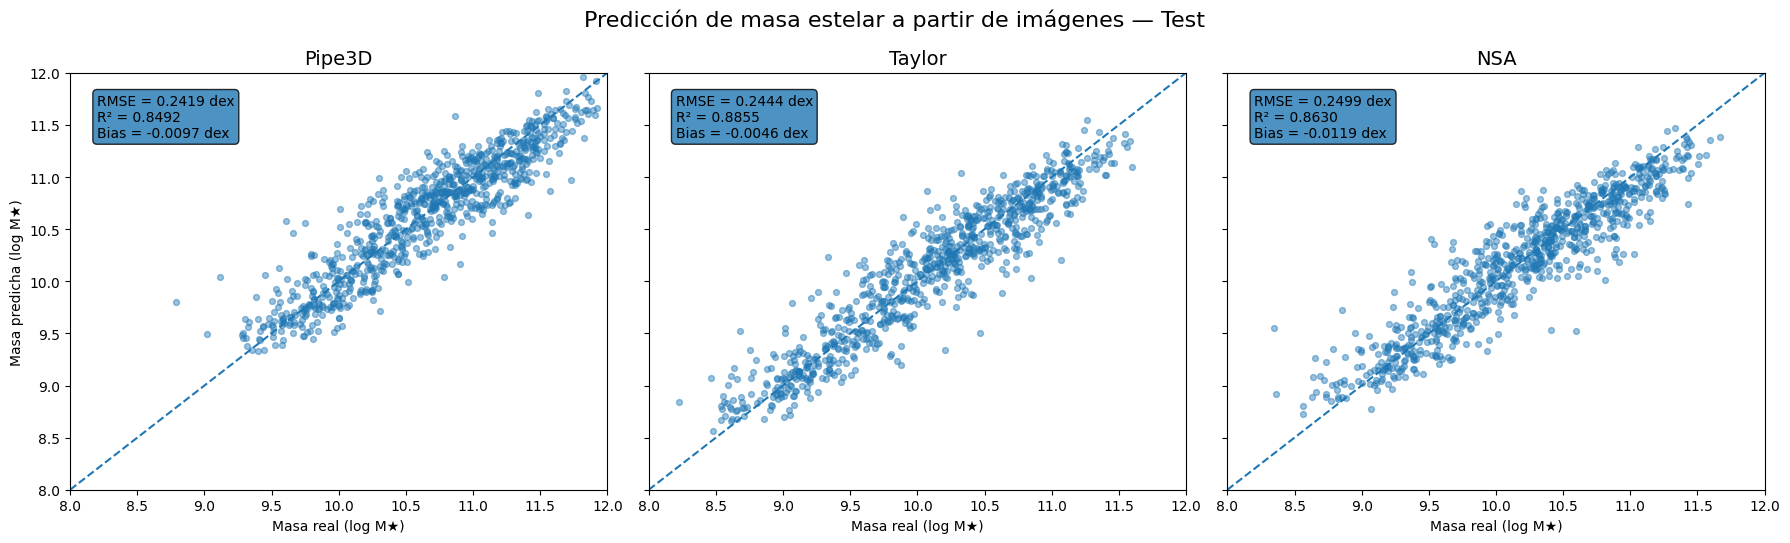


✓ Figura guardada en:
/content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_real_vs_predicho_tres_masas.png


In [ ]:
# ============================================================
# CELDA 22 — REAL VS PREDICHO EN TEST
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Organizar resultados de los tres targets
# ------------------------------------------------------------

resultados_test = {
    "Pipe3D": {
        "tabla": pred_test_pipe3d,
        "metricas": metricas_test_pipe3d
    },
    "Taylor": {
        "tabla": pred_test_taylor,
        "metricas": metricas_test_taylor
    },
    "NSA": {
        "tabla": pred_test_nsa,
        "metricas": metricas_test_nsa
    }
}


# ------------------------------------------------------------
# 2. Definir límites COMUNES para los tres paneles
# ------------------------------------------------------------

todos_valores = []

for datos in resultados_test.values():

    todos_valores.extend(
        datos["tabla"]["real"].to_numpy()
    )

    todos_valores.extend(
        datos["tabla"]["pred"].to_numpy()
    )


todos_valores = np.asarray(
    todos_valores
)

lim_min = (
    np.floor(
        todos_valores.min() * 2
    ) / 2
)

lim_max = (
    np.ceil(
        todos_valores.max() * 2
    ) / 2
)


print("=== LÍMITES COMUNES ===")

print(
    "Mínimo:",
    lim_min
)

print(
    "Máximo:",
    lim_max
)


# ------------------------------------------------------------
# 3. Crear figura comparativa
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharex=True,
    sharey=True
)


for ax, (nombre, datos) in zip(
    axes,
    resultados_test.items()
):

    tabla = datos["tabla"]
    metricas = datos["metricas"]


    # Puntos
    ax.scatter(
        tabla["real"],
        tabla["pred"],
        alpha=0.45,
        s=18
    )


    # Línea ideal y = x
    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        linestyle="--",
        linewidth=1.5
    )


    # Límites comunes
    ax.set_xlim(
        lim_min,
        lim_max
    )

    ax.set_ylim(
        lim_min,
        lim_max
    )


    # Título
    ax.set_title(
        nombre,
        fontsize=14
    )


    # Etiquetas
    ax.set_xlabel(
        "Masa real (log M★)"
    )


    # Métricas dentro del panel
    texto_metricas = (
        f"RMSE = {metricas['RMSE_dex']:.4f} dex\n"
        f"R² = {metricas['R2']:.4f}\n"
        f"Bias = {metricas['Bias_dex']:+.4f} dex"
    )


    ax.text(
        0.05,
        0.95,
        texto_metricas,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.8
        )
    )


axes[0].set_ylabel(
    "Masa predicha (log M★)"
)


fig.suptitle(
    "Predicción de masa estelar a partir de imágenes — Test",
    fontsize=16
)


plt.tight_layout()


# ------------------------------------------------------------
# 4. Guardar figura
# ------------------------------------------------------------

ruta_fig_real_pred = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_real_vs_predicho_tres_masas.png"
)


plt.savefig(
    ruta_fig_real_pred,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\n✓ Figura guardada en:"
)

print(
    ruta_fig_real_pred
)

En los tres modelos hay una relación fuerte entre masa real y predicha: los puntos siguen claramente la diagonal. Eso confirma que la red está extrayendo información de las imágenes relacionada con la masa estelar.

También se observa un patrón común de regresión hacia la media: en las masas más bajas hay varios objetos que quedan por encima de la diagonal, es decir, la red tiende a sobreestimarlos; mientras que en las masas más altas aparecen más objetos debajo de la diagonal, por lo que tiende a subestimarlos. Esto puede ocurrir aunque el bias global sea casi cero, porque los errores positivos y negativos se compensan.

La gráfica también ayuda a entender por qué Pipe3D y Taylor parecen “ganar” en métricas diferentes. Pipe3D muestra ligeramente menos dispersión absoluta alrededor de la diagonal, consistente con su RMSE de 0.2419 dex. Taylor, en cambio, cubre un rango real de masas más amplio y mantiene una relación muy definida con la diagonal; eso concuerda con su mayor \(R^2=0.8855\) y menor RMSE normalizado. NSA visualmente también sigue bien la relación, aunque presenta algo más de dispersión.

Lo siguiente que debemos ver es exactamente ese posible patrón de sobreestimación/subestimación: residuo vs. masa real.

## Etapa 23 — Residuos en función de la masa real

### ¿Qué se hará?

Se analizarán los residuos de los tres modelos en el conjunto Test.

El residuo se define como:

`residuo = masa predicha - masa real`

Por lo tanto:

- residuo positivo → el modelo sobreestima la masa;
- residuo negativo → el modelo subestima la masa;
- residuo cercano a cero → predicción cercana al valor real.

### ¿Por qué se hace?

La gráfica de masa real vs. masa predicha mostró indicios de una posible regresión hacia la media.

En particular, visualmente parece que:

- algunas galaxias de baja masa son sobreestimadas;
- algunas galaxias de alta masa son subestimadas.

El bias global de los tres modelos es cercano a cero, pero un bias global pequeño no garantiza que el error sea uniforme a lo largo de todo el rango de masas.

Por ello se estudiará directamente cómo cambia el residuo con la masa real.

### ¿Cómo se interpretará?

Un comportamiento ideal mostraría residuos distribuidos aleatoriamente alrededor de cero sin una tendencia clara con la masa.

Una pendiente negativa indicaría regresión hacia la media:

- residuos positivos a baja masa;
- residuos negativos a alta masa.

También se calculará el residuo medio dentro de intervalos de masa para visualizar mejor cualquier tendencia sistemática.

Esta etapa es únicamente diagnóstica.

Los modelos permanecen completamente congelados.

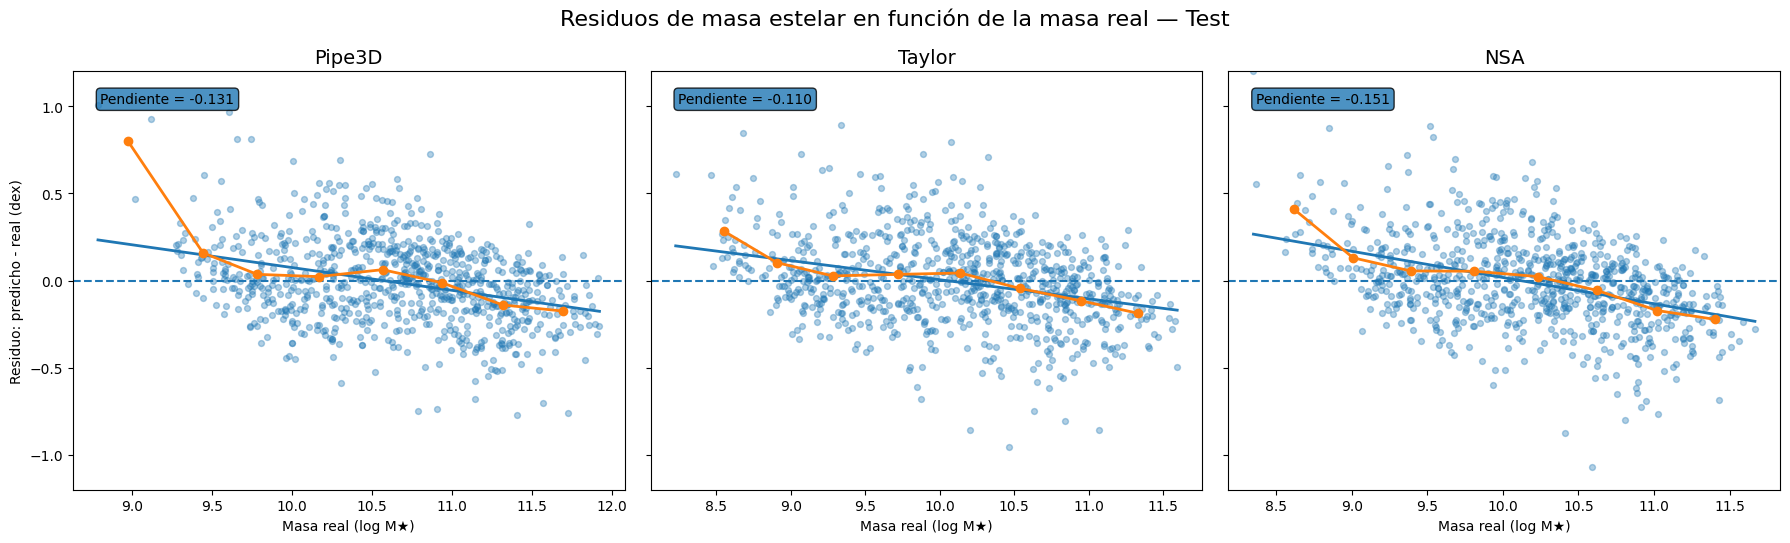


✓ Figura guardada en:
/content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_residuos_vs_masa_tres_targets.png


In [ ]:
# ============================================================
# CELDA 23 — RESIDUOS VS MASA REAL EN TEST
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Organizar predicciones
# ------------------------------------------------------------

resultados_residuos = {
    "Pipe3D": pred_test_pipe3d.copy(),
    "Taylor": pred_test_taylor.copy(),
    "NSA": pred_test_nsa.copy()
}


# ------------------------------------------------------------
# 2. Límites comunes del eje Y
# ------------------------------------------------------------

todos_residuos = np.concatenate(
    [
        df["residuo"].to_numpy()
        for df in resultados_residuos.values()
    ]
)

lim_residuo = np.ceil(
    np.max(
        np.abs(todos_residuos)
    ) * 10
) / 10


# ------------------------------------------------------------
# 3. Crear figura
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharey=True
)


for ax, (nombre, tabla) in zip(
    axes,
    resultados_residuos.items()
):

    # --------------------------------------------------------
    # Puntos individuales
    # --------------------------------------------------------

    ax.scatter(
        tabla["real"],
        tabla["residuo"],
        alpha=0.35,
        s=18
    )


    # --------------------------------------------------------
    # Línea de residuo ideal = 0
    # --------------------------------------------------------

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )


    # --------------------------------------------------------
    # Tendencia lineal
    # --------------------------------------------------------

    coef = np.polyfit(
        tabla["real"],
        tabla["residuo"],
        1
    )

    x_linea = np.linspace(
        tabla["real"].min(),
        tabla["real"].max(),
        200
    )

    y_linea = (
        coef[0] * x_linea
        + coef[1]
    )

    ax.plot(
        x_linea,
        y_linea,
        linewidth=2
    )


    # --------------------------------------------------------
    # Promedio por bins de masa
    # --------------------------------------------------------

    bins = np.linspace(
        tabla["real"].min(),
        tabla["real"].max(),
        9
    )

    tabla["bin_masa"] = pd.cut(
        tabla["real"],
        bins=bins,
        include_lowest=True
    )

    promedio_bins = (
        tabla
        .groupby(
            "bin_masa",
            observed=True
        )
        .agg(
            masa_media=("real", "mean"),
            residuo_medio=("residuo", "mean"),
            n=("residuo", "size")
        )
        .reset_index()
    )


    ax.plot(
        promedio_bins["masa_media"],
        promedio_bins["residuo_medio"],
        marker="o",
        linewidth=2
    )


    # --------------------------------------------------------
    # Formato
    # --------------------------------------------------------

    ax.set_title(
        nombre,
        fontsize=14
    )

    ax.set_xlabel(
        "Masa real (log M★)"
    )

    ax.set_ylim(
        -lim_residuo,
        lim_residuo
    )


    # Pendiente dentro del panel
    ax.text(
        0.05,
        0.95,
        f"Pendiente = {coef[0]:+.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.8
        )
    )


axes[0].set_ylabel(
    "Residuo: predicho - real (dex)"
)


fig.suptitle(
    "Residuos de masa estelar en función de la masa real — Test",
    fontsize=16
)


plt.tight_layout()


# ------------------------------------------------------------
# 4. Guardar figura
# ------------------------------------------------------------

ruta_fig_residuos = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_residuos_vs_masa_tres_targets.png"
)


plt.savefig(
    ruta_fig_residuos,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\n✓ Figura guardada en:"
)

print(
    ruta_fig_residuos
)

Las tres pendientes son negativas:

Pipe3D: −0.131
Taylor: −0.110
NSA: −0.151

Esto significa que los tres modelos presentan cierta regresión hacia la media: tienden a sobreestimar las masas bajas y a subestimar las masas altas.

De los tres, Taylor tiene la pendiente menos negativa, por lo que muestra el menor sesgo dependiente de la masa. NSA tiene la pendiente más negativa, indicando la mayor compresión del rango dinámico. Pipe3D queda en una posición intermedia.

También hay que tener cuidado con el primer punto naranja de Pipe3D, cerca de masa 9: parece bastante alto, pero probablemente corresponde a un bin con pocos objetos. No conviene interpretar ese único promedio sin revisar cuántas galaxias contiene.

Ahora la siguiente gráfica debe responder otra pregunta: ¿cómo se distribuyen los errores? Es decir, si son aproximadamente simétricos, si tienen colas grandes y cuál modelo concentra más galaxias cerca de residuo cero

## Etapa 24 — Distribución de los residuos en Test

### ¿Qué se hará?

Se estudiará la distribución completa de los residuos de los tres modelos:

`residuo = masa predicha - masa real`

Para cada target se mostrará un histograma de los errores y se marcarán:

- residuo cero;
- bias medio;
- mediana;
- percentiles 16 y 84.

### ¿Por qué se hace?

Dos modelos pueden tener valores similares de RMSE pero distribuciones de error diferentes.

Esta gráfica permitirá observar:

- qué tan concentrados están los errores alrededor de cero;
- si la distribución es aproximadamente simétrica;
- si existen colas con errores grandes;
- si aparecen valores atípicos;
- si el RMSE está siendo influido por unos pocos objetos extremos.

### Interpretación

Una distribución ideal estaría:

- centrada cerca de cero;
- aproximadamente simétrica;
- concentrada en un intervalo pequeño;
- con pocas galaxias en las colas.

Los percentiles 16 y 84 permiten describir el intervalo central que contiene aproximadamente el 68 % de los residuos sin asumir que la distribución sea perfectamente gaussiana.

Esta etapa es únicamente diagnóstica.

Los modelos permanecen congelados y no se realizará ningún ajuste posterior.

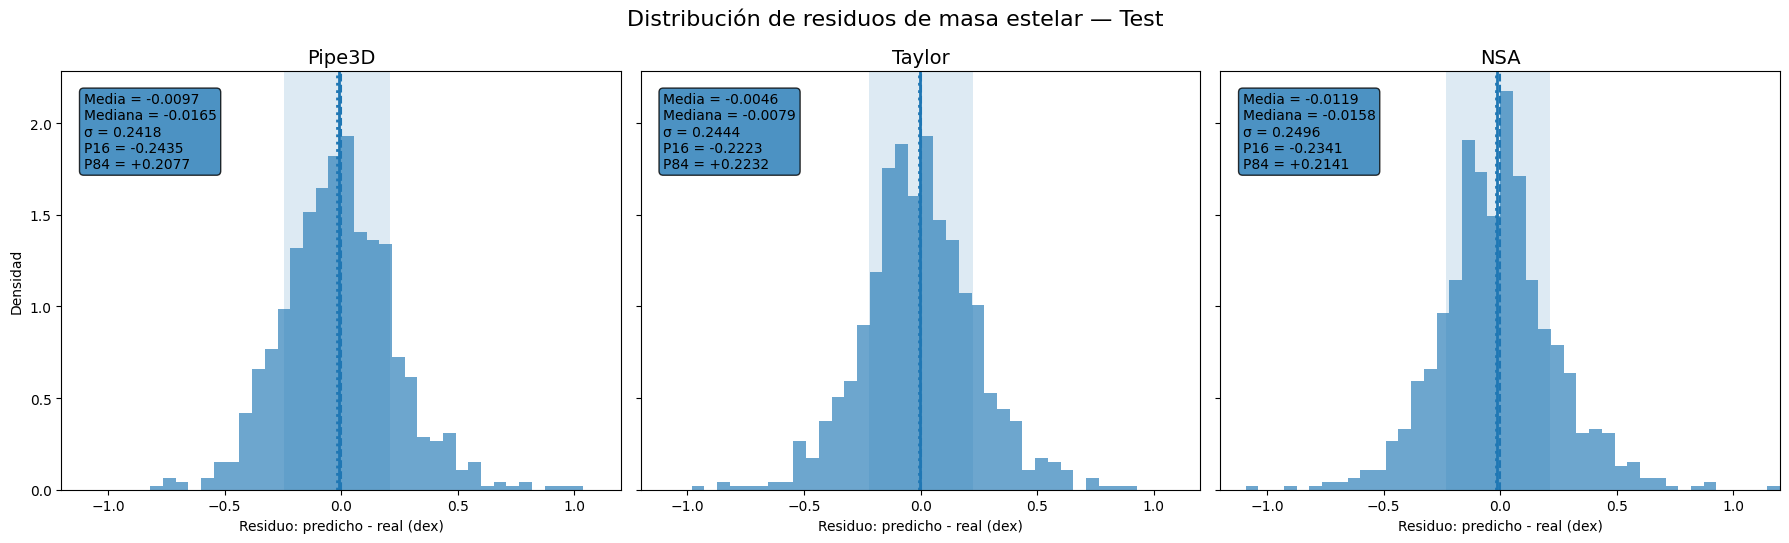


✓ Figura guardada en:
/content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_distribucion_residuos_tres_targets.png


In [ ]:
# ============================================================
# CELDA 24 — DISTRIBUCIÓN DE RESIDUOS EN TEST
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Organizar residuos
# ------------------------------------------------------------

residuos_test = {
    "Pipe3D": pred_test_pipe3d["residuo"].to_numpy(),
    "Taylor": pred_test_taylor["residuo"].to_numpy(),
    "NSA": pred_test_nsa["residuo"].to_numpy()
}


# ------------------------------------------------------------
# 2. Límites y bins comunes
# ------------------------------------------------------------

todos_residuos = np.concatenate(
    list(residuos_test.values())
)

lim = np.ceil(
    np.max(np.abs(todos_residuos)) * 10
) / 10

bins = np.linspace(
    -lim,
    lim,
    45
)


# ------------------------------------------------------------
# 3. Crear figura
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharex=True,
    sharey=True
)


for ax, (nombre, residuos) in zip(
    axes,
    residuos_test.items()
):

    # --------------------------------------------------------
    # Estadísticos
    # --------------------------------------------------------

    media = np.mean(residuos)

    mediana = np.median(residuos)

    p16 = np.percentile(
        residuos,
        16
    )

    p84 = np.percentile(
        residuos,
        84
    )

    std = np.std(
        residuos,
        ddof=0
    )


    # --------------------------------------------------------
    # Histograma
    # --------------------------------------------------------

    ax.hist(
        residuos,
        bins=bins,
        density=True,
        alpha=0.65
    )


    # --------------------------------------------------------
    # Líneas de referencia
    # --------------------------------------------------------

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.5,
        label="Error = 0"
    )

    ax.axvline(
        media,
        linewidth=2,
        label="Media"
    )

    ax.axvline(
        mediana,
        linestyle=":",
        linewidth=2,
        label="Mediana"
    )


    # --------------------------------------------------------
    # Intervalo central 16–84 %
    # --------------------------------------------------------

    ax.axvspan(
        p16,
        p84,
        alpha=0.15
    )


    # --------------------------------------------------------
    # Texto de resumen
    # --------------------------------------------------------

    texto = (
        f"Media = {media:+.4f}\n"
        f"Mediana = {mediana:+.4f}\n"
        f"σ = {std:.4f}\n"
        f"P16 = {p16:+.4f}\n"
        f"P84 = {p84:+.4f}"
    )

    ax.text(
        0.04,
        0.95,
        texto,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.8
        )
    )


    # --------------------------------------------------------
    # Formato
    # --------------------------------------------------------

    ax.set_title(
        nombre,
        fontsize=14
    )

    ax.set_xlabel(
        "Residuo: predicho - real (dex)"
    )

    ax.set_xlim(
        -lim,
        lim
    )


axes[0].set_ylabel(
    "Densidad"
)


fig.suptitle(
    "Distribución de residuos de masa estelar — Test",
    fontsize=16
)


plt.tight_layout()


# ------------------------------------------------------------
# 4. Guardar figura
# ------------------------------------------------------------

ruta_fig_distribucion = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_distribucion_residuos_tres_targets.png"
)


plt.savefig(
    ruta_fig_distribucion,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\n✓ Figura guardada en:"
)

print(
    ruta_fig_distribucion
)

Los tres residuos están muy centrados cerca de cero, consistente con los biases pequeños.
Pipe3D tiene la menor desviación estándar global: σ = 0.2418 dex.
Taylor tiene σ = 0.2444 dex, prácticamente igual, pero su intervalo central P16–P84 es incluso un poco más estrecho: aproximadamente [-0.222, +0.223] dex.
NSA presenta la dispersión global más alta: σ = 0.2496 dex.
Las tres distribuciones tienen colas de errores relativamente grandes. Eso explica por qué pequeñas diferencias en unos pocos objetos pueden afectar RMSE aunque el grueso de las predicciones esté bastante concentrado.

Un detalle importante: Taylor tiene el intervalo central del 68 % más compacto, mientras Pipe3D tiene la menor desviación estándar total. Eso sugiere que las diferencias entre Pipe3D y Taylor probablemente están más en las colas que en el comportamiento central.

Ahora conviene ver cómo aprendió cada modelo, porque allí podremos comparar sobreajuste, estabilidad y momento en que Validation dejó de mejorar.

## Etapa 25 — Curvas de aprendizaje Train vs. Validation

### ¿Qué se hará?

Se compararán las curvas de aprendizaje de los tres modelos definitivos:

- Pipe3D
- Taylor
- NSA

Para cada modelo se representará:

- RMSE de Train;
- RMSE de Validation;
- época correspondiente al mejor checkpoint.

### ¿Por qué se hace?

Las métricas finales indican qué tan bien funciona cada modelo, pero no muestran cómo evolucionó el aprendizaje.

Las curvas permiten analizar:

- velocidad de convergencia;
- estabilidad del entrenamiento;
- aparición de sobreajuste;
- separación entre Train y Validation;
- momento en que se obtuvo el mejor modelo.

En los tres experimentos el RMSE de Train continúa disminuyendo mientras Validation alcanza una meseta considerablemente más alta.

Esto indica que la red puede seguir ajustándose al conjunto Train sin mejorar necesariamente su capacidad de generalización.

### Importante

La primera época presenta un RMSE de Train cercano a 3 dex debido al ajuste inicial de la nueva capa de regresión.

Para visualizar con mayor detalle la fase útil del aprendizaje, la gráfica comenzará en la época 2.

La época 1 no se elimina del historial ni del análisis; solamente se omite de esta visualización para evitar que comprima el resto de la escala.

Los modelos permanecen congelados.

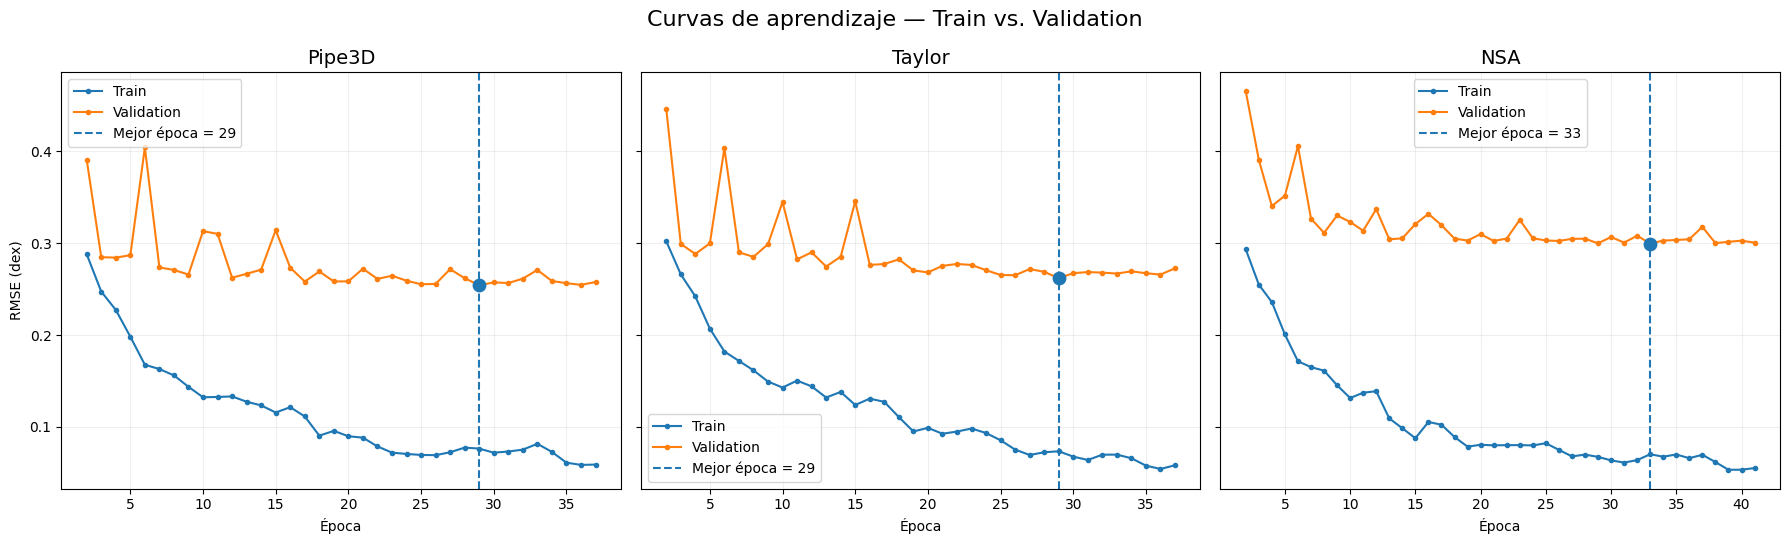


✓ Figura guardada en:
/content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_curvas_aprendizaje_tres_targets.png


In [ ]:
# ============================================================
# CELDA 25 — CURVAS DE APRENDIZAJE
# ============================================================

import os
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Organizar historiales
# ------------------------------------------------------------

historiales = {
    "Pipe3D": {
        "history": resultado_pipe3d_final["history"],
        "best_epoch": resultado_pipe3d_final["best_epoch"]
    },

    "Taylor": {
        "history": resultado_taylor_final["history"],
        "best_epoch": resultado_taylor_final["best_epoch"]
    },

    "NSA": {
        "history": resultado_nsa_final["history"],
        "best_epoch": resultado_nsa_final["best_epoch"]
    }
}


# ------------------------------------------------------------
# 2. Crear figura
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharey=True
)


for ax, (nombre, datos) in zip(
    axes,
    historiales.items()
):

    historial = datos["history"].copy()

    best_epoch = datos["best_epoch"]


    # --------------------------------------------------------
    # Omitir época 1 SOLO para visualización
    # --------------------------------------------------------

    historial_plot = historial[
        historial["epoca"] >= 2
    ].copy()


    # --------------------------------------------------------
    # Curva Train
    # --------------------------------------------------------

    ax.plot(
        historial_plot["epoca"],
        historial_plot["train_rmse"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="Train"
    )


    # --------------------------------------------------------
    # Curva Validation
    # --------------------------------------------------------

    ax.plot(
        historial_plot["epoca"],
        historial_plot["val_rmse"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="Validation"
    )


    # --------------------------------------------------------
    # Mejor época
    # --------------------------------------------------------

    ax.axvline(
        best_epoch,
        linestyle="--",
        linewidth=1.5,
        label=f"Mejor época = {best_epoch}"
    )


    # --------------------------------------------------------
    # Mejor RMSE Validation
    # --------------------------------------------------------

    mejor_rmse = historial.loc[
        historial["epoca"] == best_epoch,
        "val_rmse"
    ].iloc[0]


    ax.scatter(
        best_epoch,
        mejor_rmse,
        s=80,
        zorder=5
    )


    # --------------------------------------------------------
    # Formato
    # --------------------------------------------------------

    ax.set_title(
        nombre,
        fontsize=14
    )

    ax.set_xlabel(
        "Época"
    )

    ax.grid(
        alpha=0.2
    )

    ax.legend()


axes[0].set_ylabel(
    "RMSE (dex)"
)


fig.suptitle(
    "Curvas de aprendizaje — Train vs. Validation",
    fontsize=16
)


plt.tight_layout()


# ------------------------------------------------------------
# 3. Guardar figura
# ------------------------------------------------------------

ruta_fig_curvas = os.path.join(
    CARPETA_RESULTADOS,
    "figura_curvas_aprendizaje_tres_targets.png"
)


plt.savefig(
    ruta_fig_curvas,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\n✓ Figura guardada en:"
)

print(
    ruta_fig_curvas
)

Esta gráfica confirma algo importante: los tres modelos presentan sobreajuste, pero de manera comparable porque fueron entrenados bajo exactamente el mismo protocolo.

En los tres casos, el RMSE de Train continúa bajando mientras Validation alcanza una meseta. En la mejor época, las brechas aproximadas fueron: Pipe3D \(0.2543-0.0765\approx0.178\) dex, Taylor \(0.2621-0.0736\approx0.189\) dex y NSA \(0.2998-0.0703\approx0.230\) dex. Por tanto, NSA muestra la mayor brecha Train–Validation, coherente con que sea el target menos reproducible por la imagen bajo este protocolo. Pipe3D y Taylor son más cercanos entre sí.

También es bueno que las mejores épocas aparezcan bastante tarde —29, 29 y 33— y que Validation se estabilice antes de que el early stopping termine el entrenamiento. Eso indica que el mecanismo de selección del mejor checkpoint funcionó como esperábamos. No usaríamos las últimas épocas, sino los mínimos de Validation ya guardados.

## Etapa 26 — Comparación visual de las métricas finales en Test

### ¿Qué se hará?

Se construirán gráficas comparativas de las métricas finales obtenidas por:

- Pipe3D;
- Taylor;
- NSA.

Se mostrarán:

- RMSE;
- MAE;
- R²;
- RMSE normalizado por la desviación estándar del target.

### ¿Por qué se hace?

Las gráficas anteriores permiten estudiar el comportamiento interno de los modelos, pero para comunicar el resultado final es útil observar directamente las diferencias entre las tres definiciones de masa.

Esta comparación permitirá distinguir dos conceptos:

1. **Precisión absoluta**, representada principalmente por RMSE y MAE.
2. **Predictibilidad relativa**, representada por R² y RMSE/std.

### Interpretación

Para RMSE, MAE y RMSE/std:

`menor = mejor`

Para R²:

`mayor = mejor`

Esta visualización utiliza exclusivamente los resultados finales del conjunto Test.

No se realizará ningún nuevo ajuste de los modelos.

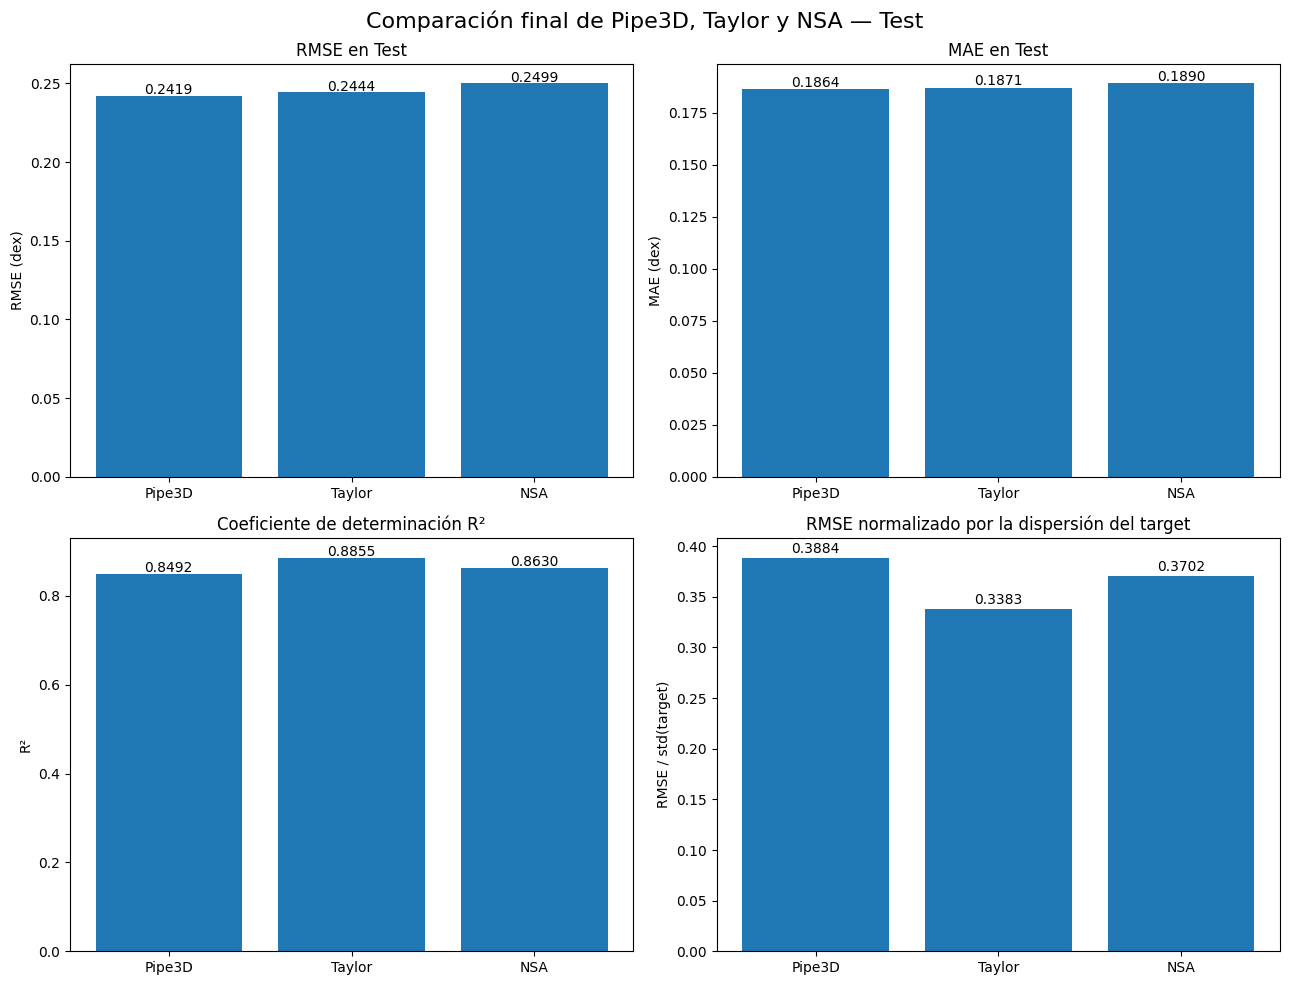


✓ Figura guardada en:
/content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_comparacion_metricas_finales.png


In [ ]:
# ============================================================
# CELDA 26 — COMPARACIÓN VISUAL DE MÉTRICAS FINALES
# ============================================================

import os
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Preparar tabla en un orden fijo
# ------------------------------------------------------------

orden_targets = [
    "Pipe3D",
    "Taylor",
    "NSA"
]

metricas_plot = (
    comparacion_test
    .set_index("target")
    .loc[orden_targets]
    .reset_index()
)


# ------------------------------------------------------------
# 2. Crear figura
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10)
)


# ------------------------------------------------------------
# 3. RMSE
# ------------------------------------------------------------

axes[0, 0].bar(
    metricas_plot["target"],
    metricas_plot["RMSE_dex"]
)

axes[0, 0].set_title(
    "RMSE en Test"
)

axes[0, 0].set_ylabel(
    "RMSE (dex)"
)

for i, valor in enumerate(
    metricas_plot["RMSE_dex"]
):
    axes[0, 0].text(
        i,
        valor + 0.001,
        f"{valor:.4f}",
        ha="center"
    )


# ------------------------------------------------------------
# 4. MAE
# ------------------------------------------------------------

axes[0, 1].bar(
    metricas_plot["target"],
    metricas_plot["MAE_dex"]
)

axes[0, 1].set_title(
    "MAE en Test"
)

axes[0, 1].set_ylabel(
    "MAE (dex)"
)

for i, valor in enumerate(
    metricas_plot["MAE_dex"]
):
    axes[0, 1].text(
        i,
        valor + 0.001,
        f"{valor:.4f}",
        ha="center"
    )


# ------------------------------------------------------------
# 5. R²
# ------------------------------------------------------------

axes[1, 0].bar(
    metricas_plot["target"],
    metricas_plot["R2"]
)

axes[1, 0].set_title(
    "Coeficiente de determinación R²"
)

axes[1, 0].set_ylabel(
    "R²"
)

for i, valor in enumerate(
    metricas_plot["R2"]
):
    axes[1, 0].text(
        i,
        valor + 0.005,
        f"{valor:.4f}",
        ha="center"
    )


# ------------------------------------------------------------
# 6. RMSE normalizado
# ------------------------------------------------------------

axes[1, 1].bar(
    metricas_plot["target"],
    metricas_plot["RMSE_sobre_std"]
)

axes[1, 1].set_title(
    "RMSE normalizado por la dispersión del target"
)

axes[1, 1].set_ylabel(
    "RMSE / std(target)"
)

for i, valor in enumerate(
    metricas_plot["RMSE_sobre_std"]
):
    axes[1, 1].text(
        i,
        valor + 0.005,
        f"{valor:.4f}",
        ha="center"
    )


# ------------------------------------------------------------
# 7. Título general y formato
# ------------------------------------------------------------

fig.suptitle(
    "Comparación final de Pipe3D, Taylor y NSA — Test",
    fontsize=16
)

plt.tight_layout()


# ------------------------------------------------------------
# 8. Guardar figura
# ------------------------------------------------------------

ruta_fig_metricas = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_comparacion_metricas_finales.png"
)

plt.savefig(
    ruta_fig_metricas,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\n✓ Figura guardada en:"
)

print(
    ruta_fig_metricas
)

## Etapa 27 — Bootstrap pareado de las diferencias de RMSE en Test

### ¿Qué se hará?

Se utilizará bootstrap para cuantificar la incertidumbre asociada a las diferencias de RMSE entre:

- Pipe3D y Taylor;
- Pipe3D y NSA;
- Taylor y NSA.

El análisis utilizará exclusivamente las 835 galaxias ya evaluadas en Test.

No se volverá a entrenar ningún modelo.

### ¿Por qué se hace?

El resultado puntual mostró:

- Pipe3D: RMSE = 0.2419 dex
- Taylor: RMSE = 0.2444 dex
- NSA: RMSE = 0.2499 dex

La diferencia entre Pipe3D y Taylor es solamente:

`0.2444 - 0.2419 = 0.0025 dex`

Una diferencia tan pequeña puede deberse a la composición particular de las 835 galaxias del conjunto Test.

El bootstrap permite estimar cuánto variaría esa diferencia si se tomaran otras muestras de galaxias de la misma población.

### ¿Por qué será un bootstrap pareado?

Los tres modelos fueron evaluados sobre exactamente las mismas galaxias.

Por ello, en cada repetición bootstrap se seleccionarán los mismos índices para Pipe3D, Taylor y NSA.

Esto conserva la correspondencia galaxia por galaxia y permite comparar los errores de manera más justa.

### Procedimiento

Se realizarán 10,000 remuestreos con reemplazo de las 835 galaxias.

En cada remuestreo se calculará nuevamente el RMSE de los tres targets y las diferencias:

`Taylor - Pipe3D`

`NSA - Pipe3D`

`NSA - Taylor`

Posteriormente se obtendrá un intervalo de confianza bootstrap del 95 % para cada diferencia.

### Interpretación

Para una diferencia definida como:

`RMSE_A - RMSE_B`

un valor positivo significa que A presenta mayor error que B.

Si el intervalo de confianza incluye cero, los datos de Test no permiten distinguir claramente cuál de los dos tiene menor RMSE.

Si todo el intervalo permanece por encima o por debajo de cero, existe evidencia más fuerte de una diferencia en el error para este conjunto de modelos.

### Limitación

Este bootstrap cuantifica la incertidumbre debida a las galaxias que componen Test.

No cuantifica la variabilidad que podría aparecer al volver a entrenar las redes con diferentes semillas o inicializaciones.

Los modelos permanecen congelados.

=== BOOTSTRAP PAREADO — DIFERENCIAS DE RMSE ===


,comparacion,diferencia_media,mediana,IC95_inferior,IC95_superior,P_diferencia_positiva
0,Taylor - Pipe3D,+0.00246,+0.00244,-0.00778,+0.01261,0.6826
1,NSA - Pipe3D,+0.00783,+0.00773,-0.00409,+0.02034,0.8994
2,NSA - Taylor,+0.00537,+0.00501,-0.00300,+0.01584,0.8824


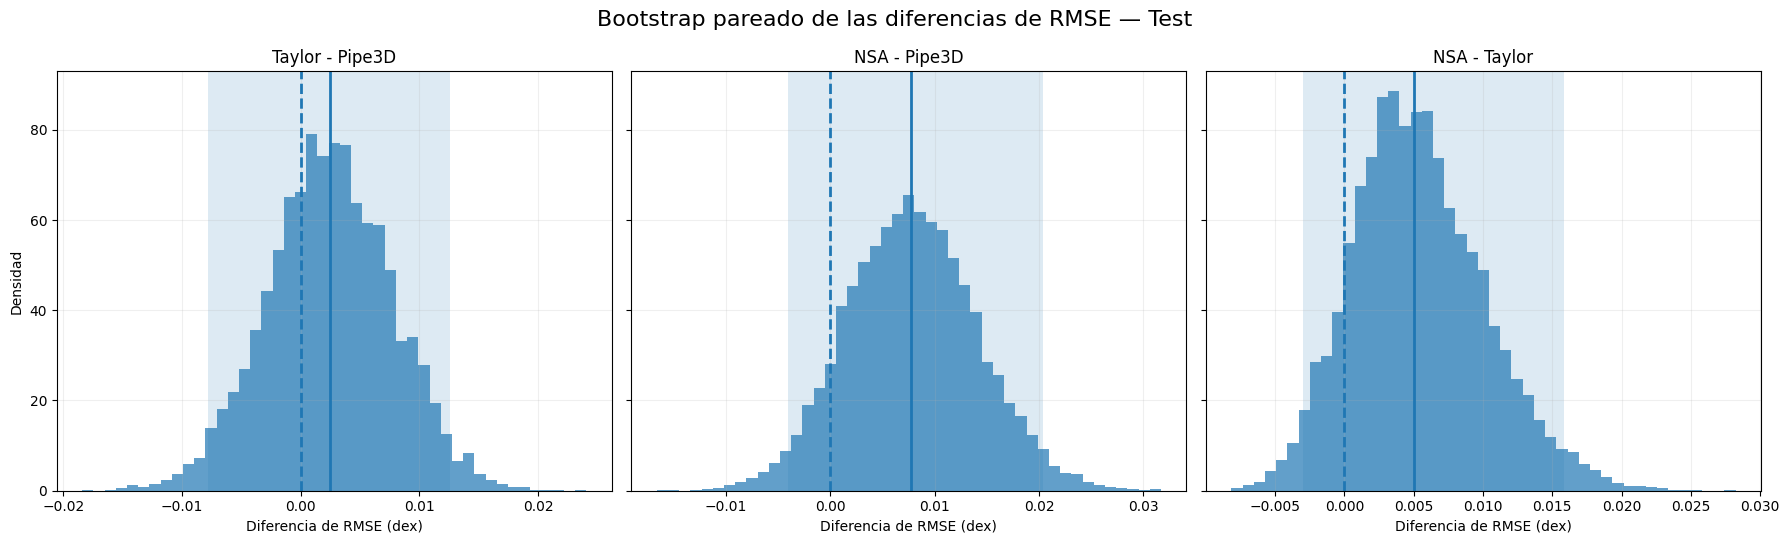


✓ Bootstrap pareado completado.
✓ Repeticiones: 10000
✓ Tabla guardada en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/bootstrap_diferencias_RMSE_TEST.csv
✓ Figura guardada en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_bootstrap_diferencias_RMSE.png


In [ ]:
# ============================================================
# CELDA 27 — BOOTSTRAP PAREADO DE DIFERENCIAS DE RMSE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Verificar correspondencia exacta de las galaxias
# ------------------------------------------------------------

assert (
    pred_test_pipe3d["mangaid"].tolist()
    == pred_test_taylor["mangaid"].tolist()
)

assert (
    pred_test_pipe3d["mangaid"].tolist()
    == pred_test_nsa["mangaid"].tolist()
)


# ------------------------------------------------------------
# 2. Extraer residuos
# ------------------------------------------------------------

res_pipe3d = (
    pred_test_pipe3d["residuo"]
    .to_numpy()
)

res_taylor = (
    pred_test_taylor["residuo"]
    .to_numpy()
)

res_nsa = (
    pred_test_nsa["residuo"]
    .to_numpy()
)


N_TEST = len(res_pipe3d)

N_BOOT = 10000

rng = np.random.default_rng(
    SEED
)


# ------------------------------------------------------------
# 3. Contenedores del bootstrap
# ------------------------------------------------------------

delta_taylor_pipe3d = np.empty(
    N_BOOT
)

delta_nsa_pipe3d = np.empty(
    N_BOOT
)

delta_nsa_taylor = np.empty(
    N_BOOT
)


# ------------------------------------------------------------
# 4. Bootstrap pareado
# ------------------------------------------------------------

for i in range(N_BOOT):

    indices = rng.integers(
        0,
        N_TEST,
        size=N_TEST
    )

    rmse_pipe3d = np.sqrt(
        np.mean(
            res_pipe3d[indices] ** 2
        )
    )

    rmse_taylor = np.sqrt(
        np.mean(
            res_taylor[indices] ** 2
        )
    )

    rmse_nsa = np.sqrt(
        np.mean(
            res_nsa[indices] ** 2
        )
    )


    delta_taylor_pipe3d[i] = (
        rmse_taylor
        - rmse_pipe3d
    )

    delta_nsa_pipe3d[i] = (
        rmse_nsa
        - rmse_pipe3d
    )

    delta_nsa_taylor[i] = (
        rmse_nsa
        - rmse_taylor
    )


# ------------------------------------------------------------
# 5. Función resumen
# ------------------------------------------------------------

def resumen_bootstrap(
    valores,
    comparacion
):

    media = np.mean(
        valores
    )

    mediana = np.median(
        valores
    )

    ci_low, ci_high = np.percentile(
        valores,
        [2.5, 97.5]
    )

    prob_positivo = np.mean(
        valores > 0
    )


    return {
        "comparacion": comparacion,
        "diferencia_media": media,
        "mediana": mediana,
        "IC95_inferior": ci_low,
        "IC95_superior": ci_high,
        "P_diferencia_positiva":
            prob_positivo
    }


# ------------------------------------------------------------
# 6. Tabla resumen
# ------------------------------------------------------------

tabla_bootstrap = pd.DataFrame(
    [
        resumen_bootstrap(
            delta_taylor_pipe3d,
            "Taylor - Pipe3D"
        ),

        resumen_bootstrap(
            delta_nsa_pipe3d,
            "NSA - Pipe3D"
        ),

        resumen_bootstrap(
            delta_nsa_taylor,
            "NSA - Taylor"
        )
    ]
)


print("=== BOOTSTRAP PAREADO — DIFERENCIAS DE RMSE ===")

display(
    tabla_bootstrap.style.format(
        {
            "diferencia_media": "{:+.5f}",
            "mediana": "{:+.5f}",
            "IC95_inferior": "{:+.5f}",
            "IC95_superior": "{:+.5f}",
            "P_diferencia_positiva": "{:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 7. Crear figura
# ------------------------------------------------------------

distribuciones = {
    "Taylor - Pipe3D":
        delta_taylor_pipe3d,

    "NSA - Pipe3D":
        delta_nsa_pipe3d,

    "NSA - Taylor":
        delta_nsa_taylor
}


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharey=True
)


for ax, (nombre, valores) in zip(
    axes,
    distribuciones.items()
):

    ci_low, ci_high = np.percentile(
        valores,
        [2.5, 97.5]
    )

    mediana = np.median(
        valores
    )


    ax.hist(
        valores,
        bins=45,
        density=True,
        alpha=0.7
    )


    # Cero = ausencia de diferencia
    ax.axvline(
        0,
        linestyle="--",
        linewidth=2,
        label="Sin diferencia"
    )


    # Mediana bootstrap
    ax.axvline(
        mediana,
        linewidth=2,
        label="Mediana"
    )


    # Intervalo 95 %
    ax.axvspan(
        ci_low,
        ci_high,
        alpha=0.15,
        label="IC 95 %"
    )


    ax.set_title(
        nombre
    )

    ax.set_xlabel(
        "Diferencia de RMSE (dex)"
    )

    ax.grid(
        alpha=0.2
    )


axes[0].set_ylabel(
    "Densidad"
)


fig.suptitle(
    "Bootstrap pareado de las diferencias de RMSE — Test",
    fontsize=16
)


plt.tight_layout()


# ------------------------------------------------------------
# 8. Guardar resultados
# ------------------------------------------------------------

ruta_bootstrap_csv = os.path.join(
    CARPETA_RESULTADOS,
    "bootstrap_diferencias_RMSE_TEST.csv"
)

tabla_bootstrap.to_csv(
    ruta_bootstrap_csv,
    index=False
)


ruta_fig_bootstrap = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_bootstrap_diferencias_RMSE.png"
)


plt.savefig(
    ruta_fig_bootstrap,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\n✓ Bootstrap pareado completado."
)

print(
    "✓ Repeticiones:",
    N_BOOT
)

print(
    "✓ Tabla guardada en:",
    ruta_bootstrap_csv
)

print(
    "✓ Figura guardada en:",
    ruta_fig_bootstrap
)

Esta gráfica cambia bastante la interpretación: los tres intervalos bootstrap del 95 % atraviesan el cero.

Eso significa que, aunque los RMSE puntuales fueron Pipe3D 0.2419, Taylor 0.2444 y NSA 0.2499 dex, con estas 835 galaxias no tenemos evidencia suficiente para afirmar que las diferencias de RMSE absoluto entre los tres targets sean robustas. En particular, la pequeña ventaja de Pipe3D sobre Taylor (0.0025 dex) es compatible con variación muestral.

Entonces la conclusión se vuelve más precisa: en error absoluto los tres modelos son muy similares. La separación más clara que hemos observado sigue estando en las métricas relativas, donde Taylor tiene mayor \(R^2\) y menor RMSE/std.

## Etapa 28 — Distribución acumulada del error absoluto en Test

### ¿Qué se hará?

Se comparará la distribución acumulada del error absoluto para Pipe3D, Taylor y NSA.

Para cada galaxia se calculará:

`error absoluto = |predicción - valor real|`

Posteriormente se mostrará qué fracción de las galaxias presenta un error menor o igual a un determinado valor en dex.

### ¿Por qué se hace?

El RMSE puede verse afectado de manera importante por unos pocos errores grandes.

La distribución acumulada permite responder preguntas más directas como:

- ¿qué fracción de galaxias tiene un error menor a 0.1 dex?
- ¿qué fracción tiene un error menor a 0.2 dex?
- ¿qué fracción tiene un error menor a 0.3 dex?

Si una curva se encuentra por encima de las demás, significa que una mayor proporción de galaxias alcanza errores pequeños.

### Interpretación

Una curva que sube más rápidamente hacia 1 indica una mayor concentración de predicciones precisas.

También se calcularán explícitamente las fracciones de galaxias con:

- error ≤ 0.1 dex;
- error ≤ 0.2 dex;
- error ≤ 0.3 dex;
- error ≤ 0.5 dex.

Esta etapa es únicamente descriptiva y no modifica los modelos.

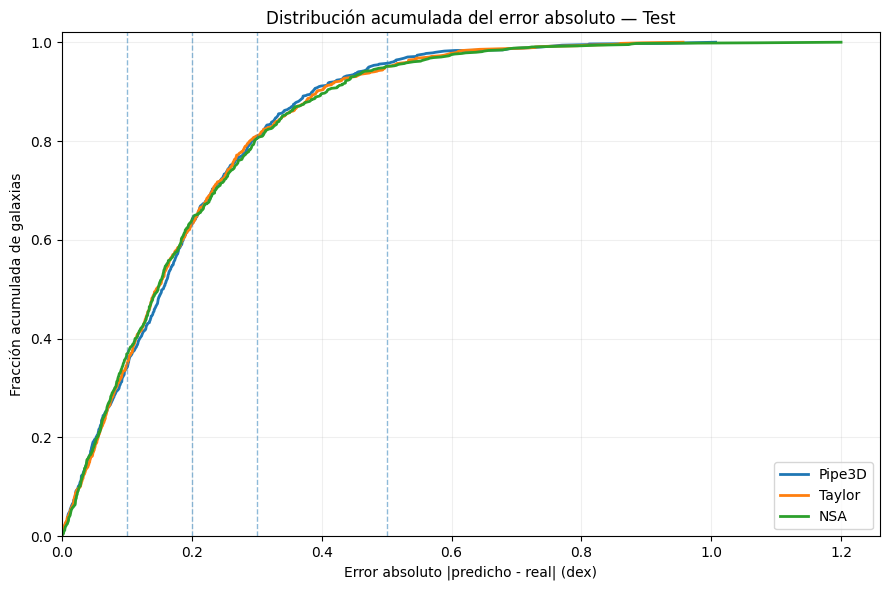

=== FRACCIÓN DE GALAXIAS BAJO CADA ERROR ===


,target,fraccion_error_le_0.1,fraccion_error_le_0.2,fraccion_error_le_0.3,fraccion_error_le_0.5
0,Pipe3D,34.0%,63.2%,80.5%,95.7%
1,Taylor,34.6%,63.1%,81.0%,95.1%
2,NSA,36.9%,64.0%,80.4%,95.1%



✓ ECDF del error absoluto calculada.
✓ Tabla de umbrales guardada.


In [ ]:
# ============================================================
# CELDA 28 — ECDF DEL ERROR ABSOLUTO EN TEST
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Calcular errores absolutos
# ------------------------------------------------------------

errores_abs = {
    "Pipe3D": np.abs(
        pred_test_pipe3d["residuo"].to_numpy()
    ),

    "Taylor": np.abs(
        pred_test_taylor["residuo"].to_numpy()
    ),

    "NSA": np.abs(
        pred_test_nsa["residuo"].to_numpy()
    )
}


# ------------------------------------------------------------
# 2. Crear figura ECDF
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


for nombre, errores in errores_abs.items():

    x = np.sort(
        errores
    )

    y = np.arange(
        1,
        len(x) + 1
    ) / len(x)

    plt.plot(
        x,
        y,
        linewidth=2,
        label=nombre
    )


# ------------------------------------------------------------
# 3. Líneas de referencia
# ------------------------------------------------------------

for umbral in [
    0.1,
    0.2,
    0.3,
    0.5
]:

    plt.axvline(
        umbral,
        linestyle="--",
        linewidth=1,
        alpha=0.5
    )


plt.xlabel(
    "Error absoluto |predicho - real| (dex)"
)

plt.ylabel(
    "Fracción acumulada de galaxias"
)

plt.title(
    "Distribución acumulada del error absoluto — Test"
)

plt.ylim(
    0,
    1.02
)

plt.xlim(
    left=0
)

plt.grid(
    alpha=0.2
)

plt.legend()

plt.tight_layout()


# ------------------------------------------------------------
# 4. Guardar figura
# ------------------------------------------------------------

ruta_fig_ecdf = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_ECDF_error_absoluto.png"
)

plt.savefig(
    ruta_fig_ecdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 5. Tabla de fracciones bajo distintos umbrales
# ------------------------------------------------------------

umbrales = [
    0.1,
    0.2,
    0.3,
    0.5
]

filas = []


for nombre, errores in errores_abs.items():

    fila = {
        "target": nombre
    }

    for umbral in umbrales:

        fila[
            f"fraccion_error_le_{umbral}"
        ] = np.mean(
            errores <= umbral
        )

    filas.append(
        fila
    )


tabla_umbrales = pd.DataFrame(
    filas
)


print(
    "=== FRACCIÓN DE GALAXIAS BAJO CADA ERROR ==="
)

display(
    tabla_umbrales.style.format(
        {
            "fraccion_error_le_0.1":
                "{:.1%}",

            "fraccion_error_le_0.2":
                "{:.1%}",

            "fraccion_error_le_0.3":
                "{:.1%}",

            "fraccion_error_le_0.5":
                "{:.1%}"
        }
    )
)


# ------------------------------------------------------------
# 6. Guardar tabla
# ------------------------------------------------------------

ruta_tabla_umbrales = os.path.join(
    CARPETA_RESULTADOS,
    "fracciones_error_absoluto_TEST.csv"
)

tabla_umbrales.to_csv(
    ruta_tabla_umbrales,
    index=False
)


print(
    "\n✓ ECDF del error absoluto calculada."
)

print(
    "✓ Tabla de umbrales guardada."
)

Esta gráfica es muy útil porque muestra que las tres curvas prácticamente se superponen durante casi todo el rango de error. Eso refuerza lo que vimos con el bootstrap: para la mayoría de las galaxias, Pipe3D, Taylor y NSA tienen un desempeño absoluto muy parecido.

No hay una curva que domine claramente a las otras. Las pequeñas diferencias de RMSE que vimos (0.2419, 0.2444, 0.2499 dex) parecen venir más de diferencias sutiles en las colas y en algunos objetos difíciles que de una superioridad general para la mayoría de las 835 galaxias.

## Etapa 29 — Distribución de las tres definiciones de masa estelar en Test

### ¿Qué se hará?

Se compararán las distribuciones de las masas reales utilizadas como target para:

- Pipe3D;
- Taylor;
- NSA.

La comparación se realizará sobre exactamente las mismas 835 galaxias del conjunto Test.

### ¿Por qué se hace?

Los tres modelos presentan valores de RMSE absoluto muy similares, pero Taylor obtuvo:

- el mayor R²;
- el menor RMSE normalizado por la desviación estándar del target.

Esto puede ocurrir porque las tres definiciones de masa no tienen exactamente la misma dispersión.

En Test se obtuvo:

- Pipe3D: `std(target) = 0.6230 dex`;
- Taylor: `std(target) = 0.7224 dex`;
- NSA: `std(target) = 0.6750 dex`.

Taylor presenta la distribución más dispersa de las tres.

Por lo tanto, un error absoluto similar representa una fracción menor de la variabilidad total de Taylor.

### Interpretación

Esta gráfica permitirá distinguir entre:

**precisión absoluta**

y

**capacidad para reproducir la variabilidad del target**.

Una mayor dispersión del target puede producir un R² mayor aunque el RMSE absoluto sea parecido.

Esta etapa es únicamente descriptiva y no modifica ningún resultado.

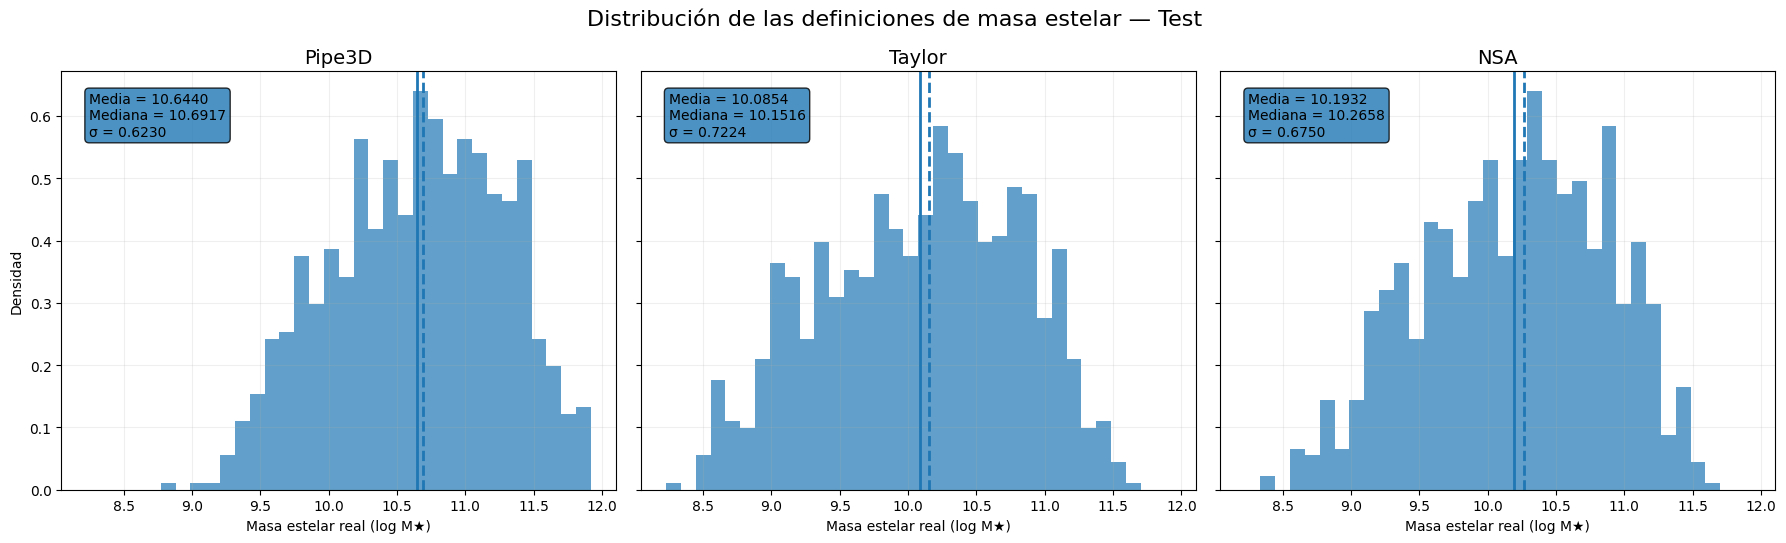


✓ Figura guardada en:
/content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_distribucion_targets.png


In [ ]:
# ============================================================
# CELDA 29 — DISTRIBUCIÓN DE LOS TARGETS REALES EN TEST
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Extraer valores reales
# ------------------------------------------------------------

targets_reales = {
    "Pipe3D": pred_test_pipe3d["real"].to_numpy(),
    "Taylor": pred_test_taylor["real"].to_numpy(),
    "NSA": pred_test_nsa["real"].to_numpy()
}


# ------------------------------------------------------------
# 2. Definir bins comunes
# ------------------------------------------------------------

todos_targets = np.concatenate(
    list(targets_reales.values())
)

bins = np.linspace(
    todos_targets.min(),
    todos_targets.max(),
    35
)


# ------------------------------------------------------------
# 3. Crear figura
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharex=True,
    sharey=True
)


for ax, (nombre, valores) in zip(
    axes,
    targets_reales.items()
):

    media = np.mean(valores)

    mediana = np.median(valores)

    std = np.std(
        valores,
        ddof=0
    )


    # Histograma
    ax.hist(
        valores,
        bins=bins,
        density=True,
        alpha=0.7
    )


    # Media
    ax.axvline(
        media,
        linewidth=2,
        label="Media"
    )


    # Mediana
    ax.axvline(
        mediana,
        linestyle="--",
        linewidth=2,
        label="Mediana"
    )


    # Texto
    texto = (
        f"Media = {media:.4f}\n"
        f"Mediana = {mediana:.4f}\n"
        f"σ = {std:.4f}"
    )

    ax.text(
        0.05,
        0.95,
        texto,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.8
        )
    )


    ax.set_title(
        nombre,
        fontsize=14
    )

    ax.set_xlabel(
        "Masa estelar real (log M★)"
    )

    ax.grid(
        alpha=0.2
    )


axes[0].set_ylabel(
    "Densidad"
)


fig.suptitle(
    "Distribución de las definiciones de masa estelar — Test",
    fontsize=16
)


plt.tight_layout()


# ------------------------------------------------------------
# 4. Guardar figura
# ------------------------------------------------------------

ruta_fig_targets = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_distribucion_targets.png"
)


plt.savefig(
    ruta_fig_targets,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\n✓ Figura guardada en:"
)

print(
    ruta_fig_targets
)

Esta gráfica explica muy bien por qué Taylor obtiene mejor \(R^2\) y RMSE/std aunque su RMSE absoluto sea casi igual al de Pipe3D.

Taylor tiene la distribución más amplia: \(\sigma=0.7224\) dex, frente a 0.6230 de Pipe3D y 0.6750 de NSA. Si dos modelos cometen un error absoluto parecido, ese mismo error representa una fracción menor de la variabilidad total cuando el target es más disperso. Por eso Taylor obtiene RMSE/std = 0.3383 y \(R^2=0.8855\).

También vemos claramente que las tres escalas de masa no tienen el mismo punto cero. En Test, las medias son aproximadamente 10.644 para Pipe3D, 10.085 para Taylor y 10.193 para NSA. Esto no es un problema para nuestro experimento, pero sí es científicamente importante: las tres etiquetas no son simplemente la misma variable con ruido.

Ahora conviene visualizar cómo se relaciona

## Etapa 30 — Comparación directa entre las tres definiciones de masa estelar

### ¿Qué se hará?

Se compararán directamente las masas reales de las mismas 835 galaxias de Test mediante tres relaciones:

- Pipe3D vs. Taylor
- Pipe3D vs. NSA
- Taylor vs. NSA

Para cada comparación se calcularán:

- correlación de Pearson;
- diferencia media entre ambas masas;
- desviación estándar de esa diferencia.

También se mostrará la línea ideal:

`masa A = masa B`

### ¿Por qué se hace?

Las distribuciones anteriores mostraron que las tres definiciones de masa presentan:

- medias diferentes;
- dispersiones diferentes;
- rangos ligeramente distintos.

Esto significa que las diferencias entre los modelos CNN pueden estar relacionadas no solamente con la capacidad de la red, sino también con las propiedades estadísticas de las propias etiquetas.

La comparación directa permite determinar si dos estimadores:

- mantienen aproximadamente el mismo orden relativo de las galaxias;
- presentan un offset sistemático;
- muestran dispersión adicional galaxia por galaxia.

### Interpretación

Una correlación alta indica que ambos estimadores ordenan de manera similar las galaxias por masa.

Una diferencia media distinta de cero indica un desplazamiento sistemático entre las escalas.

La desviación estándar de las diferencias indica cuánto varía ese desplazamiento entre galaxias.

Estas comparaciones describen las etiquetas.

No permiten determinar cuál estimación representa necesariamente la masa estelar físicamente más verdadera.

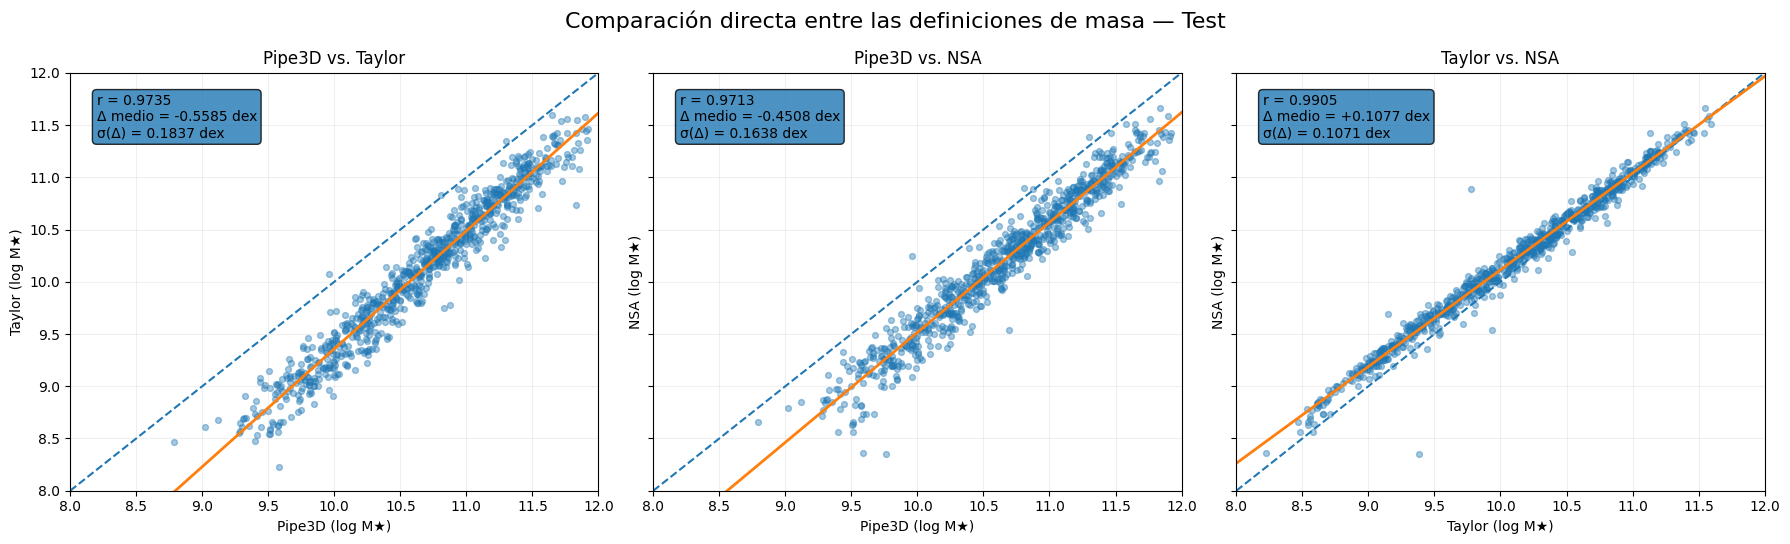


=== COMPARACIÓN ENTRE DEFINICIONES DE MASA ===


,comparacion,Pearson_r,diferencia_media_dex,std_diferencia_dex
0,Taylor - Pipe3D,0.9735,-0.5585,0.1837
1,NSA - Pipe3D,0.9713,-0.4508,0.1638
2,NSA - Taylor,0.9905,+0.1077,0.1071



✓ Comparación entre etiquetas completada.


In [ ]:
# ============================================================
# CELDA 30 — COMPARACIÓN ENTRE LAS TRES MASAS REALES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Construir tabla común de las 835 galaxias de Test
# ------------------------------------------------------------

masas_test = pd.DataFrame(
    {
        "mangaid": pred_test_pipe3d["mangaid"],
        "Pipe3D": pred_test_pipe3d["real"],
        "Taylor": pred_test_taylor["real"],
        "NSA": pred_test_nsa["real"]
    }
)


assert len(masas_test) == 835


# ------------------------------------------------------------
# 2. Definir comparaciones
# ------------------------------------------------------------

comparaciones = [
    ("Pipe3D", "Taylor"),
    ("Pipe3D", "NSA"),
    ("Taylor", "NSA")
]


# ------------------------------------------------------------
# 3. Límites comunes
# ------------------------------------------------------------

todos = masas_test[
    ["Pipe3D", "Taylor", "NSA"]
].to_numpy().ravel()

lim_min = np.floor(
    todos.min() * 2
) / 2

lim_max = np.ceil(
    todos.max() * 2
) / 2


# ------------------------------------------------------------
# 4. Figura
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharex=True,
    sharey=True
)


resumen_pares = []


for ax, (x_col, y_col) in zip(
    axes,
    comparaciones
):

    x = masas_test[x_col].to_numpy()
    y = masas_test[y_col].to_numpy()

    diferencia = y - x


    # --------------------------------------------------------
    # Estadísticos
    # --------------------------------------------------------

    pearson = np.corrcoef(
        x,
        y
    )[0, 1]

    bias_par = np.mean(
        diferencia
    )

    std_diferencia = np.std(
        diferencia,
        ddof=0
    )


    resumen_pares.append(
        {
            "comparacion":
                f"{y_col} - {x_col}",

            "Pearson_r":
                pearson,

            "diferencia_media_dex":
                bias_par,

            "std_diferencia_dex":
                std_diferencia
        }
    )


    # --------------------------------------------------------
    # Scatter
    # --------------------------------------------------------

    ax.scatter(
        x,
        y,
        alpha=0.4,
        s=18
    )


    # Línea igualdad
    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        linestyle="--",
        linewidth=1.5
    )


    # Ajuste lineal descriptivo
    coef = np.polyfit(
        x,
        y,
        1
    )

    x_fit = np.linspace(
        lim_min,
        lim_max,
        200
    )

    y_fit = (
        coef[0] * x_fit
        + coef[1]
    )

    ax.plot(
        x_fit,
        y_fit,
        linewidth=2
    )


    # --------------------------------------------------------
    # Texto
    # --------------------------------------------------------

    texto = (
        f"r = {pearson:.4f}\n"
        f"Δ medio = {bias_par:+.4f} dex\n"
        f"σ(Δ) = {std_diferencia:.4f} dex"
    )


    ax.text(
        0.05,
        0.95,
        texto,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.8
        )
    )


    ax.set_title(
        f"{x_col} vs. {y_col}"
    )

    ax.set_xlabel(
        f"{x_col} (log M★)"
    )

    ax.set_ylabel(
        f"{y_col} (log M★)"
    )

    ax.set_xlim(
        lim_min,
        lim_max
    )

    ax.set_ylim(
        lim_min,
        lim_max
    )

    ax.grid(
        alpha=0.2
    )


fig.suptitle(
    "Comparación directa entre las definiciones de masa — Test",
    fontsize=16
)

plt.tight_layout()


# ------------------------------------------------------------
# 5. Guardar figura
# ------------------------------------------------------------

ruta_fig_pares = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_comparacion_entre_masas.png"
)

plt.savefig(
    ruta_fig_pares,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. Tabla resumen
# ------------------------------------------------------------

tabla_pares = pd.DataFrame(
    resumen_pares
)


print(
    "\n=== COMPARACIÓN ENTRE DEFINICIONES DE MASA ==="
)

display(
    tabla_pares.style.format(
        {
            "Pearson_r": "{:.4f}",
            "diferencia_media_dex": "{:+.4f}",
            "std_diferencia_dex": "{:.4f}"
        }
    )
)


tabla_pares.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "comparacion_entre_masas_TEST.csv"
    ),
    index=False
)


print(
    "\n✓ Comparación entre etiquetas completada."
)

Esta gráfica es muy informativa, porque muestra que las diferencias entre las tres etiquetas no son solo ruido.

Lo más claro es que Taylor y NSA son muchísimo más parecidas entre sí que cualquiera de ellas con Pipe3D:

Taylor vs NSA: \(r=0.9905\), con dispersión de la diferencia de solo 0.1071 dex.
Pipe3D vs Taylor: \(r=0.9735\), con dispersión de 0.1837 dex.
Pipe3D vs NSA: \(r=0.9713\), con dispersión de 0.1638 dex.

Además existe un offset sistemático fuerte. Para las mismas galaxias:

$$ \text{Taylor} - \text{Pipe3D} = -0.5585\ \text{dex} $$

y

$$ \text{NSA} - \text{Pipe3D} = -0.4508\ \text{dex} $$

Es decir, Pipe3D asigna en promedio masas considerablemente mayores que Taylor y NSA. En cambio:

$$ \text{NSA} - \text{Taylor} = +0.1077\ \text{dex} $$

por lo que Taylor y NSA están mucho más próximas entre sí.

Esto también ayuda a entender nuestro experimento de CNN: estamos pidiendo a la misma imagen que reproduzca tres escalas relacionadas, pero no equivalentes. Taylor y NSA comparten una relación galaxia por galaxia extremadamente estrecha, mientras Pipe3D presenta un desplazamiento mayor y una dispersión adicional.

## Etapa 31 — Análisis de acuerdo entre las definiciones de masa

### ¿Qué se hará?

Se analizará cómo cambia la diferencia entre dos estimadores de masa a lo largo del rango de masas.

Se estudiarán las comparaciones:

- Taylor − Pipe3D
- NSA − Pipe3D
- NSA − Taylor

Para cada galaxia se calculará:

`media del par = (masa A + masa B) / 2`

y

`diferencia = masa B - masa A`

### ¿Por qué se hace?

La comparación directa mostró offsets medios importantes entre las escalas de masa.

Sin embargo, una diferencia media no permite saber si ese offset es constante.

Podría ocurrir que:

- las dos escalas difieran aproximadamente por una constante;
- la diferencia aumente en galaxias de baja masa;
- la diferencia aumente en galaxias de alta masa.

El análisis de diferencia frente a media permite identificar este comportamiento.

### Interpretación

Si los puntos se distribuyen horizontalmente alrededor de una diferencia aproximadamente constante, el desacuerdo entre las dos escalas puede describirse principalmente como un offset.

Si aparece una pendiente clara, significa que la diferencia entre ambas estimaciones depende de la masa.

También se mostrarán:

- diferencia media;
- límite superior `media + 1.96 σ`;
- límite inferior `media - 1.96 σ`;
- pendiente lineal de la diferencia con la masa media.

Esta gráfica describe el acuerdo entre las etiquetas y no el desempeño de la CNN.

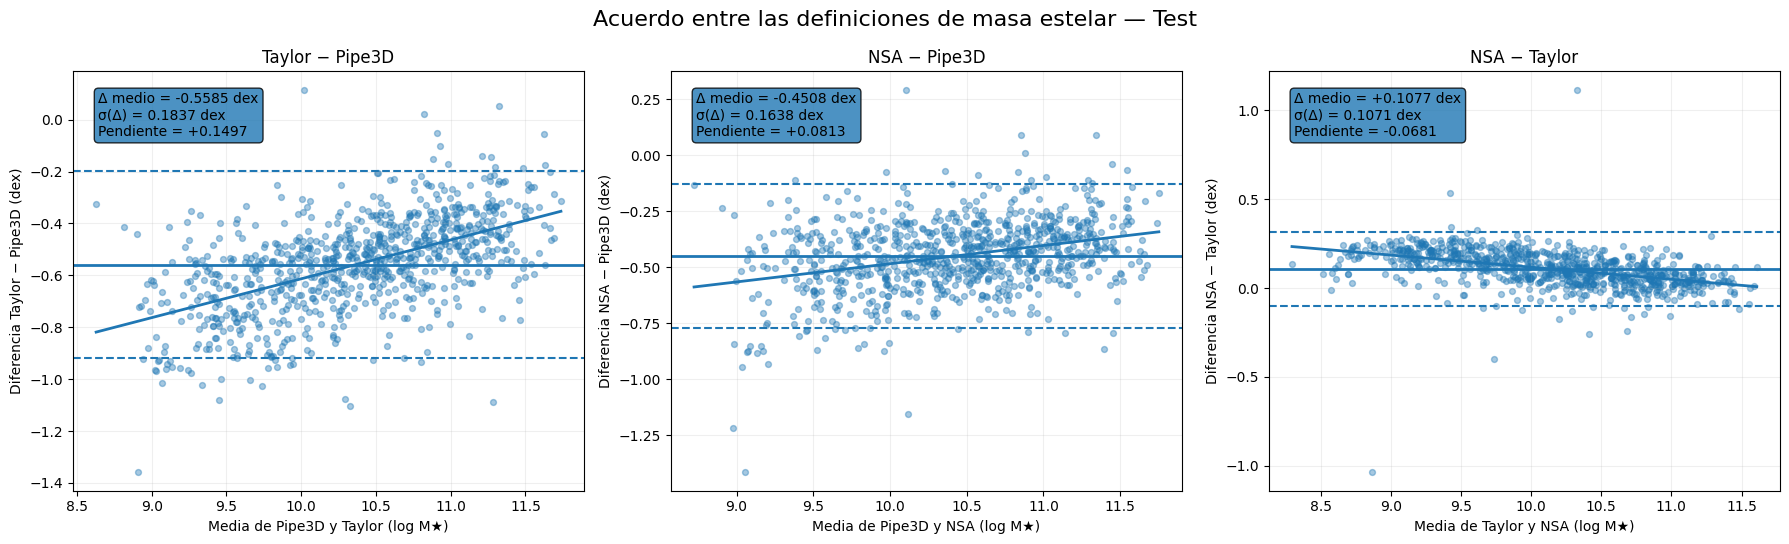


✓ Figura guardada en:
/content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_BlandAltman_masas.png


In [ ]:
# ============================================================
# CELDA 31 — BLAND-ALTMAN ENTRE DEFINICIONES DE MASA
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Definir comparaciones
# ------------------------------------------------------------

pares_bland_altman = [
    ("Pipe3D", "Taylor"),
    ("Pipe3D", "NSA"),
    ("Taylor", "NSA")
]


# ------------------------------------------------------------
# 2. Crear figura
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharey=False
)


for ax, (a, b) in zip(
    axes,
    pares_bland_altman
):

    valores_a = (
        masas_test[a]
        .to_numpy()
    )

    valores_b = (
        masas_test[b]
        .to_numpy()
    )


    # --------------------------------------------------------
    # Media y diferencia
    # --------------------------------------------------------

    media_par = (
        valores_a + valores_b
    ) / 2

    diferencia = (
        valores_b - valores_a
    )


    # --------------------------------------------------------
    # Estadísticos
    # --------------------------------------------------------

    diferencia_media = np.mean(
        diferencia
    )

    std_diferencia = np.std(
        diferencia,
        ddof=0
    )

    limite_superior = (
        diferencia_media
        + 1.96 * std_diferencia
    )

    limite_inferior = (
        diferencia_media
        - 1.96 * std_diferencia
    )


    # --------------------------------------------------------
    # Tendencia lineal
    # --------------------------------------------------------

    coef = np.polyfit(
        media_par,
        diferencia,
        1
    )

    x_fit = np.linspace(
        media_par.min(),
        media_par.max(),
        200
    )

    y_fit = (
        coef[0] * x_fit
        + coef[1]
    )


    # --------------------------------------------------------
    # Scatter
    # --------------------------------------------------------

    ax.scatter(
        media_par,
        diferencia,
        alpha=0.4,
        s=18
    )


    # Diferencia media
    ax.axhline(
        diferencia_media,
        linewidth=2,
        label="Diferencia media"
    )


    # Límites ±1.96 sigma
    ax.axhline(
        limite_superior,
        linestyle="--",
        linewidth=1.5
    )

    ax.axhline(
        limite_inferior,
        linestyle="--",
        linewidth=1.5
    )


    # Tendencia
    ax.plot(
        x_fit,
        y_fit,
        linewidth=2
    )


    # --------------------------------------------------------
    # Texto
    # --------------------------------------------------------

    texto = (
        f"Δ medio = {diferencia_media:+.4f} dex\n"
        f"σ(Δ) = {std_diferencia:.4f} dex\n"
        f"Pendiente = {coef[0]:+.4f}"
    )

    ax.text(
        0.05,
        0.95,
        texto,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.8
        )
    )


    ax.set_title(
        f"{b} − {a}"
    )

    ax.set_xlabel(
        f"Media de {a} y {b} (log M★)"
    )

    ax.set_ylabel(
        f"Diferencia {b} − {a} (dex)"
    )

    ax.grid(
        alpha=0.2
    )


fig.suptitle(
    "Acuerdo entre las definiciones de masa estelar — Test",
    fontsize=16
)

plt.tight_layout()


# ------------------------------------------------------------
# 3. Guardar figura
# ------------------------------------------------------------

ruta_fig_bland_altman = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_BlandAltman_masas.png"
)


plt.savefig(
    ruta_fig_bland_altman,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "\n✓ Figura guardada en:"
)

print(
    ruta_fig_bland_altman
)

Esta gráfica muestra algo muy importante: las diferencias entre las escalas de masa no son offsets constantes. También cambian con la masa.

En Taylor − Pipe3D la pendiente es +0.1497. Como la diferencia media es −0.5585 dex, Taylor suele dar masas menores que Pipe3D, pero esa separación se reduce hacia masas más altas. En NSA − Pipe3D ocurre algo similar pero más suave, con pendiente +0.0813. En cambio, NSA − Taylor tiene pendiente −0.0681: NSA suele estar por encima de Taylor en promedio (+0.1077 dex), pero esa diferencia tiende a disminuir conforme aumenta la masa.

Esto nos permite decir que las tres escalas están muy correlacionadas, pero no son equivalentes mediante una simple corrección aditiva. Hay un componente dependiente de la masa. Taylor y NSA siguen siendo las más consistentes entre sí, aunque incluso entre ellas aparece una pequeña tendencia sistemática.

## Etapa 32 — ¿Las mismas galaxias son difíciles para los tres modelos?

### ¿Qué se hará?

Se compararán galaxia por galaxia los residuos obtenidos por:

- Pipe3D;
- Taylor;
- NSA.

Las tres predicciones corresponden exactamente a las mismas 835 galaxias de Test.

Se estudiarán las relaciones:

- residuo Pipe3D vs. residuo Taylor;
- residuo Pipe3D vs. residuo NSA;
- residuo Taylor vs. residuo NSA.

### ¿Por qué se hace?

Los tres modelos reciben exactamente la misma imagen de cada galaxia.

Si una galaxia presenta un error grande y del mismo signo en varios modelos, podría indicar que existe alguna característica de la imagen que hace difícil inferir la masa independientemente de la definición utilizada.

Por el contrario, si los residuos de los modelos fueran poco correlacionados, una mayor parte del error podría estar asociada a diferencias particulares entre las etiquetas.

### ¿Cómo se interpretará?

Una correlación positiva alta entre residuos significa que los modelos tienden a equivocarse en las mismas galaxias y en la misma dirección.

Por ejemplo:

- residuo positivo en los tres modelos → los tres sobreestiman esa galaxia;
- residuo negativo en los tres → los tres la subestiman.

Una correlación baja indicaría errores más específicos de cada definición de masa.

También se utilizará la línea:

`residuo A = residuo B`

como referencia de errores idénticos.

### Importante

Este análisis no modifica ningún modelo.

Su objetivo es separar, de manera descriptiva, errores posiblemente comunes a la información de las imágenes de errores particulares de cada target.

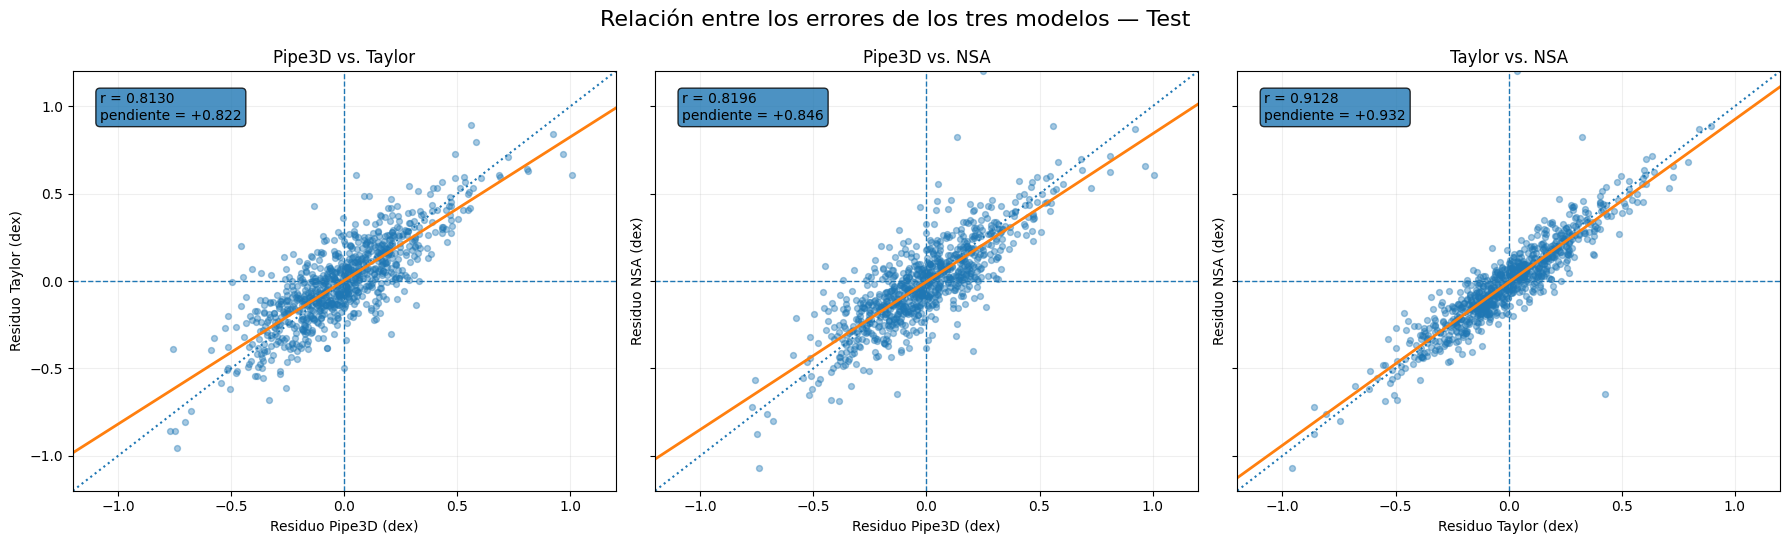


=== CORRELACIÓN ENTRE RESIDUOS ===


,comparacion,Pearson_residuos
0,Pipe3D vs Taylor,0.8130
1,Pipe3D vs NSA,0.8196
2,Taylor vs NSA,0.9128



✓ Comparación de residuos completada.


In [ ]:
# ============================================================
# CELDA 32 — CORRELACIÓN DE RESIDUOS ENTRE LOS TRES MODELOS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Construir tabla común de residuos
# ------------------------------------------------------------

residuos_comunes = pd.DataFrame(
    {
        "mangaid":
            pred_test_pipe3d["mangaid"].to_numpy(),

        "Pipe3D":
            pred_test_pipe3d["residuo"].to_numpy(),

        "Taylor":
            pred_test_taylor["residuo"].to_numpy(),

        "NSA":
            pred_test_nsa["residuo"].to_numpy()
    }
)


assert len(residuos_comunes) == 835


# ------------------------------------------------------------
# 2. Pares a comparar
# ------------------------------------------------------------

pares_residuos = [
    ("Pipe3D", "Taylor"),
    ("Pipe3D", "NSA"),
    ("Taylor", "NSA")
]


# ------------------------------------------------------------
# 3. Límites comunes
# ------------------------------------------------------------

todos_residuos = residuos_comunes[
    ["Pipe3D", "Taylor", "NSA"]
].to_numpy().ravel()

lim = np.ceil(
    np.max(np.abs(todos_residuos)) * 10
) / 10


# ------------------------------------------------------------
# 4. Crear figura
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharex=True,
    sharey=True
)


resumen_correlacion = []


for ax, (x_col, y_col) in zip(
    axes,
    pares_residuos
):

    x = residuos_comunes[
        x_col
    ].to_numpy()

    y = residuos_comunes[
        y_col
    ].to_numpy()


    # --------------------------------------------------------
    # Correlación
    # --------------------------------------------------------

    r = np.corrcoef(
        x,
        y
    )[0, 1]


    resumen_correlacion.append(
        {
            "comparacion":
                f"{x_col} vs {y_col}",

            "Pearson_residuos":
                r
        }
    )


    # --------------------------------------------------------
    # Scatter
    # --------------------------------------------------------

    ax.scatter(
        x,
        y,
        alpha=0.4,
        s=18
    )


    # Cero horizontal y vertical
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )


    # Línea y = x
    ax.plot(
        [-lim, lim],
        [-lim, lim],
        linestyle=":",
        linewidth=1.5
    )


    # Ajuste lineal descriptivo
    coef = np.polyfit(
        x,
        y,
        1
    )

    x_fit = np.linspace(
        -lim,
        lim,
        200
    )

    y_fit = (
        coef[0] * x_fit
        + coef[1]
    )

    ax.plot(
        x_fit,
        y_fit,
        linewidth=2
    )


    # --------------------------------------------------------
    # Texto
    # --------------------------------------------------------

    ax.text(
        0.05,
        0.95,
        (
            f"r = {r:.4f}\n"
            f"pendiente = {coef[0]:+.3f}"
        ),
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.8
        )
    )


    # --------------------------------------------------------
    # Formato
    # --------------------------------------------------------

    ax.set_title(
        f"{x_col} vs. {y_col}"
    )

    ax.set_xlabel(
        f"Residuo {x_col} (dex)"
    )

    ax.set_ylabel(
        f"Residuo {y_col} (dex)"
    )

    ax.set_xlim(
        -lim,
        lim
    )

    ax.set_ylim(
        -lim,
        lim
    )

    ax.grid(
        alpha=0.2
    )


fig.suptitle(
    "Relación entre los errores de los tres modelos — Test",
    fontsize=16
)

plt.tight_layout()


# ------------------------------------------------------------
# 5. Guardar figura
# ------------------------------------------------------------

ruta_fig_residuos_cruzados = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_correlacion_residuos_modelos.png"
)


plt.savefig(
    ruta_fig_residuos_cruzados,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# 6. Tabla resumen
# ------------------------------------------------------------

tabla_correlacion_residuos = pd.DataFrame(
    resumen_correlacion
)


print(
    "\n=== CORRELACIÓN ENTRE RESIDUOS ==="
)

display(
    tabla_correlacion_residuos.style.format(
        {
            "Pearson_residuos":
                "{:.4f}"
        }
    )
)


tabla_correlacion_residuos.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "correlacion_residuos_TEST.csv"
    ),
    index=False
)


print(
    "\n✓ Comparación de residuos completada."
)

Esta gráfica es muy importante porque muestra que los errores no son independientes entre los tres modelos.

Las correlaciones de residuos son altas:

Pipe3D–Taylor: r = 0.8130
Pipe3D–NSA: r = 0.8196
Taylor–NSA: r = 0.9128

La relación más fuerte vuelve a aparecer entre Taylor y NSA, igual que vimos al comparar directamente sus masas. Además, las pendientes son cercanas a 1 (0.822, 0.846, 0.932), especialmente Taylor–NSA. Esto significa que cuando una galaxia resulta sobreestimada o subestimada con un target, con frecuencia ocurre algo similar con los demás.

Eso sugiere que una parte importante del error está asociada a galaxias que son difíciles de inferir desde la imagen, y no exclusivamente a una definición particular de masa. Pero no podemos atribuirlo únicamente a la imagen: las tres etiquetas también están muy correlacionadas entre sí, por lo que pueden compartir estructura o sistemáticas.

## Etapa 33 — Relación entre desacuerdo de las etiquetas y dificultad de predicción

### ¿Qué se hará?

Para cada una de las 835 galaxias de Test se calcularán dos cantidades.

Primero, el desacuerdo entre las tres estimaciones de masa estelar. Se utilizará como medida:

`rango de masas = masa máxima - masa mínima`

entre Pipe3D, Taylor y NSA.

Segundo, se calculará el error absoluto medio de las tres redes:

`error CNN medio = promedio(|residuo Pipe3D|, |residuo Taylor|, |residuo NSA|)`

Posteriormente se estudiará la relación entre ambas cantidades.

### ¿Por qué se hace?

Las gráficas anteriores mostraron dos resultados importantes:

- las tres etiquetas de masa están fuertemente correlacionadas, pero no son equivalentes;
- los residuos de los tres modelos también están fuertemente correlacionados.

Una posible explicación es que algunas galaxias sean intrínsecamente más ambiguas: distintos métodos de estimación de masa discrepan más entre sí y, al mismo tiempo, sus masas son más difíciles de inferir únicamente a partir de la imagen.

### ¿Cómo se interpretará?

Si existe una correlación positiva:

- mayor desacuerdo entre Pipe3D, Taylor y NSA;
- mayor error de las CNN.

Esto sugeriría que parte de la dificultad predictiva está asociada a galaxias para las cuales la propia definición de masa es menos consistente entre catálogos.

Si la correlación es cercana a cero, el desacuerdo entre métodos de masa y el error de predicción de las imágenes serían fenómenos relativamente independientes.

Se calcularán tanto Pearson como Spearman.

Spearman es especialmente útil porque permite detectar una relación monotónica sin exigir que sea perfectamente lineal.

### Importante

Este análisis es descriptivo y no permite establecer causalidad.

Los modelos permanecen congelados y Test no se utiliza para realizar ningún ajuste.

=== DESACUERDO DE MASAS VS ERROR CNN ===
Pearson r = 0.0388
Pearson p = 2.626e-01
Spearman ρ = 0.0336
Spearman p = 3.325e-01


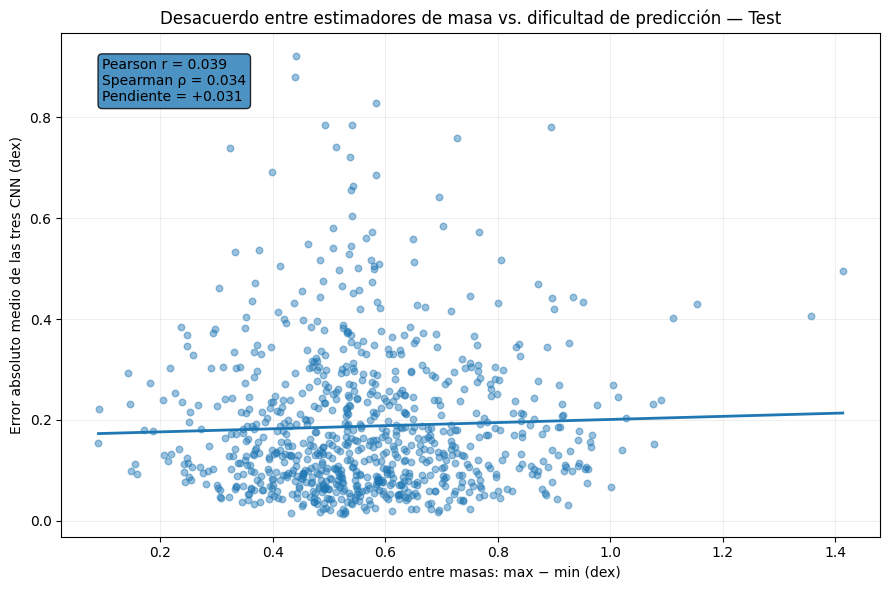


✓ Análisis de dificultad completado.
✓ Figura guardada en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_desacuerdo_masas_vs_error_CNN.png


In [ ]:
# ============================================================
# CELDA 33 — DESACUERDO DE MASAS VS DIFICULTAD DE PREDICCIÓN
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    pearsonr,
    spearmanr
)


# ------------------------------------------------------------
# 1. Construir tabla común
# ------------------------------------------------------------

analisis_dificultad = pd.DataFrame(
    {
        "mangaid":
            pred_test_pipe3d["mangaid"].to_numpy(),

        "masa_pipe3d":
            pred_test_pipe3d["real"].to_numpy(),

        "masa_taylor":
            pred_test_taylor["real"].to_numpy(),

        "masa_nsa":
            pred_test_nsa["real"].to_numpy(),

        "res_pipe3d":
            pred_test_pipe3d["residuo"].to_numpy(),

        "res_taylor":
            pred_test_taylor["residuo"].to_numpy(),

        "res_nsa":
            pred_test_nsa["residuo"].to_numpy()
    }
)


assert len(analisis_dificultad) == 835


# ------------------------------------------------------------
# 2. Medida de desacuerdo entre las tres masas
# ------------------------------------------------------------

matriz_masas = analisis_dificultad[
    [
        "masa_pipe3d",
        "masa_taylor",
        "masa_nsa"
    ]
].to_numpy()


analisis_dificultad[
    "rango_masas"
] = (
    matriz_masas.max(axis=1)
    - matriz_masas.min(axis=1)
)


# ------------------------------------------------------------
# 3. Error absoluto medio de los tres modelos
# ------------------------------------------------------------

analisis_dificultad[
    "error_abs_medio"
] = np.mean(
    np.abs(
        analisis_dificultad[
            [
                "res_pipe3d",
                "res_taylor",
                "res_nsa"
            ]
        ].to_numpy()
    ),
    axis=1
)


# ------------------------------------------------------------
# 4. Correlaciones
# ------------------------------------------------------------

pearson_r, pearson_p = pearsonr(
    analisis_dificultad["rango_masas"],
    analisis_dificultad["error_abs_medio"]
)

spearman_rho, spearman_p = spearmanr(
    analisis_dificultad["rango_masas"],
    analisis_dificultad["error_abs_medio"]
)


print("=== DESACUERDO DE MASAS VS ERROR CNN ===")

print(
    f"Pearson r = {pearson_r:.4f}"
)

print(
    f"Pearson p = {pearson_p:.3e}"
)

print(
    f"Spearman ρ = {spearman_rho:.4f}"
)

print(
    f"Spearman p = {spearman_p:.3e}"
)


# ------------------------------------------------------------
# 5. Ajuste lineal descriptivo
# ------------------------------------------------------------

x = (
    analisis_dificultad[
        "rango_masas"
    ].to_numpy()
)

y = (
    analisis_dificultad[
        "error_abs_medio"
    ].to_numpy()
)


coef = np.polyfit(
    x,
    y,
    1
)

x_fit = np.linspace(
    x.min(),
    x.max(),
    200
)

y_fit = (
    coef[0] * x_fit
    + coef[1]
)


# ------------------------------------------------------------
# 6. Gráfica
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


plt.scatter(
    x,
    y,
    alpha=0.45,
    s=22
)


plt.plot(
    x_fit,
    y_fit,
    linewidth=2
)


plt.xlabel(
    "Desacuerdo entre masas: max − min (dex)"
)

plt.ylabel(
    "Error absoluto medio de las tres CNN (dex)"
)

plt.title(
    "Desacuerdo entre estimadores de masa vs. dificultad de predicción — Test"
)


texto = (
    f"Pearson r = {pearson_r:.3f}\n"
    f"Spearman ρ = {spearman_rho:.3f}\n"
    f"Pendiente = {coef[0]:+.3f}"
)


plt.text(
    0.05,
    0.95,
    texto,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)


plt.grid(
    alpha=0.2
)

plt.tight_layout()


# ------------------------------------------------------------
# 7. Guardar
# ------------------------------------------------------------

ruta_fig_dificultad = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_desacuerdo_masas_vs_error_CNN.png"
)


plt.savefig(
    ruta_fig_dificultad,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


analisis_dificultad.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "analisis_dificultad_galaxias_TEST.csv"
    ),
    index=False
)


print(
    "\n✓ Análisis de dificultad completado."
)

print(
    "✓ Figura guardada en:",
    ruta_fig_dificultad
)

Este resultado es importante porque la hipótesis no se sostiene.

La relación entre el desacuerdo de las tres masas y el error de las CNN es prácticamente nula:

$$ r_{\text{Pearson}}=0.0388,\qquad p=0.263 $$ $$ \rho_{\text{Spearman}}=0.0336,\qquad p=0.333 $$

Ambos coeficientes están muy cerca de cero y ambos valores \(p>0.05\). Por tanto, las galaxias donde Pipe3D, Taylor y NSA discrepan más no son necesariamente las galaxias que la CNN predice peor. La pendiente +0.031 también es muy pequeña.

Eso complementa muy bien el resultado anterior: los errores de las tres CNN sí están fuertemente correlacionados entre sí, pero

## Etapa 34 — Inspección visual de las galaxias más difíciles de Test

### ¿Qué se hará?

Se identificarán las galaxias con mayor error absoluto medio entre los tres modelos.

Para cada galaxia se calculará:

`error medio = promedio(|error Pipe3D|, |error Taylor|, |error NSA|)`

Posteriormente se mostrarán las imágenes de las 12 galaxias con mayor error.

### ¿Por qué se hace?

Los residuos de Pipe3D, Taylor y NSA están fuertemente correlacionados, lo que indica que varias galaxias son difíciles para los tres modelos simultáneamente.

Sin embargo, el desacuerdo entre las tres etiquetas de masa no explicó esa dificultad.

Por ello, el siguiente paso es inspeccionar visualmente esos casos para buscar posibles características comunes, por ejemplo:

- baja resolución o bajo contraste;
- objetos pequeños;
- estructuras irregulares;
- contaminación por fuentes cercanas;
- orientación particular;
- morfologías poco comunes.

### ¿Qué se mostrará?

Para cada galaxia se incluirá:

- `mangaid`;
- error absoluto Pipe3D;
- error absoluto Taylor;
- error absoluto NSA;
- error absoluto medio.

Este análisis será únicamente descriptivo.

No se eliminarán galaxias ni se modificarán los modelos a partir de esta inspección.

=== 12 GALAXIAS MÁS DIFÍCILES ===


,mangaid,error_pipe3d,error_taylor,error_nsa,error_medio
0,1-97033,0.739,0.956,1.070,0.922
1,1-90984,0.924,0.844,0.873,0.880
2,12-84674,0.750,0.860,0.877,0.829
3,1-73667,0.770,0.859,0.723,0.784
4,1-72128,0.967,0.729,0.657,0.784
5,1-78013,0.561,0.894,0.885,0.780
6,1-71976,0.705,0.807,0.763,0.758
7,1-641156,0.679,0.747,0.801,0.742
8,1-78636,1.007,0.605,0.605,0.739
9,1-96474,0.812,0.632,0.718,0.721


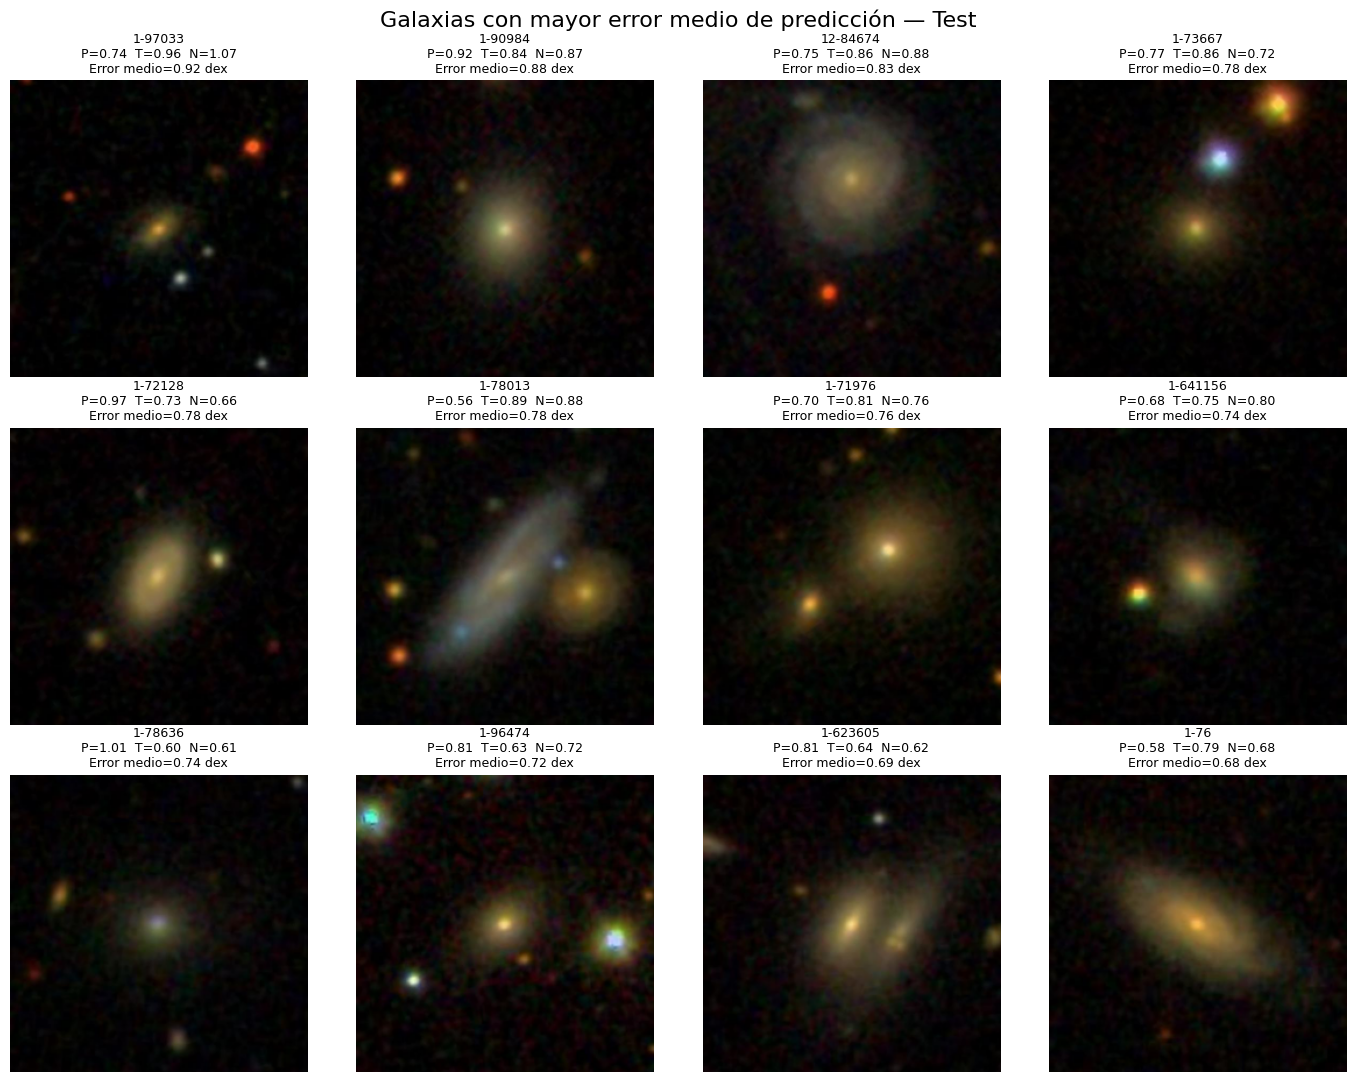


✓ Casos difíciles identificados.
✓ Figura guardada en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_12_galaxias_mas_dificiles.png


In [ ]:
# ============================================================
# CELDA 34 — GALAXIAS MÁS DIFÍCILES PARA LOS TRES MODELOS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Construir tabla de errores por galaxia
# ------------------------------------------------------------

casos_dificiles = pd.DataFrame(
    {
        "mangaid":
            pred_test_pipe3d["mangaid"].to_numpy(),

        "error_pipe3d":
            np.abs(
                pred_test_pipe3d["residuo"].to_numpy()
            ),

        "error_taylor":
            np.abs(
                pred_test_taylor["residuo"].to_numpy()
            ),

        "error_nsa":
            np.abs(
                pred_test_nsa["residuo"].to_numpy()
            )
    }
)


# ------------------------------------------------------------
# 2. Error absoluto medio
# ------------------------------------------------------------

casos_dificiles[
    "error_medio"
] = casos_dificiles[
    [
        "error_pipe3d",
        "error_taylor",
        "error_nsa"
    ]
].mean(
    axis=1
)


# ------------------------------------------------------------
# 3. Ordenar de mayor a menor dificultad
# ------------------------------------------------------------

casos_dificiles = (
    casos_dificiles
    .sort_values(
        "error_medio",
        ascending=False
    )
    .reset_index(drop=True)
)


top_dificiles = (
    casos_dificiles
    .head(12)
    .copy()
)


print(
    "=== 12 GALAXIAS MÁS DIFÍCILES ==="
)

display(
    top_dificiles.style.format(
        {
            "error_pipe3d": "{:.3f}",
            "error_taylor": "{:.3f}",
            "error_nsa": "{:.3f}",
            "error_medio": "{:.3f}"
        }
    )
)


# ------------------------------------------------------------
# 4. Mostrar imágenes
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 11)
)

axes = axes.ravel()


for ax, (_, fila) in zip(
    axes,
    top_dificiles.iterrows()
):

    mangaid = fila["mangaid"]

    imagen = image_map[
        mangaid
    ]

    ax.imshow(
        imagen
    )

    titulo = (
        f"{mangaid}\n"
        f"P={fila['error_pipe3d']:.2f}  "
        f"T={fila['error_taylor']:.2f}  "
        f"N={fila['error_nsa']:.2f}\n"
        f"Error medio={fila['error_medio']:.2f} dex"
    )

    ax.set_title(
        titulo,
        fontsize=9
    )

    ax.axis(
        "off"
    )


fig.suptitle(
    "Galaxias con mayor error medio de predicción — Test",
    fontsize=16
)

plt.tight_layout()


# ------------------------------------------------------------
# 5. Guardar figura
# ------------------------------------------------------------

ruta_fig_casos_dificiles = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_12_galaxias_mas_dificiles.png"
)


plt.savefig(
    ruta_fig_casos_dificiles,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. Guardar tabla
# ------------------------------------------------------------

top_dificiles.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "12_galaxias_mas_dificiles_TEST.csv"
    ),
    index=False
)


print(
    "\n✓ Casos difíciles identificados."
)

print(
    "✓ Figura guardada en:",
    ruta_fig_casos_dificiles
)

## Etapa 35 — Relación entre morfología y dificultad de predicción

### ¿Qué se hará?

Se estudiará si el error de predicción de masa estelar está relacionado con propiedades morfológicas de las galaxias.

El catálogo original de Katachi contiene variables como:

- `spirals`
- `edge_on`
- `irregular_features`
- `smooth`
- `bulge`
- `p_merger`
- `sersic_n`

Estas propiedades se asociarán mediante `mangaid` a las mismas 835 galaxias de Test.

### ¿Por qué se hace?

La inspección visual de las galaxias con mayor error mostró una mezcla de:

- objetos difusos;
- galaxias elongadas;
- posibles sistemas con fuentes cercanas;
- galaxias relativamente compactas.

Por lo tanto, no existe visualmente una única morfología que explique todos los casos difíciles.

El siguiente paso es comprobar cuantitativamente si alguna propiedad morfológica presenta una relación sistemática con el error de las CNN.

### Medida de dificultad

Se utilizará nuevamente:

`error absoluto medio`

definido como el promedio de los errores absolutos de Pipe3D, Taylor y NSA para cada galaxia.

### ¿Cómo se analizará?

Para cada propiedad se calculará la correlación de Spearman con el error absoluto medio.

Spearman permite identificar relaciones monotónicas sin asumir que la relación sea lineal.

El objetivo de esta etapa es exploratorio y descriptivo.

No se utilizarán estas variables como nuevas entradas del modelo y no se modificarán los resultados finales.

=== VARIABLES MORFOLÓGICAS DISPONIBLES ===
sersic_n -> True
spirals -> True
edge_on -> True
irregular_features -> True
smooth -> True
bulge -> True
p_merger -> True

Galaxias analizadas: 835

=== MORFOLOGÍA VS ERROR ABSOLUTO MEDIO ===


,variable,N,Spearman_rho,p_value,abs_rho
0,p_merger,72,+0.1843,1.211e-01,0.1843
1,sersic_n,835,+0.1376,6.650e-05,0.1376
2,smooth,807,-0.1313,1.839e-04,0.1313
3,edge_on,807,+0.0434,2.183e-01,0.0434
4,spirals,807,-0.0427,2.256e-01,0.0427
5,irregular_features,807,-0.0426,2.267e-01,0.0426
6,bulge,807,-0.0272,4.407e-01,0.0272


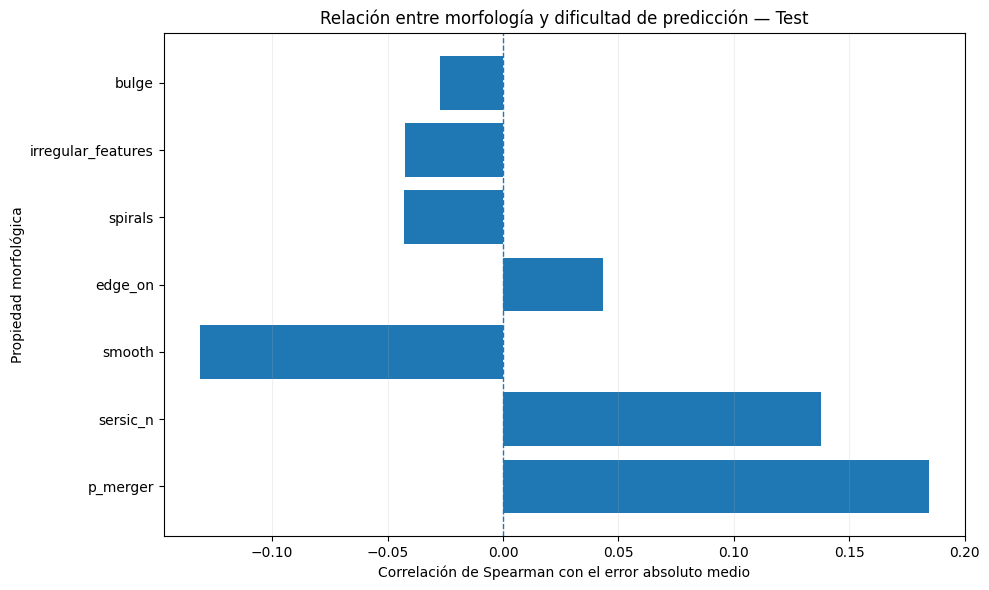


✓ Análisis morfológico completado.
✓ Figura guardada en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_morfologia_vs_error.png


In [ ]:
# ============================================================
# CELDA 35 — MORFOLOGÍA VS DIFICULTAD DE PREDICCIÓN
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


# ------------------------------------------------------------
# 1. Seleccionar propiedades morfológicas disponibles
# ------------------------------------------------------------

columnas_morfologia = [
    "sersic_n",
    "spirals",
    "edge_on",
    "irregular_features",
    "smooth",
    "bulge",
    "p_merger"
]


print("=== VARIABLES MORFOLÓGICAS DISPONIBLES ===")

for col in columnas_morfologia:

    print(
        col,
        "->",
        col in scalars.columns
    )


# ------------------------------------------------------------
# 2. Extraer información morfológica
# ------------------------------------------------------------

morfologia = scalars[
    [
        "mangaid"
    ] + columnas_morfologia
].copy()


morfologia["mangaid"] = (
    morfologia["mangaid"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 3. Asociar con las 835 galaxias de Test
# ------------------------------------------------------------

analisis_morfologia = (
    analisis_dificultad
    .merge(
        morfologia,
        on="mangaid",
        how="left",
        validate="one_to_one"
    )
)


print(
    "\nGalaxias analizadas:",
    len(analisis_morfologia)
)


# ------------------------------------------------------------
# 4. Calcular Spearman para cada propiedad
# ------------------------------------------------------------

resultados_morfologia = []


for col in columnas_morfologia:

    datos = analisis_morfologia[
        [
            col,
            "error_abs_medio"
        ]
    ].dropna()


    if len(datos) < 3:

        continue


    rho, p = spearmanr(
        datos[col],
        datos["error_abs_medio"]
    )


    resultados_morfologia.append(
        {
            "variable": col,
            "N": len(datos),
            "Spearman_rho": rho,
            "p_value": p
        }
    )


tabla_morfologia = pd.DataFrame(
    resultados_morfologia
)


tabla_morfologia[
    "abs_rho"
] = np.abs(
    tabla_morfologia["Spearman_rho"]
)


tabla_morfologia = (
    tabla_morfologia
    .sort_values(
        "abs_rho",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\n=== MORFOLOGÍA VS ERROR ABSOLUTO MEDIO ==="
)

display(
    tabla_morfologia.style.format(
        {
            "Spearman_rho": "{:+.4f}",
            "abs_rho": "{:.4f}",
            "p_value": "{:.3e}"
        }
    )
)


# ------------------------------------------------------------
# 5. Gráfica resumen
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.barh(
    tabla_morfologia["variable"],
    tabla_morfologia["Spearman_rho"]
)


plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    "Correlación de Spearman con el error absoluto medio"
)

plt.ylabel(
    "Propiedad morfológica"
)

plt.title(
    "Relación entre morfología y dificultad de predicción — Test"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()


# ------------------------------------------------------------
# 6. Guardar
# ------------------------------------------------------------

ruta_fig_morfologia = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_morfologia_vs_error.png"
)


plt.savefig(
    ruta_fig_morfologia,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


tabla_morfologia.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "morfologia_vs_error_TEST.csv"
    ),
    index=False
)


print(
    "\n✓ Análisis morfológico completado."
)

print(
    "✓ Figura guardada en:",
    ruta_fig_morfologia
)

Aquí ya tenemos una conclusión bastante limpia: la morfología, por sí sola, explica muy poco de la dificultad de predicción.

p_merger tiene la correlación más alta, \(\rho=+0.1843\), pero solo hay 72 galaxias con ese dato y \(p=0.121\), así que no tenemos evidencia suficiente para afirmar una asociación. sersic_n sí muestra una relación positiva estadísticamente detectable (\(\rho=+0.1376,\ p=6.65\times10^{-5}\)), pero el tamaño del efecto es débil: galaxias con mayor concentración de Sérsic tienden a ser ligeramente más difíciles. smooth muestra una asociación débil en sentido contrario (\(\rho=-0.1313\)), mientras que edge_on, spirals, irregular_features y bulge están prácticamente cerca de cero.

Es importante distinguir significancia estadística de importancia práctica: con \(N\approx800\), correlaciones pequeñas pueden tener valores \(p\) bajos. Aquí ninguna propiedad alcanza siquiera \(|\rho|=0.20\). Por eso no diríamos que la morfología explica los errores; como mucho, encontramos asociaciones débiles con sersic_n y smooth.

## Etapa 36 — Relación entre redshift y dificultad de predicción

### ¿Qué se hará?

Se estudiará si el error de predicción aumenta con el redshift de la galaxia.

Para las mismas 835 galaxias de Test se relacionará el redshift con:

- error absoluto Pipe3D;
- error absoluto Taylor;
- error absoluto NSA;
- error absoluto medio de los tres modelos.

### ¿Por qué se hace?

Las imágenes utilizadas por las redes tienen el mismo tamaño en píxeles, pero las galaxias se encuentran a diferentes distancias.

Una galaxia con mayor redshift puede:

- ocupar menos píxeles;
- mostrar menos detalle estructural;
- presentar menor relación señal-ruido;
- hacer más difícil recuperar información relacionada con la masa estelar.

Por ello, el redshift podría explicar parte de la dificultad compartida que observamos entre los tres modelos.

### ¿Cómo se analizará?

Se calcularán correlaciones de Spearman entre redshift y error absoluto.

También se dividirá Test en intervalos de redshift y se calculará el error medio dentro de cada intervalo.

### Interpretación

Una correlación positiva indicaría que las galaxias más lejanas tienden a presentar mayores errores.

Una correlación cercana a cero indicaría que, dentro del rango de redshift de esta muestra, la distancia no constituye una fuente importante de dificultad para los modelos.

Este análisis es únicamente diagnóstico.

Los modelos permanecen congelados.

=== COBERTURA REDSHIFT ===
Galaxias: 835
Redshift faltante: 0

=== REDSHIFT VS ERROR ABSOLUTO ===


,modelo,N,Spearman_rho,p_value
0,Pipe3D,835,-0.0065,8.510e-01
1,Taylor,835,+0.0044,8.988e-01
2,NSA,835,+0.0291,4.007e-01
3,Promedio,835,+0.0145,6.757e-01


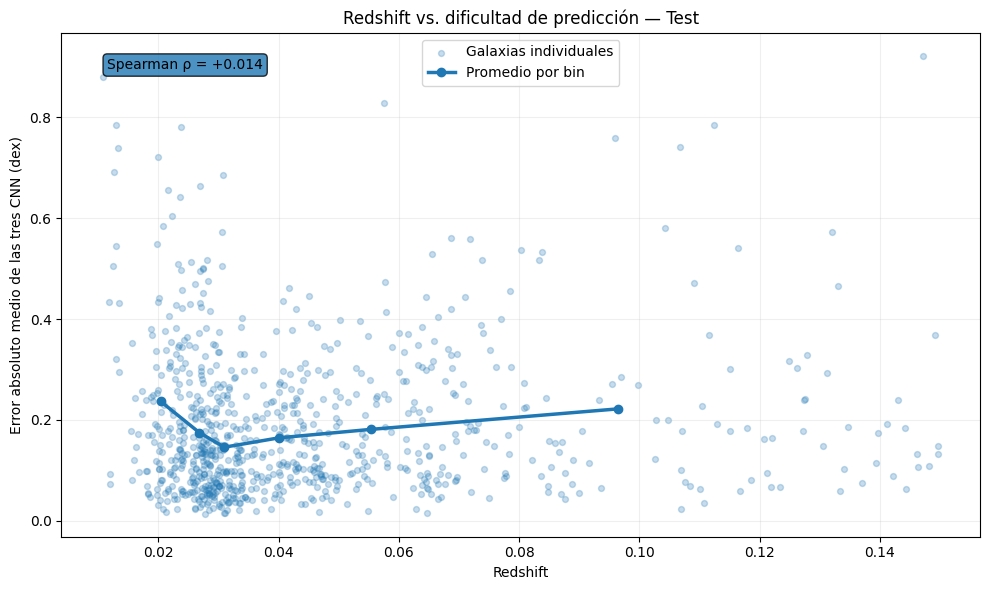


✓ Análisis de redshift completado.
✓ Figura guardada en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_redshift_vs_error.png


In [ ]:
# ============================================================
# CELDA 36 — REDSHIFT VS DIFICULTAD DE PREDICCIÓN
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


# ------------------------------------------------------------
# 1. Extraer redshift del catálogo Katachi
# ------------------------------------------------------------

tabla_redshift = scalars[
    [
        "mangaid",
        "redshift"
    ]
].copy()

tabla_redshift["mangaid"] = (
    tabla_redshift["mangaid"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 2. Construir tabla de análisis
# ------------------------------------------------------------

analisis_redshift = pd.DataFrame(
    {
        "mangaid":
            pred_test_pipe3d["mangaid"].to_numpy(),

        "error_pipe3d":
            np.abs(
                pred_test_pipe3d["residuo"].to_numpy()
            ),

        "error_taylor":
            np.abs(
                pred_test_taylor["residuo"].to_numpy()
            ),

        "error_nsa":
            np.abs(
                pred_test_nsa["residuo"].to_numpy()
            )
    }
)


analisis_redshift[
    "error_medio"
] = analisis_redshift[
    [
        "error_pipe3d",
        "error_taylor",
        "error_nsa"
    ]
].mean(axis=1)


analisis_redshift = (
    analisis_redshift
    .merge(
        tabla_redshift,
        on="mangaid",
        how="left",
        validate="one_to_one"
    )
)


print("=== COBERTURA REDSHIFT ===")

print(
    "Galaxias:",
    len(analisis_redshift)
)

print(
    "Redshift faltante:",
    analisis_redshift["redshift"]
    .isna()
    .sum()
)


# ------------------------------------------------------------
# 3. Correlaciones de Spearman
# ------------------------------------------------------------

columnas_error = {
    "Pipe3D": "error_pipe3d",
    "Taylor": "error_taylor",
    "NSA": "error_nsa",
    "Promedio": "error_medio"
}


resultados_redshift = []


for nombre, col_error in columnas_error.items():

    datos = analisis_redshift[
        [
            "redshift",
            col_error
        ]
    ].dropna()

    rho, p = spearmanr(
        datos["redshift"],
        datos[col_error]
    )

    resultados_redshift.append(
        {
            "modelo": nombre,
            "N": len(datos),
            "Spearman_rho": rho,
            "p_value": p
        }
    )


tabla_redshift_error = pd.DataFrame(
    resultados_redshift
)


print(
    "\n=== REDSHIFT VS ERROR ABSOLUTO ==="
)

display(
    tabla_redshift_error.style.format(
        {
            "Spearman_rho": "{:+.4f}",
            "p_value": "{:.3e}"
        }
    )
)


# ------------------------------------------------------------
# 4. Crear bins de redshift para visualización
# ------------------------------------------------------------

analisis_redshift[
    "bin_redshift"
] = pd.qcut(
    analisis_redshift["redshift"],
    q=6,
    duplicates="drop"
)


resumen_bins = (
    analisis_redshift
    .groupby(
        "bin_redshift",
        observed=True
    )
    .agg(
        redshift_medio=(
            "redshift",
            "mean"
        ),

        error_pipe3d=(
            "error_pipe3d",
            "mean"
        ),

        error_taylor=(
            "error_taylor",
            "mean"
        ),

        error_nsa=(
            "error_nsa",
            "mean"
        ),

        error_medio=(
            "error_medio",
            "mean"
        ),

        N=(
            "mangaid",
            "size"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 5. Gráfica
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.scatter(
    analisis_redshift["redshift"],
    analisis_redshift["error_medio"],
    alpha=0.25,
    s=18,
    label="Galaxias individuales"
)


plt.plot(
    resumen_bins["redshift_medio"],
    resumen_bins["error_medio"],
    marker="o",
    linewidth=2.5,
    label="Promedio por bin"
)


rho_prom = tabla_redshift_error.loc[
    tabla_redshift_error["modelo"] == "Promedio",
    "Spearman_rho"
].iloc[0]


plt.xlabel(
    "Redshift"
)

plt.ylabel(
    "Error absoluto medio de las tres CNN (dex)"
)

plt.title(
    "Redshift vs. dificultad de predicción — Test"
)


plt.text(
    0.05,
    0.95,
    f"Spearman ρ = {rho_prom:+.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)


plt.grid(
    alpha=0.2
)

plt.legend()

plt.tight_layout()


# ------------------------------------------------------------
# 6. Guardar resultados
# ------------------------------------------------------------

ruta_fig_redshift = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_redshift_vs_error.png"
)


plt.savefig(
    ruta_fig_redshift,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


tabla_redshift_error.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "redshift_vs_error_TEST.csv"
    ),
    index=False
)


resumen_bins.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "redshift_bins_error_TEST.csv"
    ),
    index=False
)


print(
    "\n✓ Análisis de redshift completado."
)

print(
    "✓ Figura guardada en:",
    ruta_fig_redshift
)

Las correlaciones de Spearman son prácticamente nulas y no significativas:

Pipe3D: \(\rho=-0.0065\), \(p=0.851\)
Taylor: \(\rho=+0.0044\), \(p=0.899\)
NSA: \(\rho=+0.0291\), \(p=0.401\)
Promedio: \(\rho=+0.0145\), \(p=0.676\)
Interpretación

Esto significa que, dentro del rango de redshift de esta muestra, las galaxias más lejanas no están siendo sistemáticamente más difíciles para las CNN.

O sea:

no vemos evidencia de que el error aumente de forma monotónica con la distancia;
la dificultad compartida entre los tres modelos no parece venir de la resolución aparente asociada al redshift;
la ligera forma de la curva por bins en la gráfica no debe sobreinterpretarse, porque el análisis global da una asociación esencialmente nula.
Conclusión acumulada hasta aquí

Ya podemos decir varias cosas bastante sólidas:

Los tres modelos tienen desempeños absolutos muy parecidos.
Taylor destaca en métricas relativas (\(R^2\), RMSE/std), en parte porque su target tiene mayor dispersión.
Las tres etiquetas de masa están muy correlacionadas, pero no son equivalentes.
Los errores de las tres CNN también están fuertemente correlacionados, así que hay galaxias difíciles para todos.
Esa dificultad compartida no se explica ni por:
el desacuerdo entre etiquetas,
ni por el redshift,
ni de forma fuerte por una sola variable morfológica.

## Etapa 37 — Relación entre color g-i y dificultad de predicción

### ¿Qué se hará?

Se estudiará si el error de predicción de masa estelar está relacionado con el color `g_i` de la galaxia.

Se analizará la relación entre `g_i` y:

- error absoluto Pipe3D;
- error absoluto Taylor;
- error absoluto NSA;
- error absoluto medio de los tres modelos.

### ¿Por qué se hace?

El color `g_i` contiene información astrofísica relevante sobre las galaxias, por ejemplo:

- edad de la población estelar;
- contenido de polvo;
- tipo de galaxia;
- historia de formación estelar.

Es posible que ciertas galaxias muy azules o muy rojas sean más difíciles de predecir desde la imagen.

### ¿Cómo se analizará?

Se calcularán correlaciones de Spearman entre `g_i` y el error absoluto.

También se construirá una gráfica de dispersión con promedios por bins.

### Interpretación

Una correlación positiva indicaría que galaxias con mayor `g_i` tienden a ser más difíciles.

Una correlación negativa indicaría que galaxias con menor `g_i` tienden a ser más difíciles.

Una correlación cercana a cero indicaría que el color no explica de forma importante la dificultad de predicción.

Este análisis es exploratorio y no modifica los modelos.

=== COBERTURA COLOR g-i ===
Galaxias: 835
g_i faltante: 0

=== COLOR g-i VS ERROR ABSOLUTO ===


,modelo,N,Spearman_rho,p_value
0,Pipe3D,835,+0.0025,9.422e-01
1,Taylor,835,+0.0593,8.698e-02
2,NSA,835,+0.0238,4.929e-01
3,Promedio,835,+0.0215,5.341e-01


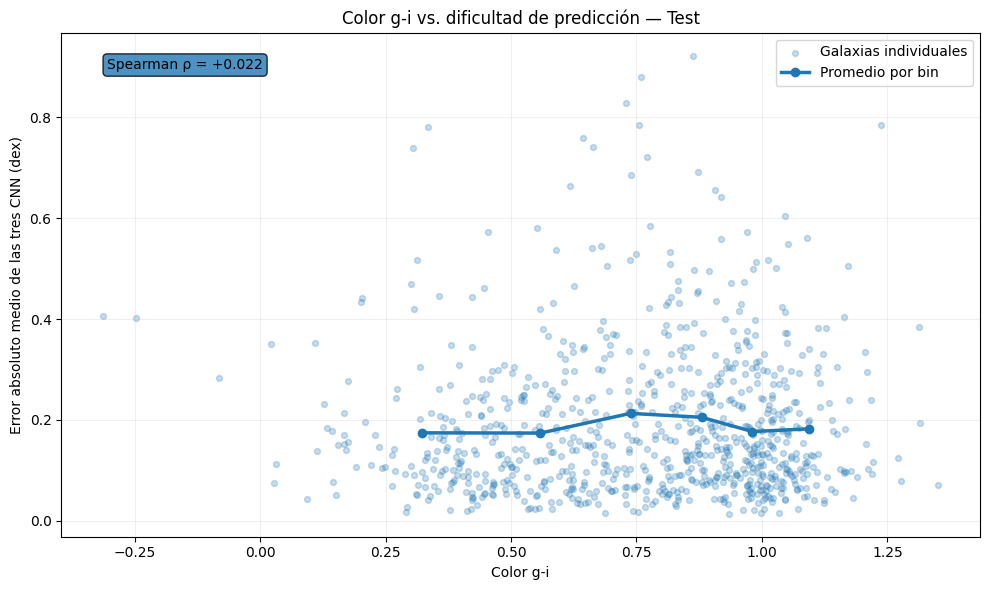


✓ Análisis de color completado.
✓ Figura guardada en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_color_gi_vs_error.png


In [ ]:
# ============================================================
# CELDA 37 — COLOR g_i VS DIFICULTAD DE PREDICCIÓN
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


# ------------------------------------------------------------
# 1. Preparar tabla de color
# ------------------------------------------------------------

tabla_color = color_morp.rename(
    columns={"MANGAID": "mangaid"}
)[["mangaid", "g_i"]].copy()

tabla_color["mangaid"] = (
    tabla_color["mangaid"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 2. Construir tabla base con errores
# ------------------------------------------------------------

analisis_color = pd.DataFrame(
    {
        "mangaid": pred_test_pipe3d["mangaid"].to_numpy(),
        "error_pipe3d": np.abs(pred_test_pipe3d["residuo"].to_numpy()),
        "error_taylor": np.abs(pred_test_taylor["residuo"].to_numpy()),
        "error_nsa": np.abs(pred_test_nsa["residuo"].to_numpy())
    }
)

analisis_color["error_medio"] = analisis_color[
    ["error_pipe3d", "error_taylor", "error_nsa"]
].mean(axis=1)

analisis_color = analisis_color.merge(
    tabla_color,
    on="mangaid",
    how="left",
    validate="one_to_one"
)

print("=== COBERTURA COLOR g-i ===")
print("Galaxias:", len(analisis_color))
print("g_i faltante:", analisis_color["g_i"].isna().sum())


# ------------------------------------------------------------
# 3. Correlaciones de Spearman
# ------------------------------------------------------------

columnas_error = {
    "Pipe3D": "error_pipe3d",
    "Taylor": "error_taylor",
    "NSA": "error_nsa",
    "Promedio": "error_medio"
}

resultados_color = []

for nombre, col_error in columnas_error.items():

    datos = analisis_color[["g_i", col_error]].dropna()

    rho, p = spearmanr(
        datos["g_i"],
        datos[col_error]
    )

    resultados_color.append(
        {
            "modelo": nombre,
            "N": len(datos),
            "Spearman_rho": rho,
            "p_value": p
        }
    )

tabla_color_error = pd.DataFrame(resultados_color)

print("\n=== COLOR g-i VS ERROR ABSOLUTO ===")
display(
    tabla_color_error.style.format(
        {
            "Spearman_rho": "{:+.4f}",
            "p_value": "{:.3e}"
        }
    )
)


# ------------------------------------------------------------
# 4. Bins para visualización
# ------------------------------------------------------------

analisis_color["bin_g_i"] = pd.qcut(
    analisis_color["g_i"],
    q=6,
    duplicates="drop"
)

resumen_bins_color = (
    analisis_color
    .groupby("bin_g_i", observed=True)
    .agg(
        g_i_medio=("g_i", "mean"),
        error_medio=("error_medio", "mean"),
        N=("mangaid", "size")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 5. Gráfica
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    analisis_color["g_i"],
    analisis_color["error_medio"],
    alpha=0.25,
    s=18,
    label="Galaxias individuales"
)

plt.plot(
    resumen_bins_color["g_i_medio"],
    resumen_bins_color["error_medio"],
    marker="o",
    linewidth=2.5,
    label="Promedio por bin"
)

rho_prom = tabla_color_error.loc[
    tabla_color_error["modelo"] == "Promedio",
    "Spearman_rho"
].iloc[0]

plt.xlabel("Color g-i")
plt.ylabel("Error absoluto medio de las tres CNN (dex)")
plt.title("Color g-i vs. dificultad de predicción — Test")

plt.text(
    0.05,
    0.95,
    f"Spearman ρ = {rho_prom:+.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.8)
)

plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()

ruta_fig_color = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_color_gi_vs_error.png"
)

plt.savefig(
    ruta_fig_color,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

tabla_color_error.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "color_gi_vs_error_TEST.csv"
    ),
    index=False
)

print("\n✓ Análisis de color completado.")
print("✓ Figura guardada en:", ruta_fig_color)

Esta gráfica muestra que el color \(g-i\) prácticamente no está relacionado con la dificultad de predicción.

La correlación mostrada es:

$$ \rho_{\text{Spearman}} \approx +0.022 $$

que está esencialmente en cero. Además, la curva promedio por bins se mantiene bastante plana, alrededor de \(0.17-0.21\) dex, sin una tendencia monotónica clara.

Entonces, hasta ahora, la dificultad compartida entre los modelos no parece explicarse de forma importante por:

redshift;
color \(g-i\);
desacuerdo entre las tres masas;
una sola propiedad morfológica.

Lo que sí vimos claramente fue una dependencia con la masa real: los residuos tenían pendientes negativas. Por eso ahora conviene cuantificar directamente en qué rangos de masa se equivocan más los modelos.

## Etapa 38 — Error de predicción por rango de masa estelar

### ¿Qué se hará?

Se analizará cómo cambia el error de los tres modelos a lo largo del rango de masa estelar.

Para cada target se dividirán las 835 galaxias de Test en cuatro grupos con aproximadamente el mismo número de objetos:

- Q1: masas más bajas;
- Q2;
- Q3;
- Q4: masas más altas.

Dentro de cada grupo se calcularán:

- RMSE;
- MAE;
- bias medio;
- número de galaxias.

### ¿Por qué se hace?

El análisis de residuos mostró pendientes negativas para los tres modelos:

- Pipe3D: aproximadamente -0.131;
- Taylor: aproximadamente -0.110;
- NSA: aproximadamente -0.151.

Esto sugiere una regresión hacia la media:

- las masas bajas tienden a ser sobreestimadas;
- las masas altas tienden a ser subestimadas.

La división por cuartiles permitirá cuantificar este efecto y comprobar si alguno de los tres targets presenta una mayor degradación en los extremos del rango de masa.

### Interpretación

Un RMSE mayor en Q1 o Q4 indicaría que las galaxias de masa extrema son más difíciles de predecir.

Un bias positivo en Q1 indicaría sobreestimación de las galaxias de baja masa.

Un bias negativo en Q4 indicaría subestimación de las galaxias de alta masa.

Este análisis es descriptivo y no modifica los modelos.

=== ERROR POR CUARTILES DE MASA ===


,target,cuartil,N,masa_media,RMSE_dex,MAE_dex,Bias_dex
0,Pipe3D,Q1 baja,209,9.810,0.2588,0.1881,+0.0564
1,Pipe3D,Q2,209,10.443,0.2531,0.2076,+0.0555
2,Pipe3D,Q3,208,10.904,0.2107,0.1606,-0.0033
3,Pipe3D,Q4 alta,209,11.420,0.2421,0.1894,-0.1474
4,Taylor,Q1 baja,209,9.112,0.2406,0.1774,+0.0672
5,Taylor,Q2,209,9.852,0.2641,0.2095,+0.0572
6,Taylor,Q3,208,10.394,0.2361,0.1779,-0.0158
7,Taylor,Q4 alta,209,10.985,0.2358,0.1836,-0.1271
8,NSA,Q1 baja,209,9.288,0.2688,0.1935,+0.0878
9,NSA,Q2,209,9.979,0.2515,0.2020,+0.0551


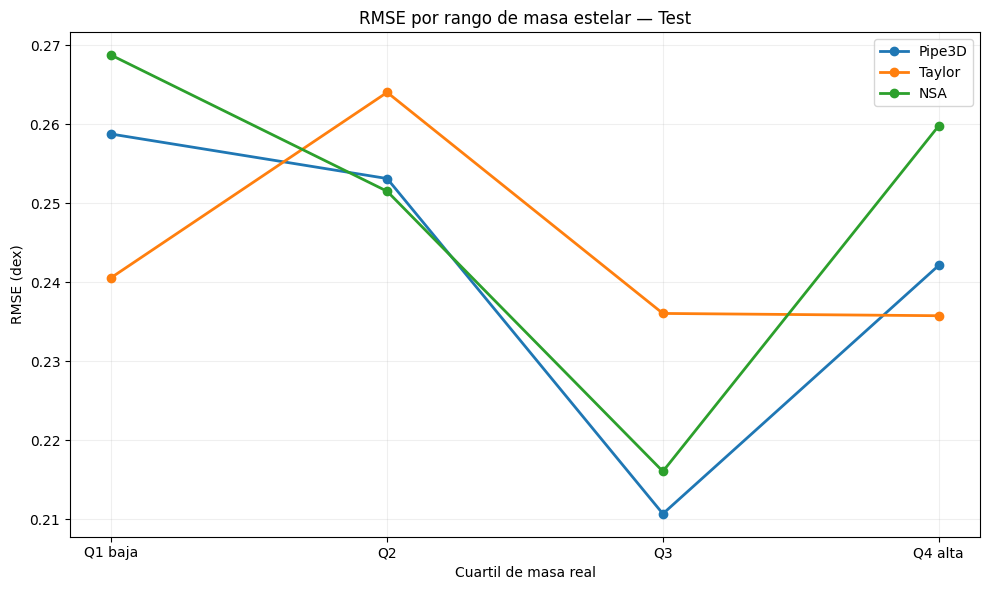


✓ Análisis por rango de masa completado.
✓ Figura guardada en: /content/drive/MyDrive/Proyecto_Integrador/comparacion_final_masas/figura_TEST_RMSE_por_cuartil_masa.png


In [ ]:
# ============================================================
# CELDA 38 — ERROR POR CUARTILES DE MASA
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Organizar predicciones
# ------------------------------------------------------------

datos_targets = {
    "Pipe3D": pred_test_pipe3d.copy(),
    "Taylor": pred_test_taylor.copy(),
    "NSA": pred_test_nsa.copy()
}


# ------------------------------------------------------------
# 2. Calcular métricas por cuartil
# ------------------------------------------------------------

filas = []


for nombre, tabla in datos_targets.items():

    tabla = tabla.copy()

    tabla["cuartil"] = pd.qcut(
        tabla["real"],
        q=4,
        labels=[
            "Q1 baja",
            "Q2",
            "Q3",
            "Q4 alta"
        ]
    )


    for cuartil, grupo in tabla.groupby(
        "cuartil",
        observed=True
    ):

        residuo = (
            grupo["pred"]
            - grupo["real"]
        )

        rmse = np.sqrt(
            np.mean(
                residuo ** 2
            )
        )

        mae = np.mean(
            np.abs(residuo)
        )

        bias = np.mean(
            residuo
        )

        masa_media = np.mean(
            grupo["real"]
        )


        filas.append(
            {
                "target": nombre,
                "cuartil": cuartil,
                "N": len(grupo),
                "masa_media": masa_media,
                "RMSE_dex": rmse,
                "MAE_dex": mae,
                "Bias_dex": bias
            }
        )


tabla_cuartiles = pd.DataFrame(
    filas
)


# ------------------------------------------------------------
# 3. Mostrar tabla
# ------------------------------------------------------------

print(
    "=== ERROR POR CUARTILES DE MASA ==="
)

display(
    tabla_cuartiles.style.format(
        {
            "masa_media": "{:.3f}",
            "RMSE_dex": "{:.4f}",
            "MAE_dex": "{:.4f}",
            "Bias_dex": "{:+.4f}"
        }
    )
)


# ------------------------------------------------------------
# 4. Gráfica RMSE por cuartil
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


orden = [
    "Q1 baja",
    "Q2",
    "Q3",
    "Q4 alta"
]


for nombre in [
    "Pipe3D",
    "Taylor",
    "NSA"
]:

    sub = tabla_cuartiles[
        tabla_cuartiles["target"] == nombre
    ].copy()

    sub["cuartil"] = pd.Categorical(
        sub["cuartil"],
        categories=orden,
        ordered=True
    )

    sub = sub.sort_values(
        "cuartil"
    )


    plt.plot(
        sub["cuartil"],
        sub["RMSE_dex"],
        marker="o",
        linewidth=2,
        label=nombre
    )


plt.xlabel(
    "Cuartil de masa real"
)

plt.ylabel(
    "RMSE (dex)"
)

plt.title(
    "RMSE por rango de masa estelar — Test"
)

plt.grid(
    alpha=0.2
)

plt.legend()

plt.tight_layout()


# ------------------------------------------------------------
# 5. Guardar figura
# ------------------------------------------------------------

ruta_fig_cuartiles = os.path.join(
    CARPETA_RESULTADOS,
    "figura_TEST_RMSE_por_cuartil_masa.png"
)


plt.savefig(
    ruta_fig_cuartiles,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. Guardar tabla
# ------------------------------------------------------------

tabla_cuartiles.to_csv(
    os.path.join(
        CARPETA_RESULTADOS,
        "metricas_por_cuartil_masa_TEST.csv"
    ),
    index=False
)


print(
    "\n✓ Análisis por rango de masa completado."
)

print(
    "✓ Figura guardada en:",
    ruta_fig_cuartiles
)

La figura muestra que el error no es uniforme a lo largo del rango de masa. Pipe3D alcanza su menor RMSE en Q3, alrededor de 0.211 dex, y aumenta tanto hacia masas bajas como hacia las más altas. NSA presenta un patrón parecido y tiene sus errores más altos en los extremos, especialmente Q1 y Q4. Taylor se comporta de forma algo distinta: su mayor error aparece en Q2, mientras que Q3 y Q4 permanecen alrededor de 0.236 dex.

Esto es consistente con lo que vimos antes en los residuos: los modelos muestran cierta regresión hacia la media, pero la dificultad no se concentra exactamente de la misma manera para las tres etiquetas.

Hay un detalle metodológico importante para el reporte: como los cuartiles se calcularon por separado para cada target, “Q1”, “Q2”, etc. representan el 25 % inferior/siguiente de cada escala de masa, pero no necesariamente contienen exactamente las mismas galaxias en cada target. Por eso esta gráfica debe usarse para describir cómo cambia el rendimiento dentro de cada definición de masa, no para afirmar que, por ejemplo, Pipe3D y Taylor fueron comparados sobre exactamente las mismas galaxias dentro de Q2.

### Error en función del rango de masa

El desempeño de los modelos no fue completamente uniforme a lo largo de sus respectivas distribuciones de masa.

Pipe3D presentó su menor RMSE en el tercer cuartil de masa, mientras que el error aumentó hacia los extremos de la distribución. NSA mostró un comportamiento similar, con mayor error en los cuartiles de masa más baja y más alta.

Taylor presentó una variación más moderada, aunque su mayor RMSE se observó en el segundo cuartil.

En conjunto, estos resultados son consistentes con el patrón observado en los residuos, donde los tres modelos mostraron cierta regresión hacia la media. Sin embargo, no existe un único intervalo de masa que sea sistemáticamente el más difícil para las tres definiciones.

Debe considerarse que los cuartiles fueron definidos independientemente para cada target. Por lo tanto, cada cuartil representa una posición relativa dentro de la distribución de Pipe3D, Taylor o NSA y no necesariamente contiene exactamente las mismas galaxias entre los tres estimadores.